## Задача ##

Разработать модель преддиктивной аналитики для формирования данных о потреблении объемов электроэнергии на примере одной энергосбытовой компании ПАО "Интер РАО"

Требуемый результат - прогноз потребления электроэнергии в кВт*ч на ближайшие 6 мес. с последующим занесением данных в бизнес-план компании.

### Чек-лист анализа данных

**Этап 1. Первичный анализ и качество данных**
1. Определить структуру и гранулярность данных.
2. Проверить пропуски, дубликаты и аномальные значения.
3. Провести EDA: динамика показателей, описательная статистика, распределения, выбросы.
4. Сформулировать первичные наблюдения и вопросы для дальнейшего анализа.

**Этап 2. Анализ взаимосвязей**
1. Изучить зависимости между ключевыми показателями.
2. Рассчитать корреляции и проверить их статистическую значимость.
3. Сравнить связи на уровнях и приростах.
4. При необходимости построить регрессионную модель и оценить влияние факторов.

**Этап 3. Исследование структуры и сезонности**
1. Провести декомпозицию временного ряда.
2. Выделить тренд, сезонность и случайную составляющую.
3. Сравнить аддитивную и мультипликативную модели.
4. Рассчитать сезонные индексы и определить сезонные пики/провалы.

**Этап 4. Проверка временного ряда и подготовка модели**
1. Проверить стационарность.
2. При необходимости выполнить обычное и сезонное дифференцирование.
3. Исследовать ACF и PACF.
4. Сформировать кандидатов на параметры p, q, P, Q.

**Этап 5. Статистическая проверка гипотез**
1. Проверить распределения и предпосылки статистических методов.
2. Сравнить группы и средние значения.
3. Оценить корреляционные зависимости.
4. Проверить категориальные взаимосвязи.
5. Интерпретировать результаты через p-value + effect size + бизнес-смысл.

Этап 6. Построение моделей
1. Построить несколько моделей прогнозирования.
2. Сравнить базовые и сезонные подходы.
3. Обучить модели на train-выборке.
4. Получить прогнозы на тестовом периоде.

Этап 7. Диагностика моделей
1. Проверить остатки на автокорреляцию.
2. Проверить нормальность и среднее остатков.
3. Проанализировать диагностические графики.
4. Убедиться, что модель не оставляет систематическую структуру в ошибках.

Этап 8. Валидация и выбор модели
1. Оценить MAE, RMSE, MAPE и другие релевантные метрики.
2. Проверить наличие систематического смещения.
3. Сравнить модели на одном и том же тестовом периоде.
4. Выбрать модель по совокупности качества прогноза + диагностик + бизнес-применимости.

Этап 9. Финальный прогноз и интерпретация
1. Переобучить выбранную модель на полном наборе данных.
2. Построить прогноз на заданный горизонт.
3. Рассчитать доверительные/прогнозные интервалы.
4. Выделить ожидаемые тренды и сезонные пики.
5. Сформулировать итоговый вывод и бизнес-рекомендации.

### Этап 0 ###

1. Загрузка файла
2. Проверка данных
3. Преобразование и изменение необходимых параметров
4. Изменение на необходимые типы данных
5. Проверка пропусков

In [1]:
# импорт необходимых инструментов
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import (ExponentialSmoothing)
from statsmodels.tsa.statespace.sarimax import (SARIMAX)
import pmdarima as pm
from scipy import stats

In [2]:
from pathlib import Path

df_askp = pd.read_excel(Path("АСКП трансп 22-25 потребление.xlsx"))

df_askp.head(100)

,Период_Потребители,"Бюджетные от 670 кВт до 10МВт, кВт*ч","Бюджетные до 670 кВт, кВт*ч","Население и ППН, Компенсация потерь, кВт*ч","Промышленные от 670 кВт до 10МВт, кВт*ч","Промышленные до 670 кВт, кВт*ч","Промышленные больше 10МВт, кВт*ч","Прочие от 670 кВт до 10МВт, кВт*ч","Прочие до 670 кВт, кВт*ч","Прочие больше 10МВт, кВт*ч","Прочие, Компенсация потерь, кВт*ч"
0,2022.01,2.999725,73.310224,510.083623,53.664590,60.370021,14.155173,93.694012,229.897416,127.127288,305.718093
1,2022.02,2.589740,66.430226,474.012149,53.672199,54.986713,12.720884,80.665820,206.827975,115.491643,192.111344
2,2022.03,3.031050,65.511721,435.587675,57.427256,59.515658,14.427206,91.883922,219.226835,121.046579,292.709752
3,2022.04,2.619697,53.650281,416.905633,49.535999,53.177817,12.706710,64.622996,179.120970,106.026919,149.763978
4,2022.05,2.331795,43.841673,392.190305,45.560769,44.050559,11.443417,64.631002,159.545845,110.258728,169.958589
5,2022.06,2.176592,35.771498,363.853226,42.750577,39.914890,11.367049,69.150258,159.040159,150.935513,39.816536
6,2022.07,2.339012,31.804908,324.971545,44.370635,41.859877,12.092648,72.339799,171.863205,121.874111,148.207505
7,2022.08,2.527635,33.595790,328.244673,46.894960,43.794175,12.419754,79.156703,181.674651,124.669061,129.878731
8,2022.09,2.408539,45.385212,350.607284,45.886384,45.259380,14.130208,76.648129,168.216848,134.863691,144.480055
9,2022.10,2.736226,55.391338,372.073980,52.902442,55.501501,15.300992,84.779613,187.170073,132.084745,230.556218


In [3]:
df_askp.info() #просмотр типов данных и названий столбцов

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Период_Потребители                          43 non-null     float64
 1   Бюджетные от 670 кВт до 10МВт, кВт*ч        43 non-null     float64
 2   Бюджетные до 670 кВт, кВт*ч                 43 non-null     float64
 3   Население и ППН, Компенсация потерь, кВт*ч  43 non-null     float64
 4   Промышленные от 670 кВт до 10МВт, кВт*ч     43 non-null     float64
 5   Промышленные до 670 кВт, кВт*ч              43 non-null     float64
 6   Промышленные больше 10МВт, кВт*ч            43 non-null     float64
 7   Прочие от 670 кВт до 10МВт, кВт*ч           43 non-null     float64
 8   Прочие до 670 кВт, кВт*ч                    43 non-null     float64
 9   Прочие больше 10МВт, кВт*ч                  43 non-null     float64
 10  Прочие, Компенсация потерь,

In [4]:
# преобразование в строчку
df_askp['Период_Потребители'] = df_askp['Период_Потребители'].apply(lambda x: f'{x:.2f}')

In [5]:
#приведение к единому формату имен

df_askp = df_askp.rename(columns=lambda x: x.replace(' ', '_').lower())

df_askp = df_askp.rename(columns=lambda x: x.replace(',_', '_').lower())

df_askp.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 11 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   период_потребители                        43 non-null     str    
 1   бюджетные_от_670_квт_до_10мвт_квт*ч       43 non-null     float64
 2   бюджетные_до_670_квт_квт*ч                43 non-null     float64
 3   население_и_ппн_компенсация_потерь_квт*ч  43 non-null     float64
 4   промышленные_от_670_квт_до_10мвт_квт*ч    43 non-null     float64
 5   промышленные_до_670_квт_квт*ч             43 non-null     float64
 6   промышленные_больше_10мвт_квт*ч           43 non-null     float64
 7   прочие_от_670_квт_до_10мвт_квт*ч          43 non-null     float64
 8   прочие_до_670_квт_квт*ч                   43 non-null     float64
 9   прочие_больше_10мвт_квт*ч                 43 non-null     float64
 10  прочие_компенсация_потерь_квт*ч           43 non-nu

In [6]:
# Даты в datetime
df_askp['период_потребители'] = pd.to_datetime(df_askp['период_потребители'].str.replace('.', '', regex=False), format='%Y%m', errors='coerce')

In [7]:
df_askp.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 11 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   период_потребители                        43 non-null     datetime64[us]
 1   бюджетные_от_670_квт_до_10мвт_квт*ч       43 non-null     float64       
 2   бюджетные_до_670_квт_квт*ч                43 non-null     float64       
 3   население_и_ппн_компенсация_потерь_квт*ч  43 non-null     float64       
 4   промышленные_от_670_квт_до_10мвт_квт*ч    43 non-null     float64       
 5   промышленные_до_670_квт_квт*ч             43 non-null     float64       
 6   промышленные_больше_10мвт_квт*ч           43 non-null     float64       
 7   прочие_от_670_квт_до_10мвт_квт*ч          43 non-null     float64       
 8   прочие_до_670_квт_квт*ч                   43 non-null     float64       
 9   прочие_больше_10мвт_квт*ч                 43 

In [8]:
# предварительная проверка данных и статистический срез
df_askp.describe()

,период_потребители,бюджетные_от_670_квт_до_10мвт_квт*ч,бюджетные_до_670_квт_квт*ч,население_и_ппн_компенсация_потерь_квт*ч,промышленные_от_670_квт_до_10мвт_квт*ч,промышленные_до_670_квт_квт*ч,промышленные_больше_10мвт_квт*ч,прочие_от_670_квт_до_10мвт_квт*ч,прочие_до_670_квт_квт*ч,прочие_больше_10мвт_квт*ч,прочие_компенсация_потерь_квт*ч
count,43,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,2023-10-01 07:48:50.232558,3.733666,53.457528,419.345821,43.898123,37.020664,14.690183,86.907931,216.075486,116.431472,200.212549
min,2022-01-01 00:00:00,2.176592,31.804908,324.971545,27.276999,17.267049,4.778441,64.622996,159.040159,94.738040,39.816536
25%,2022-11-16 00:00:00,3.103750,38.842496,356.533209,40.554271,28.108685,12.213053,80.450919,196.909203,105.407656,141.828947
50%,2023-10-01 00:00:00,3.702344,53.650281,416.905633,44.211669,33.277964,14.130208,86.716324,210.274455,115.491643,172.813397
75%,2024-08-16 12:00:00,4.450824,66.695815,479.479470,48.592755,43.922367,16.681161,94.467073,238.993572,126.836778,258.775698
max,2025-07-01 00:00:00,5.819890,77.196895,541.301982,57.427256,60.370021,32.818935,103.935954,283.844587,150.935513,366.758031
std,NaN,0.880489,15.370793,67.082055,7.138180,12.289361,5.161014,10.155470,32.655151,13.595096,79.903384


<Axes: >

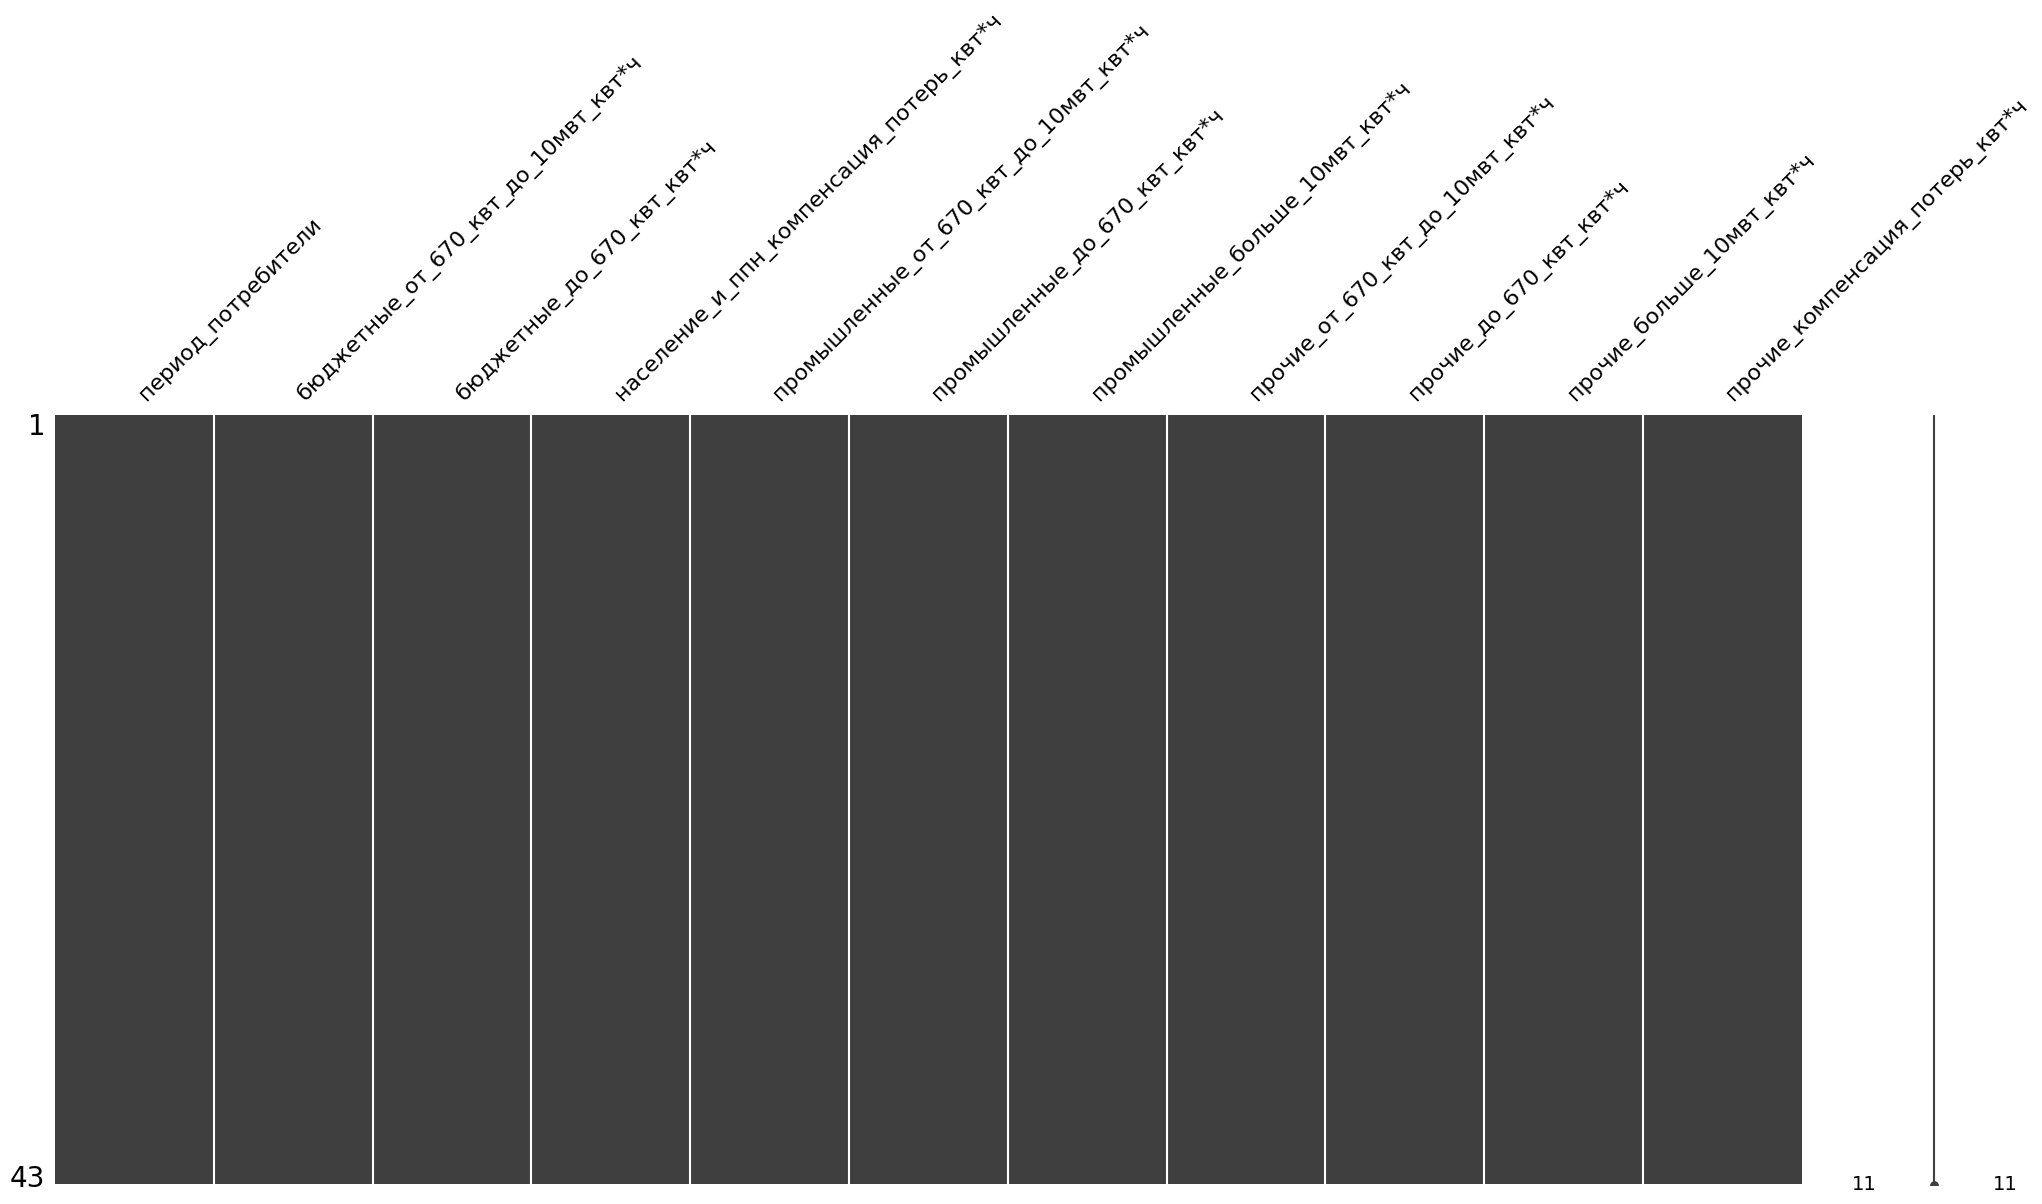

In [9]:
#проверка на пропуски
import missingno
missingno.matrix(df_askp)

### Этап 1. Первичный анализ и качество данных
1. Определить структуру и гранулярность данных.
2. Проверить пропуски, дубликаты и аномальные значения.
3. Провести EDA: динамика показателей, описательная статистика, распределения, выбросы.
4. Сформулировать первичные наблюдения и вопросы для дальнейшего анализа.

In [10]:
# список потребителей для графика
POTRNAME = df_askp.columns.tolist()
POTRNAME_ = POTRNAME[1:]
POTRNAME_

['бюджетные_от_670_квт_до_10мвт_квт*ч',
 'бюджетные_до_670_квт_квт*ч',
 'население_и_ппн_компенсация_потерь_квт*ч',
 'промышленные_от_670_квт_до_10мвт_квт*ч',
 'промышленные_до_670_квт_квт*ч',
 'промышленные_больше_10мвт_квт*ч',
 'прочие_от_670_квт_до_10мвт_квт*ч',
 'прочие_до_670_квт_квт*ч',
 'прочие_больше_10мвт_квт*ч',
 'прочие_компенсация_потерь_квт*ч']

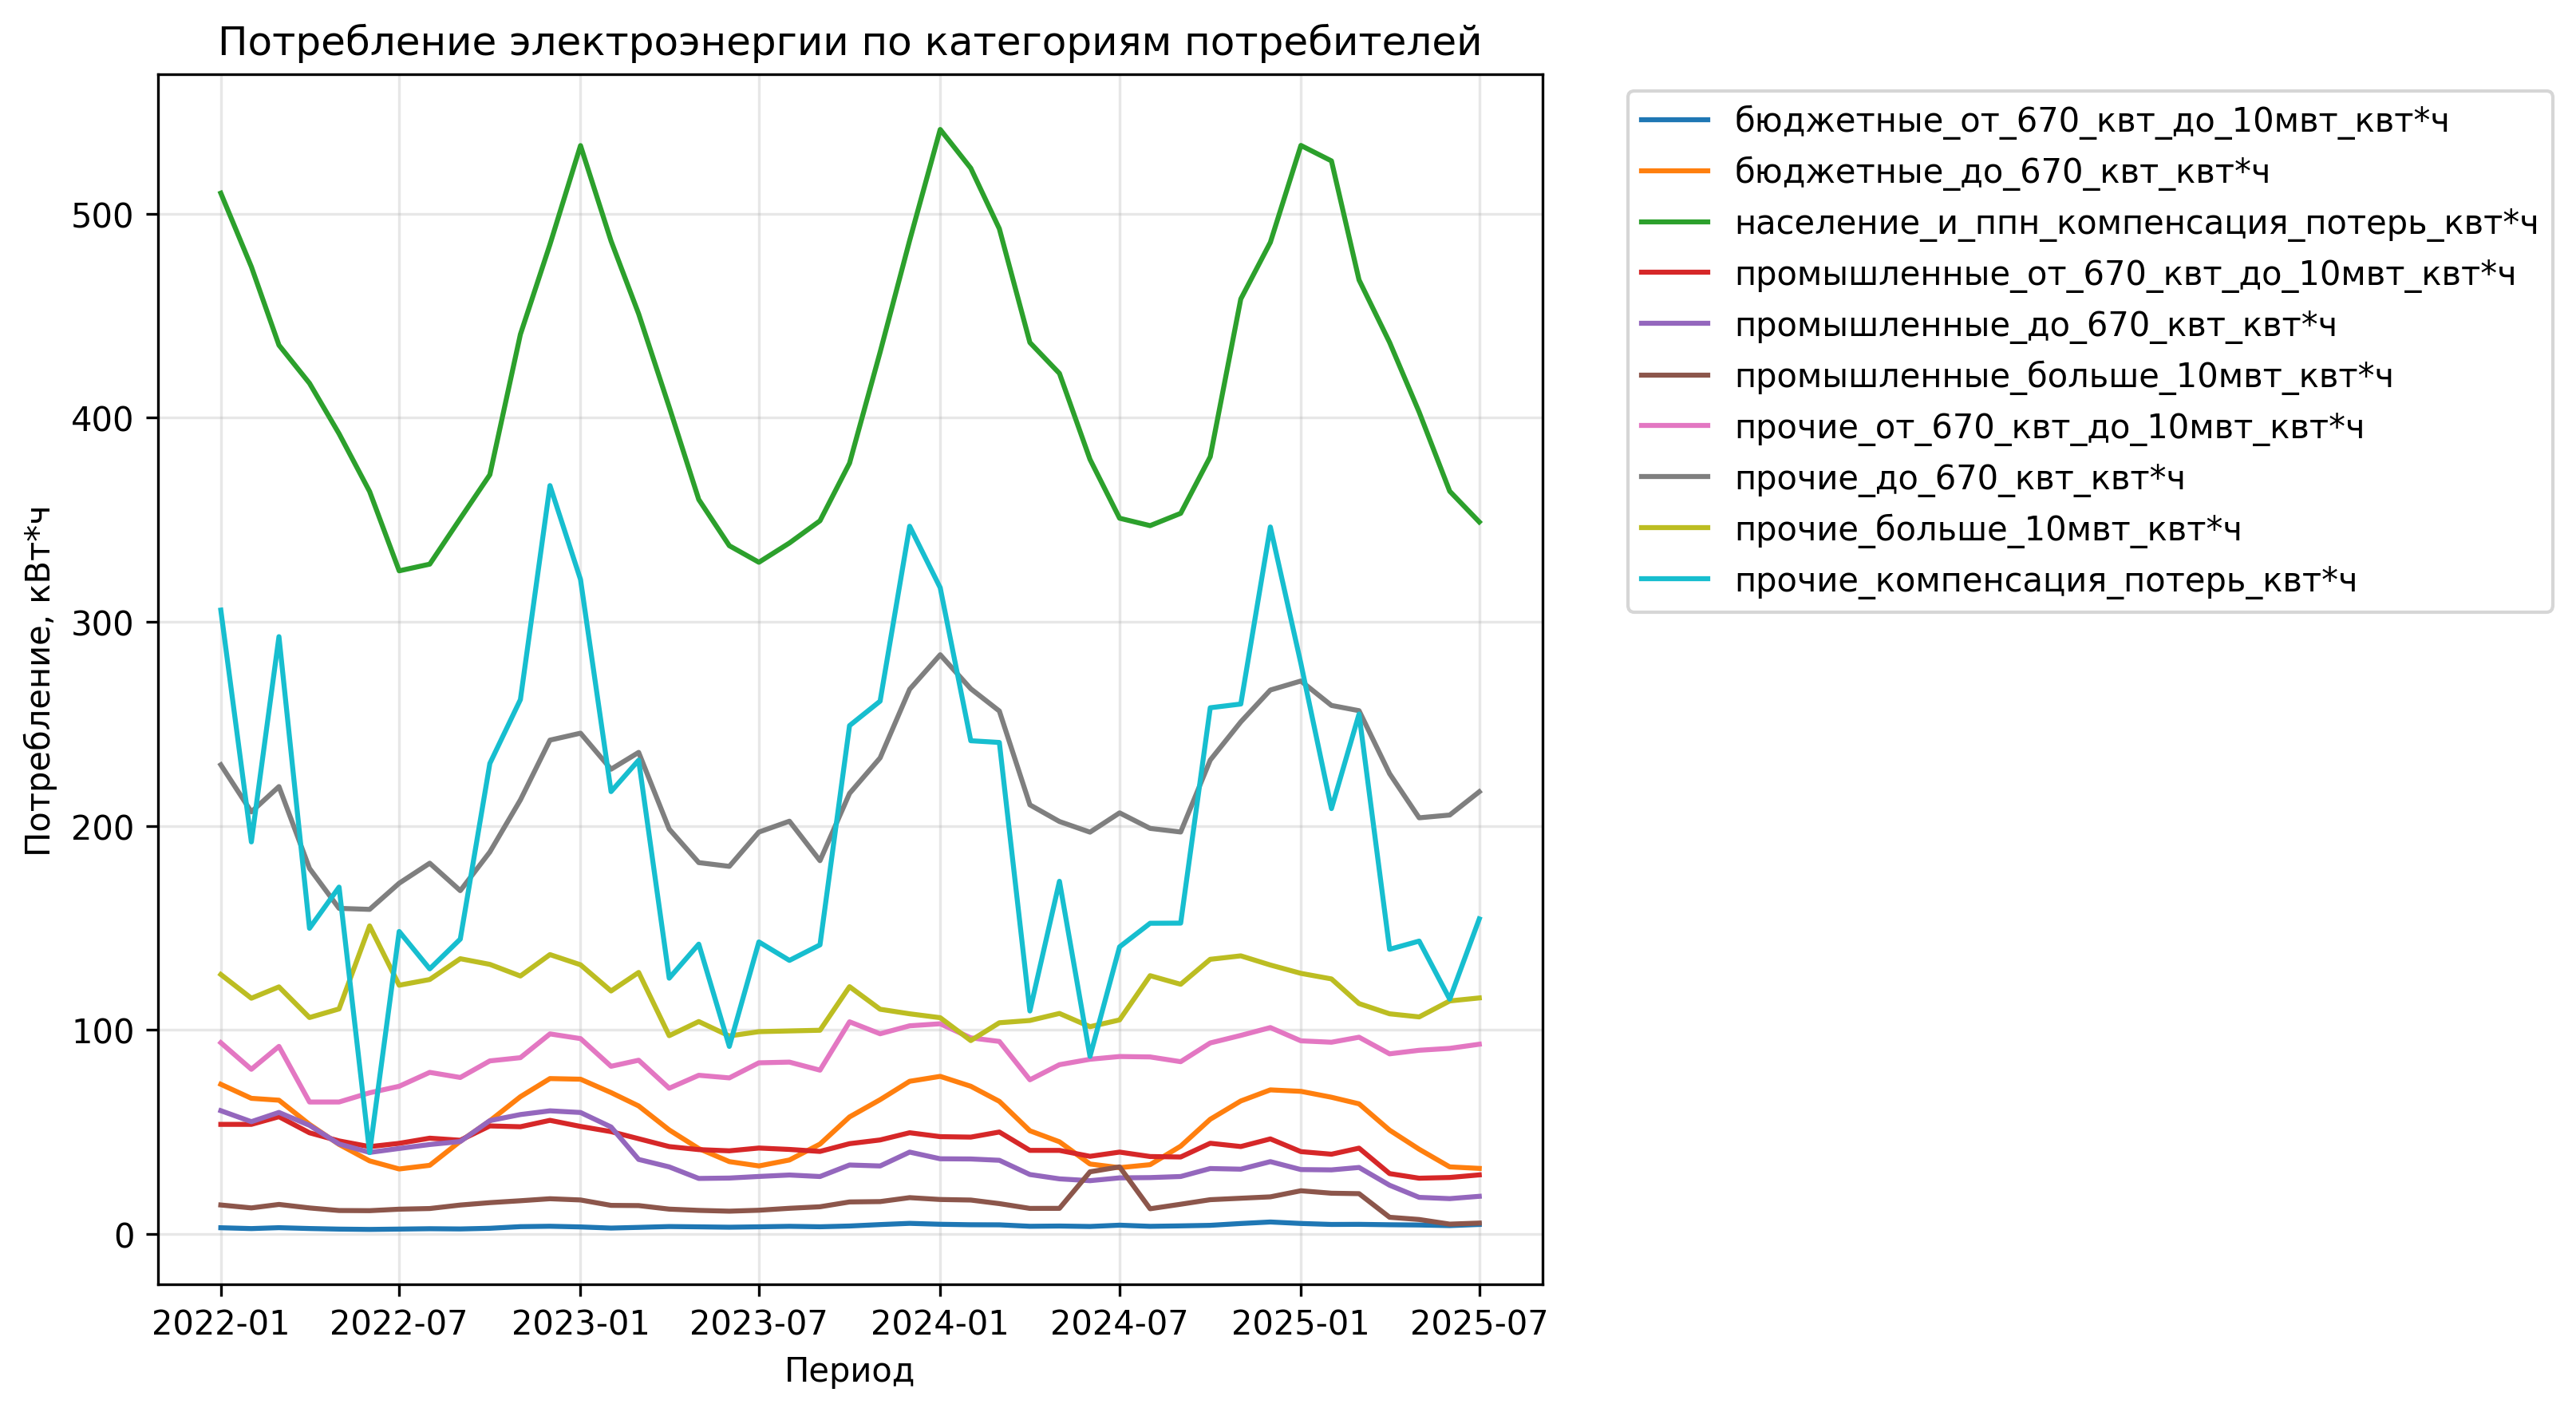

In [11]:
# визуализация графика потребеления по всем категориям

fig, ax1 = plt.subplots(figsize=(11, 6), dpi=300)

for category in POTRNAME_:
    ax1.plot(df_askp['период_потребители'], df_askp[category],
             linestyle='-', label=category)

ax1.set_xlabel('Период')
ax1.set_ylabel('Потребление, кВт*ч')
ax1.set_title('Потребление электроэнергии по категориям потребителей')
ax1.grid(True, alpha=0.3)

# Общая легенда
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

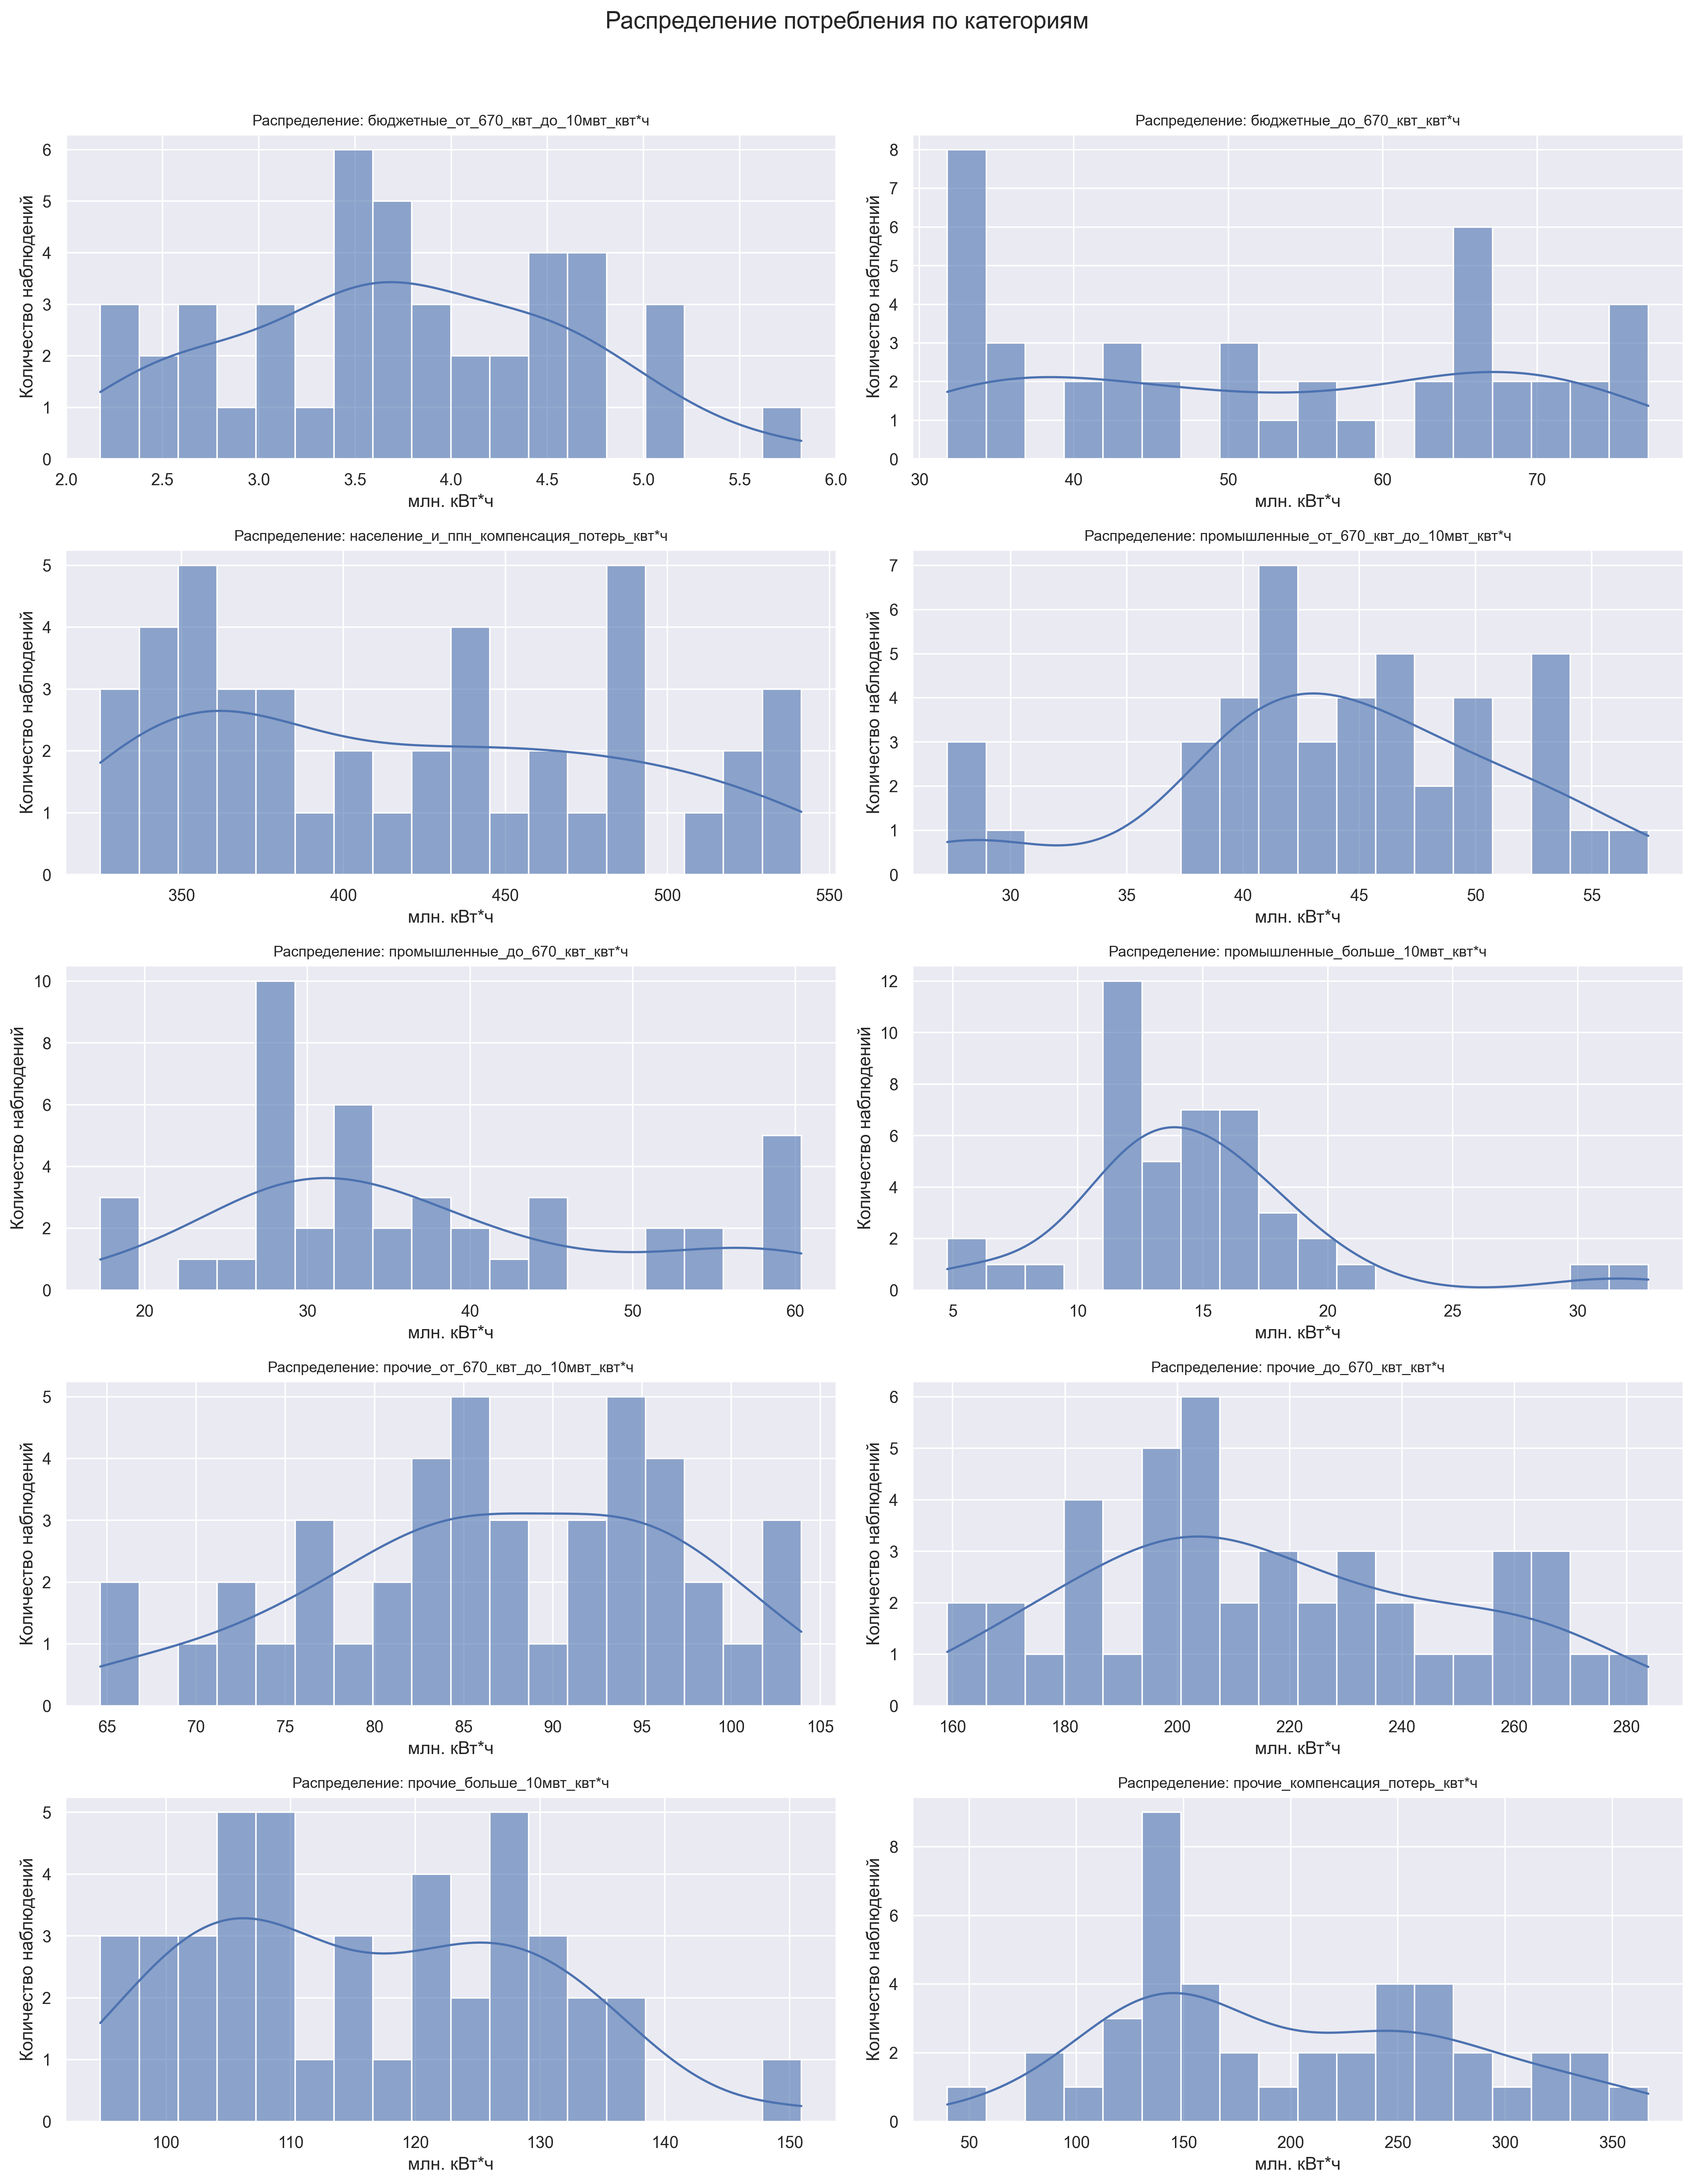

In [12]:
# распределение потребления через гистограмму и кривую распределения

sns.set_theme(style='darkgrid')

# Количество категорий
n_categories = len(POTRNAME_)

# Выбираем раскладку: 5 строк, 2 столбца (для 10 категорий)
ncols = 2
nrows = (n_categories + ncols - 1) // ncols  # округление вверх
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, nrows * 4),  # высота зависит от числа строк
    dpi=300
)

# Преобразуем axes в одномерный массив для удобства итерации
axes = axes.flatten()

# Для каждой категории строим гистограмму в своей ячейке
for i, category in enumerate(POTRNAME_):
    sns.histplot(
        data=df_askp,
        x=category,
        bins=18,
        kde=True,
        ax=axes[i],
        alpha=0.6,
    )
    axes[i].set_title(f'Распределение: {category}', fontsize=10)
    axes[i].set_xlabel('млн. кВт*ч')
    axes[i].set_ylabel('Количество наблюдений')

# Если категорий меньше, чем ячеек, скрываем лишние оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Общий заголовок
fig.suptitle('Распределение потребления по категориям', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()



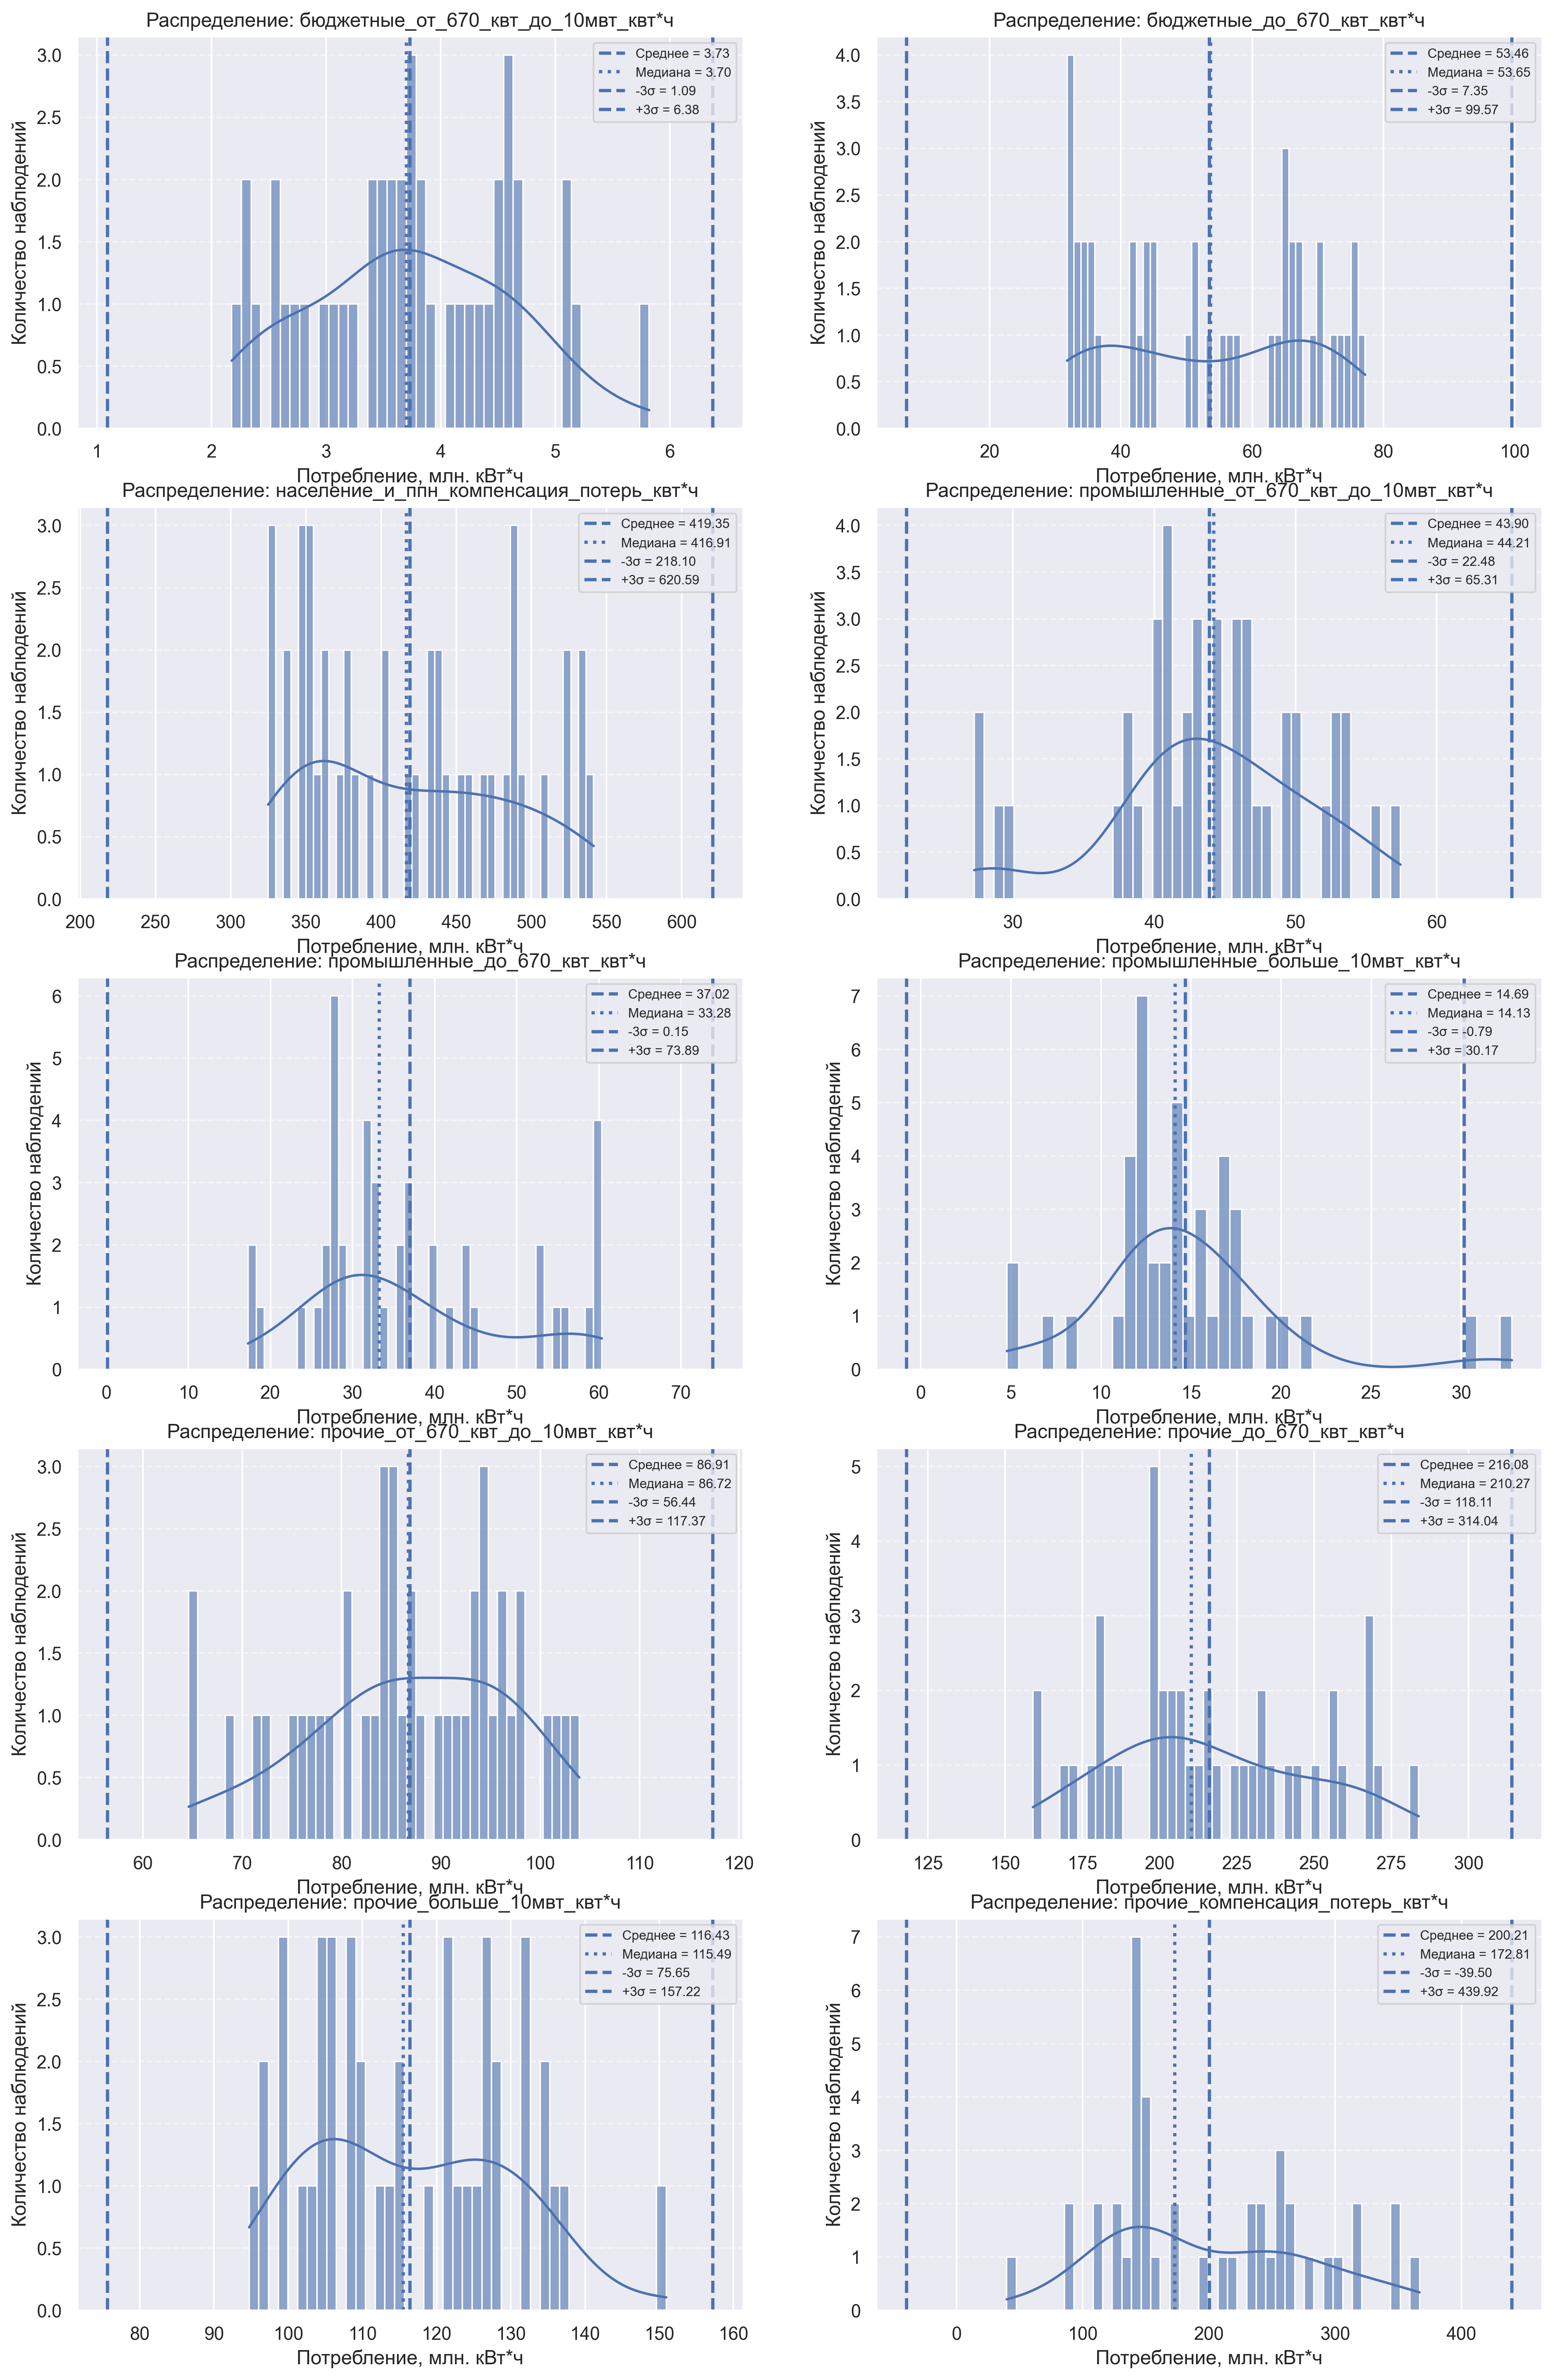

In [13]:
n = len(POTRNAME_)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, nrows * 5), dpi=300
)

axes = axes.flatten()

for i, col in enumerate(POTRNAME_):
    ax = axes[i]
    x = df_askp[col].dropna()

    mean = x.mean()
    median = x.median()
    std = x.std()

    # Границы 3 сигм
    lower_3sigma = mean - 3 * std
    upper_3sigma = mean + 3 * std

    # Гистограмма + KDE
    sns.histplot(
        x=x,
        bins=43,
        kde=True,
        ax=ax,
        alpha=0.6
    )
    # Среднее

    ax.axvline(
        mean,
        linestyle='--',
        linewidth=2,
        label=f'Среднее = {mean:.2f}'
    )

    # Медиана

    ax.axvline(
        median,
        linestyle=':',
        linewidth=2,
        label=f'Медиана = {median:.2f}'
    )

    # Нижняя граница 3σ

    ax.axvline(
        lower_3sigma,
        linestyle='--',
        linewidth=2,
        label=f'-3σ = {lower_3sigma:.2f}'
    )

    # Верхняя граница 3σ

    ax.axvline(
        upper_3sigma,
        linestyle='--',
        linewidth=2,
        label=f'+3σ = {upper_3sigma:.2f}'
    )

    # Оформление

    ax.set_title(f'Распределение: {col}', fontsize=12)
    ax.set_xlabel('Потребление, млн. кВт*ч')
    ax.set_ylabel('Количество наблюдений')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)

# Скрываем лишние подграфики, если их больше, чем категорий
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

    plt.suptitle('Распределения по категориям потребления', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

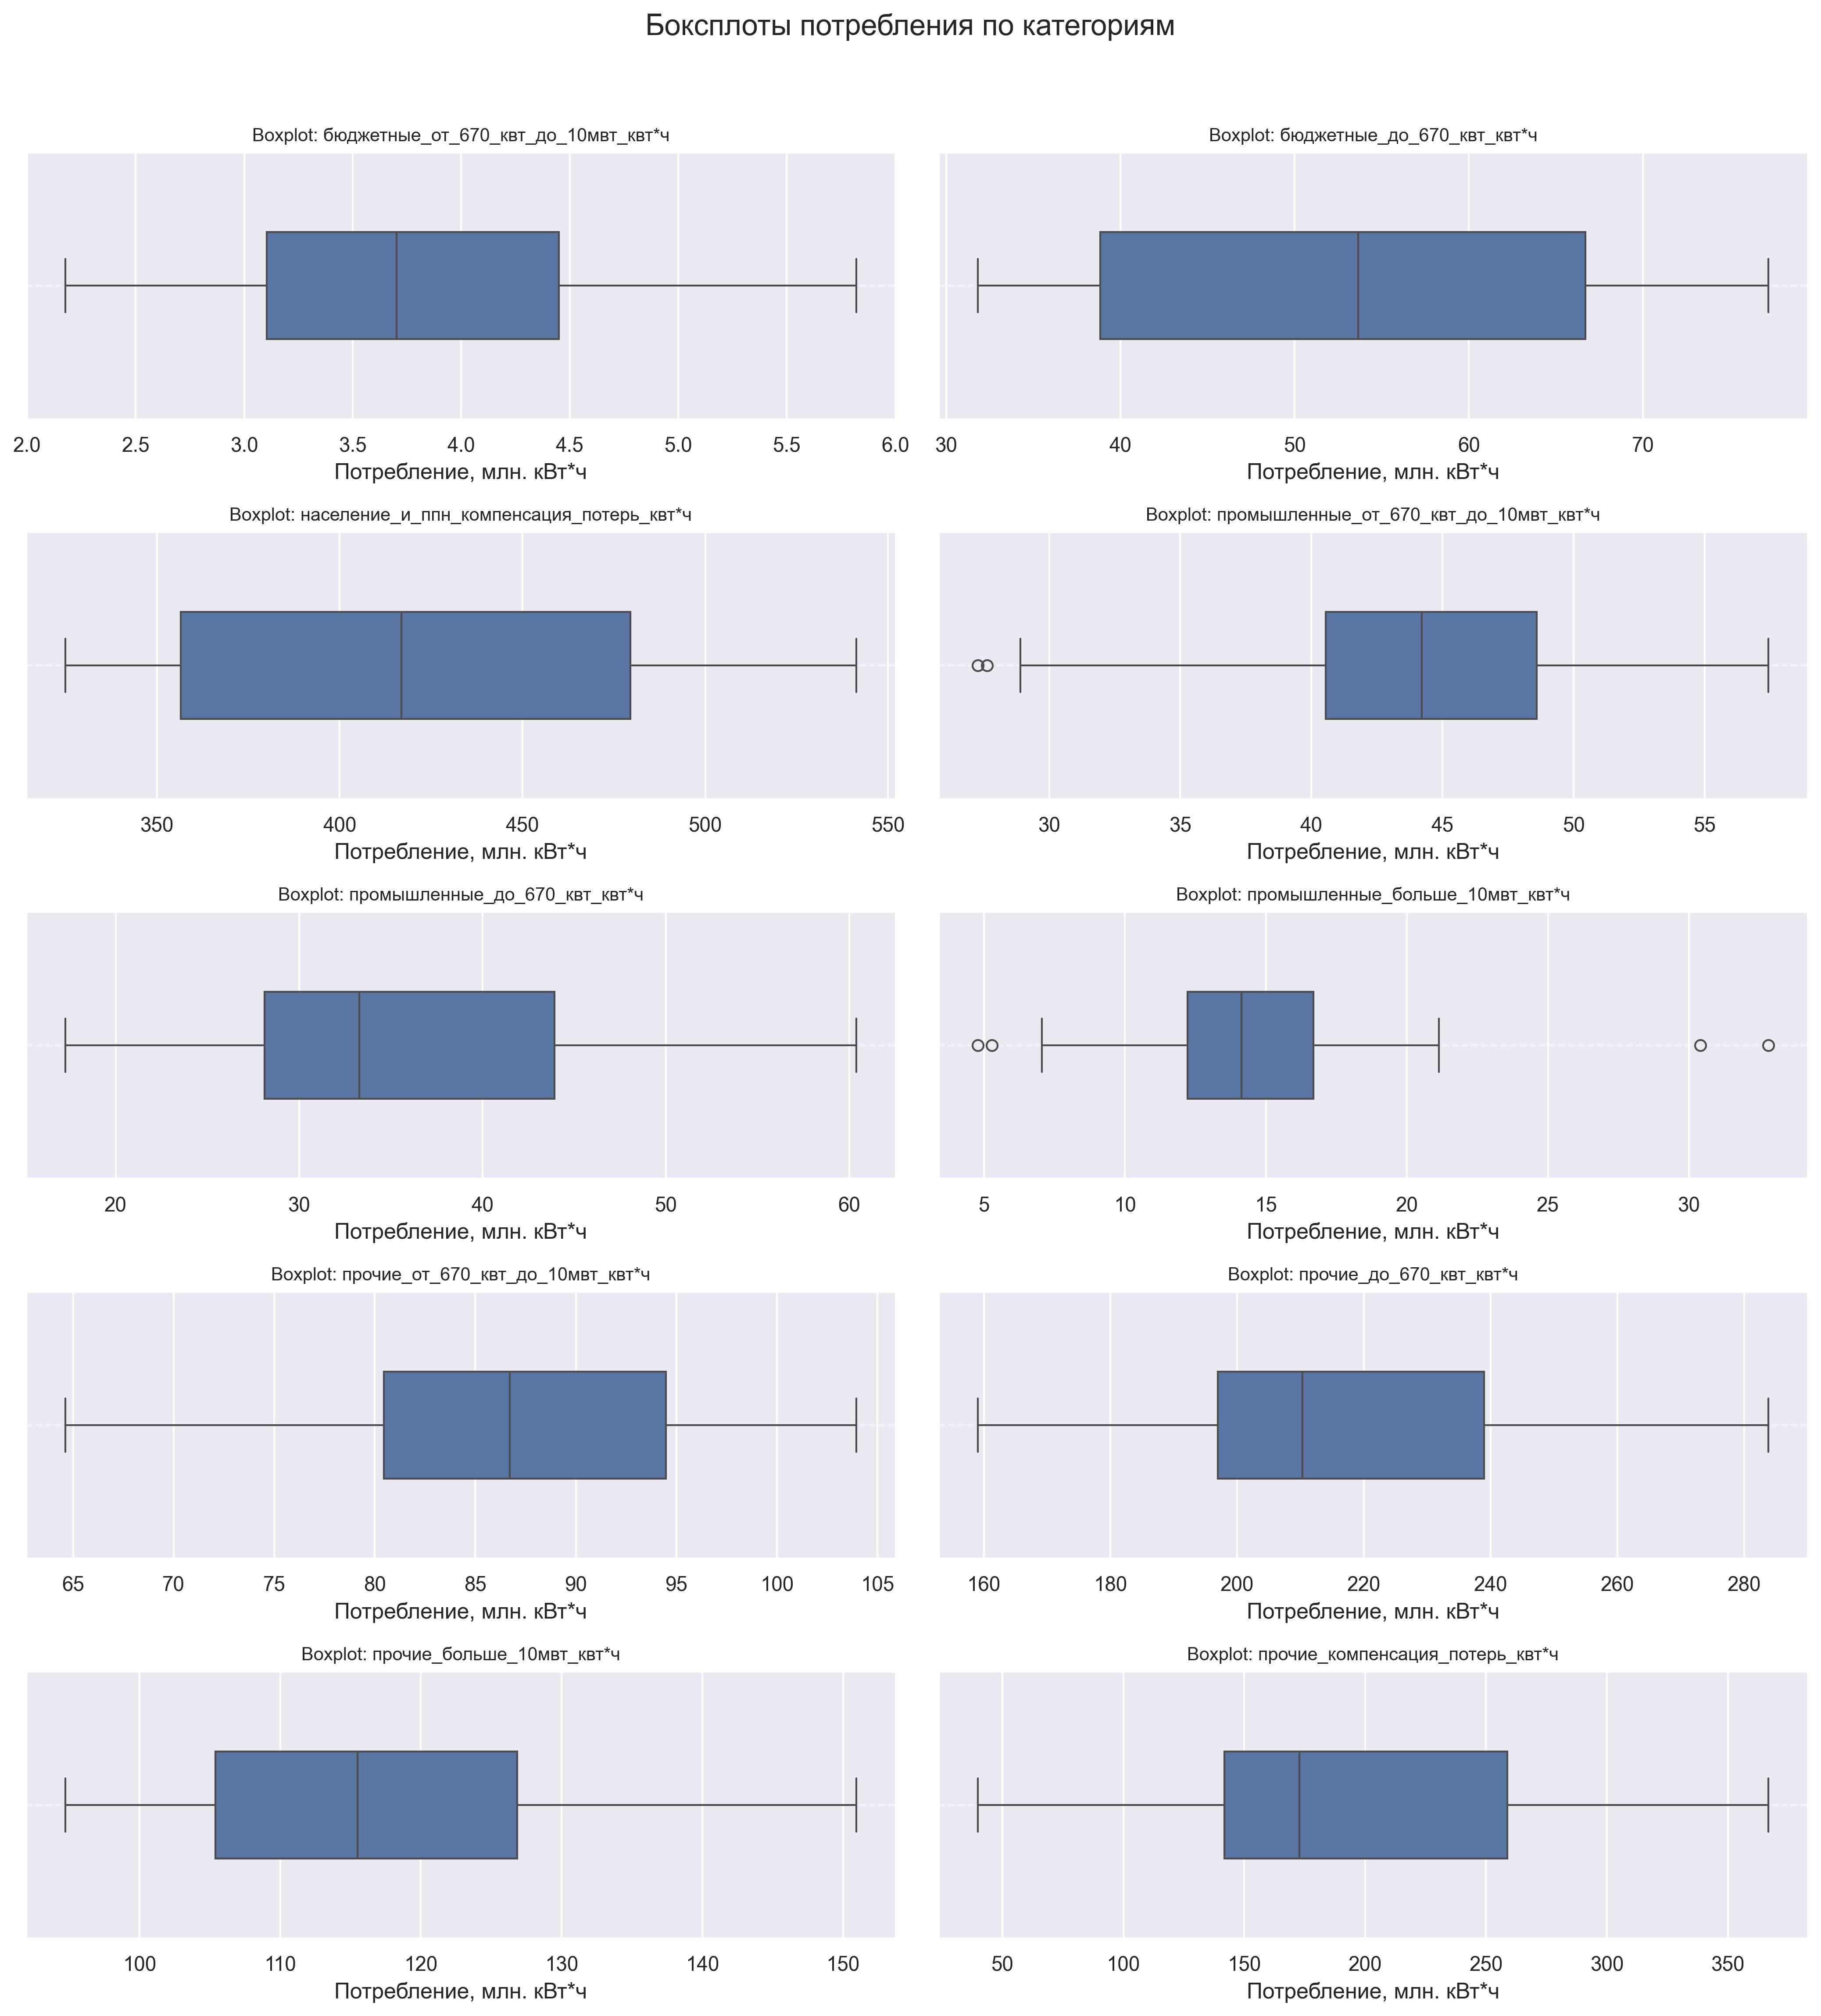

In [14]:
# Боксплот
n = len(POTRNAME_)
ncols = 2                     # две колонки
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), dpi=300)
axes = axes.flatten()

for i, col in enumerate(POTRNAME_):
    ax = axes[i]
    x = df_askp[col].dropna()      # Series без пропусков

    sns.boxplot(x=x, ax=ax, width=0.4)

    ax.set_title(f'Boxplot: {col}', fontsize=10)
    ax.set_xlabel('Потребление, млн. кВт*ч')
    ax.set_ylabel('')                  # ось Y обычно не нужна
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Скрываем лишние подграфики, если их больше, чем категорий
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Боксплоты потребления по категориям', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
#Проверка 3 сигм и сборка в единый датафрейм (чистый питон)

# Список для сбора сводных статистик
summary_rows = []
# Словарь для хранения выбросов по каждой категории
outliers_dict = {}

for col in POTRNAME_:
    # Выбираем столбец
    x = df_askp[col]
    # Среднее
    mean = x.mean()
    # Стандартное отклонение
    std = x.std()
    # Границы трех сигм
    lower = mean - 3 * std
    upper = mean + 3 * std

    # Поиск выбросов
    outliers = x[(x < lower) | (x > upper)]

    # Сохраняем выбросы
    outliers_dict[col] = outliers.tolist()

    # Добавляем строку в список для DataFrame

    summary_rows.append({
        'Категория': col,
        'Среднее': mean,
        'Стандартное_отклонение': std,
        'Нижняя_граница_3σ': lower,
        'Верхняя_граница_3σ': upper,
        'Количество_выбросов': len(outliers)
    })

summary_df = pd.DataFrame(summary_rows)

summary_df

,Категория,Среднее,Стандартное_отклонение,Нижняя_граница_3σ,Верхняя_граница_3σ,Количество_выбросов
0,бюджетные_от_670_квт_до_10мвт_квт*ч,3.733666,0.880489,1.092201,6.375132,0
1,бюджетные_до_670_квт_квт*ч,53.457528,15.370793,7.345147,99.569908,0
2,население_и_ппн_компенсация_потерь_квт*ч,419.345821,67.082055,218.099655,620.591987,0
3,промышленные_от_670_квт_до_10мвт_квт*ч,43.898123,7.138180,22.483582,65.312664,0
4,промышленные_до_670_квт_квт*ч,37.020664,12.289361,0.152581,73.888746,0
5,промышленные_больше_10мвт_квт*ч,14.690183,5.161014,-0.792858,30.173224,2
6,прочие_от_670_квт_до_10мвт_квт*ч,86.907931,10.155470,56.441520,117.374341,0
7,прочие_до_670_квт_квт*ч,216.075486,32.655151,118.110034,314.040939,0
8,прочие_больше_10мвт_квт*ч,116.431472,13.595096,75.646185,157.216759,0
9,прочие_компенсация_потерь_квт*ч,200.212549,79.903384,-39.497603,439.922701,0


In [16]:
#Доверительный интервал

for col in POTRNAME_:
    x = df_askp[col]

    confidence = 0.95

    ci = stats.t.interval(
        confidence=confidence,
        df=len(x)-1,
        loc=np.mean(x),
        scale=stats.sem(x)
    )

    print(f'95%-й доверительный интервал: {ci}')

95%-й доверительный интервал: (np.float64(3.4626918864393517), np.float64(4.004640625188555))
95%-й доверительный интервал: (np.float64(48.72709562562484), np.float64(58.187959630076264))
95%-й доверительный интервал: (np.float64(398.7010118497989), np.float64(439.99063066182885))
95%-й доверительный интервал: (np.float64(41.70131539756219), np.float64(46.09493071815873))
95%-й доверительный интервал: (np.float64(33.2385566113967), np.float64(40.80277069060497))
95%-й доверительный интервал: (np.float64(13.101857380087244), np.float64(16.27850848037787))
95%-й доверительный интервал: (np.float64(83.78253808946747), np.float64(90.03332298271297))
95%-й доверительный интервал: (np.float64(206.02571430868934), np.float64(226.125258483125))
95%-й доверительный интервал: (np.float64(112.24751900533833), np.float64(120.61542480848287))
95%-й доверительный интервал: (np.float64(175.62191709370026), np.float64(224.80318099944535))


**Решение через statsmodels и итоговая таблица с основными показателями и доверительными интервалами**

In [17]:
from statsmodels.stats.weightstats import DescrStatsW

summary_rows = []
outliers_dict = {}

for col in POTRNAME_:
    x = df_askp[col].dropna()

    ds = DescrStatsW(x)

    nobs = ds.nobs
    mean = ds.mean
    median = x.median()
    std = ds.std
    var = ds.var
    min_val = x.min()
    max_val = x.max()
    # 95% доверительный интервал для среднего
    ci_low, ci_high = ds.tconfint_mean()

    # Границы 3σ
    lower_3sigma = mean - 3 * std
    upper_3sigma = mean + 3 * std

    # Выбросы
    outliers = x[(x < lower_3sigma) | (x > upper_3sigma)]
    outliers_dict[col] = outliers.tolist()

    summary_rows.append({
        'Категория': col,
        'Количество_наблюдений': nobs,
        'Среднее': mean,
        'Медиана': median,
        'Стандартное_отклонение': std,
        'Дисперсия' : var,
        'Минимум': min_val,
        'Максимум': max_val,
        'ДИ_95%_нижн': ci_low,
        'ДИ_95%_верхн': ci_high,
        'Нижняя_граница_3σ': lower_3sigma,
        'Верхняя_граница_3σ': upper_3sigma,
        'Количество_выбросов': len(outliers),
    })

descriptive_df = pd.DataFrame(summary_rows)

descriptive_df

,Категория,Количество_наблюдений,Среднее,Медиана,Стандартное_отклонение,Дисперсия,Минимум,Максимум,ДИ_95%_нижн,ДИ_95%_верхн,Нижняя_граница_3σ,Верхняя_граница_3σ,Количество_выбросов
0,бюджетные_от_670_квт_до_10мвт_квт*ч,43.0,3.733666,3.702344,0.870190,0.757231,2.176592,5.819890,3.462692,4.004641,1.123096,6.344236,0
1,бюджетные_до_670_квт_квт*ч,43.0,53.457528,53.650281,15.191012,230.766843,31.804908,77.196895,48.727096,58.187960,7.884492,99.030563,0
2,население_и_ппн_компенсация_потерь_квт*ч,43.0,419.345821,416.905633,66.297443,4395.350940,324.971545,541.301982,398.701012,439.990631,220.453492,618.238150,0
3,промышленные_от_670_квт_до_10мвт_квт*ч,43.0,43.898123,44.211669,7.054690,49.768651,27.276999,57.427256,41.701315,46.094931,22.734053,65.062193,0
4,промышленные_до_670_квт_квт*ч,43.0,37.020664,33.277964,12.145621,147.516104,17.267049,60.370021,33.238557,40.802771,0.583801,73.457526,0
5,промышленные_больше_10мвт_квт*ч,43.0,14.690183,14.130208,5.100649,26.016618,4.778441,32.818935,13.101857,16.278508,-0.611763,29.992129,2
6,прочие_от_670_квт_до_10мвт_квт*ч,43.0,86.907931,86.716324,10.036689,100.735122,64.622996,103.935954,83.782538,90.033323,56.797864,117.017997,0
7,прочие_до_670_квт_квт*ч,43.0,216.075486,210.274455,32.273206,1041.559840,159.040159,283.844587,206.025714,226.125258,119.255868,312.895105,0
8,прочие_больше_10мвт_квт*ч,43.0,116.431472,115.491643,13.436083,180.528334,94.738040,150.935513,112.247519,120.615425,76.123222,156.739722,0
9,прочие_компенсация_потерь_квт*ч,43.0,200.212549,172.813397,78.968809,6236.072854,39.816536,366.758031,175.621917,224.803181,-36.693879,437.118977,0


### Этап 2. Анализ взаимосвязей
1. Изучить зависимости между ключевыми показателями.
2. Рассчитать корреляции и проверить их статистическую значимость.
3. Сравнить связи на уровнях и приростах.
4. При необходимости построить регрессионную модель и оценить влияние факторов.

В данном случае анализ взаимосвязей не производится, т.к. анализируется только один показатель потребления в кВт*ч.
Корреляцию между категориями потребителей производить не имеет смысла из-за разной номинальной мощности.

Пример идентификации показателей с выводами

| Показатель            |        Значение | Вывод                                                                  |
| --------------------- |----------------:|------------------------------------------------------------------------|
| Количество наблюдений |          **43** | Достаточно для построения простой линейной модели                      |
| R²                    |       **0.947** | Объём объясняет 94,7% вариации стоимости                               |
| Adjusted R²           |       **0.945** | Высокая объясняющая способность модели сохраняется                     |
| F-statistic           |       **728.7** | Модель в целом статистически значима                                   |
| Prob(F-statistic)     |    **9.92e-28** | `p < 0.001` — модель статистически значима                             |
| Коэффициент объёма    |      **8.3081** | +1 кВт·ч связан с ростом стоимости примерно на 8.308 руб.              |
| p-value объёма        |      **<0.001** | Влияние объёма статистически значимо                                   |
| 95% ДИ коэффициента   | **7.687–8.929** | Истинный коэффициент с высокой вероятностью находится в этом диапазоне |
| Intercept             |      **−4.365** | Формально значим, но экономически малоинтерпретируем при объёме = 0    |
| Prob(Omnibus)         |       **0.083** | Нет оснований отвергать нормальность остатков                          |
| Prob(JB)              |       **0.130** | Нет оснований отвергать нормальность остатков                          |
| Skew                  |       **0.456** | Небольшая положительная асимметрия остатков                            |
| Kurtosis              |       **4.203** | Хвосты распределения тяжелее нормального                               |
| Durbin-Watson         |       **0.815** | Есть признаки положительной автокорреляции остатков                    |
| Cond. No.             |        **18.0** | Проблема мультиколлинеарности отсутствует                              |
| AIC                   |       **172.4** | Используется для сравнения моделей                                     |
| BIC                   |       **175.9** | Используется для сравнения моделей                                     |


**Пример анализа качества модели, если бы содержались данные по стоимости в руб.**

**1. Первичное описание**

**Dependent Variable:** Стоимость, руб. → целевой показатель → модель прогнозирует стоимость в зависимости от объёма потребления.

**Model**: OLS → метод наименьших квадратов → стандартный метод построения линейной регрессии.

**No. Observations**: 43 → 43 наблюдения → модель построена на данных за 43 периода.

**Df Model**: 1 → 1 фактор → стоимость объясняется одним фактором — объёмом потребления.

**Df Residuals**: 41 → 41 степень свободы остатков → 43 - 2, поскольку оцениваются два параметра: свободный член и коэффициент объёма.

R-squared: 0.947 → 94,7% → объём потребления объясняет 94,7% вариации стоимости. Это очень сильная связь и высокая объясняющая способность модели.

Adj. R-squared: 0.945 → 94,5% → скорректированный R² практически совпадает с обычным. Это подтверждает, что высокая объясняющая способность модели не является следствием лишних факторов. Здесь фактор всего один.

**2. Значимость модели**

F-statistic: 728.7 → очень большое значение F-критерия → модель значительно лучше модели без объясняющего фактора.

Prob (F-statistic): 9.92e-28 → практически 0 → модель в целом статистически значима (p < 0.05). Объём действительно связан со стоимостью.

**3. Коэффициенты модели**

Intercept coef: -4.3654  → свободный член модели → если объём теоретически равен 0, модель прогнозирует стоимость -4.3654 руб.

std err: 1.180 → стандартная ошибка оценки коэффициента → свободный член оценён с относительно высокой неопределённостью.

t: −3.700 → t-статистика → свободный член статистически отличается от нуля.

P>|t|: 0.001 → p = 0.001 < 0.05 → свободный член статистически значим.

[0.025]: -6.748 → нижняя граница 95% ДИ → истинное значение свободного члена оценивается не выше этой границы.

[0.975]: -1.983 → верхняя граница 95% ДИ → 95% ДИ свободного члена: от -6.748 до −1.983 руб.

Объём, кВт·ч

coef: 8.3081 → коэффициент регрессии → увеличение объёма на 1 кВт·ч связано с увеличением стоимости примерно на 8.3081 руб.

std err: 0.308 → стандартная ошибка коэффициента → оценка коэффициента достаточно точная относительно его величины.

t: 26.995 → очень большая t-статистика → свидетельствует о сильной статистической значимости коэффициента.

P>|t|: 0.000 → фактически p < 0.001 → влияние объёма на стоимость статистически значимо.

[0.025]: 7.6867 → нижняя граница 95% ДИ коэффициента.

[0.975]: 8.9296 → верхняя граница 95% ДИ коэффициента.

Вывод: с 95% доверительной вероятностью коэффициент находится примерно в диапазоне 7.687–8.930 руб. на 1 кВт·ч.

**4. Итоговое уравнение**

Получаем: Стоимость=−4.3653+8.3081×Объём

Главный вывод: объём является статистически значимым и очень сильным фактором стоимости.

**5. Диагностика остатков**
Omnibus: 4.969 → тест на отклонение остатков от нормальности → само значение теста ничего не говорит без p-value; смотрим следующий показатель.

Prob(Omnibus): 0.083 → p = 0.083 > 0.05 → нет статистически значимых оснований отвергать нормальность остатков.

Jarque-Bera (JB): 4.082 → ещё один тест нормальности остатков → само значение является статистикой теста.

Prob(JB): 0.130 → p = 0.130 > 0.05 → нет оснований считать остатки ненормальными.

Skew: 0.456 → небольшая положительная асимметрия → распределение остатков немного смещено вправо, но асимметрия не выглядит критичной.

Kurtosis: 4.203 → выше 3 → остатки имеют несколько более тяжёлые хвосты, чем нормальное распределение.

**6. Автокорреляция**
Durbin-Watson: 0.815 → значение значительно ниже 2 → есть признаки положительной автокорреляции остатков.

Для ориентира:

DW ≈ 2  → автокорреляции практически нет
DW < 2  → положительная автокорреляция
DW > 2  → отрицательная автокорреляция

Вывод: это важный недостаток модели. Остатки соседних периодов связаны между собой.

**7. Multicollinearity**
Cond. No.: 18.0 → число обусловленности → при одной объясняющей переменной проблема мультиколлинеарности фактически отсутствует.

Вывод: мультиколлинеарность здесь не является проблемой, поскольку в модели всего один фактор.

**8. AIC и BIC**
AIC: 172.4 → информационный критерий Акаике → используется для сравнения нескольких моделей. Само по себе значение 766.5 не говорит, хорошая модель или плохая.

BIC: 175,9 → байесовский информационный критерий → также используется для сравнения моделей. Меньшее значение лучше при сравнении моделей на одних и тех же данных.

_Сравнение моделей_: Чем ниже AIC/BIC, тем лучше модель.

Разница < 2 между моделями — практически эквивалентны.

Разница 2–7 — заметное различие в пользу модели с меньшим критерием.

Разница > 10 — сильное преимущество модели с меньшим критерием.

### Этап 3. Исследование структуры и сезонности
1. Провести декомпозицию временного ряда.
2. Выделить тренд, сезонность и случайную составляющую.
3. Сравнить аддитивную и мультипликативную модели.
4. Рассчитать сезонные индексы и определить сезонные пики/провалы.

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

In [19]:
# Копия датафрейма для дальнейшего разложения рядов
ts = df_askp.copy()

period_col = 'период_потребители'

# Преобразуем период 2022.01 → datetime
ts[period_col] = pd.to_datetime(
    ts[period_col]
)

# Сортировка по времени
ts = ts.sort_values(period_col)

# Индекс = дата
ts = ts.set_index(period_col)

# Берём только необходимый показатель
value_cols = ts.columns.tolist()

# Показатели в числовой формат
ts[value_cols] = ts[value_cols].apply(pd.to_numeric, errors='coerce')

# Проверяем ряд
print('Количество показателей:', len(value_cols))
print(value_cols)

Количество показателей: 10
['бюджетные_от_670_квт_до_10мвт_квт*ч', 'бюджетные_до_670_квт_квт*ч', 'население_и_ппн_компенсация_потерь_квт*ч', 'промышленные_от_670_квт_до_10мвт_квт*ч', 'промышленные_до_670_квт_квт*ч', 'промышленные_больше_10мвт_квт*ч', 'прочие_от_670_квт_до_10мвт_квт*ч', 'прочие_до_670_квт_квт*ч', 'прочие_больше_10мвт_квт*ч', 'прочие_компенсация_потерь_квт*ч']


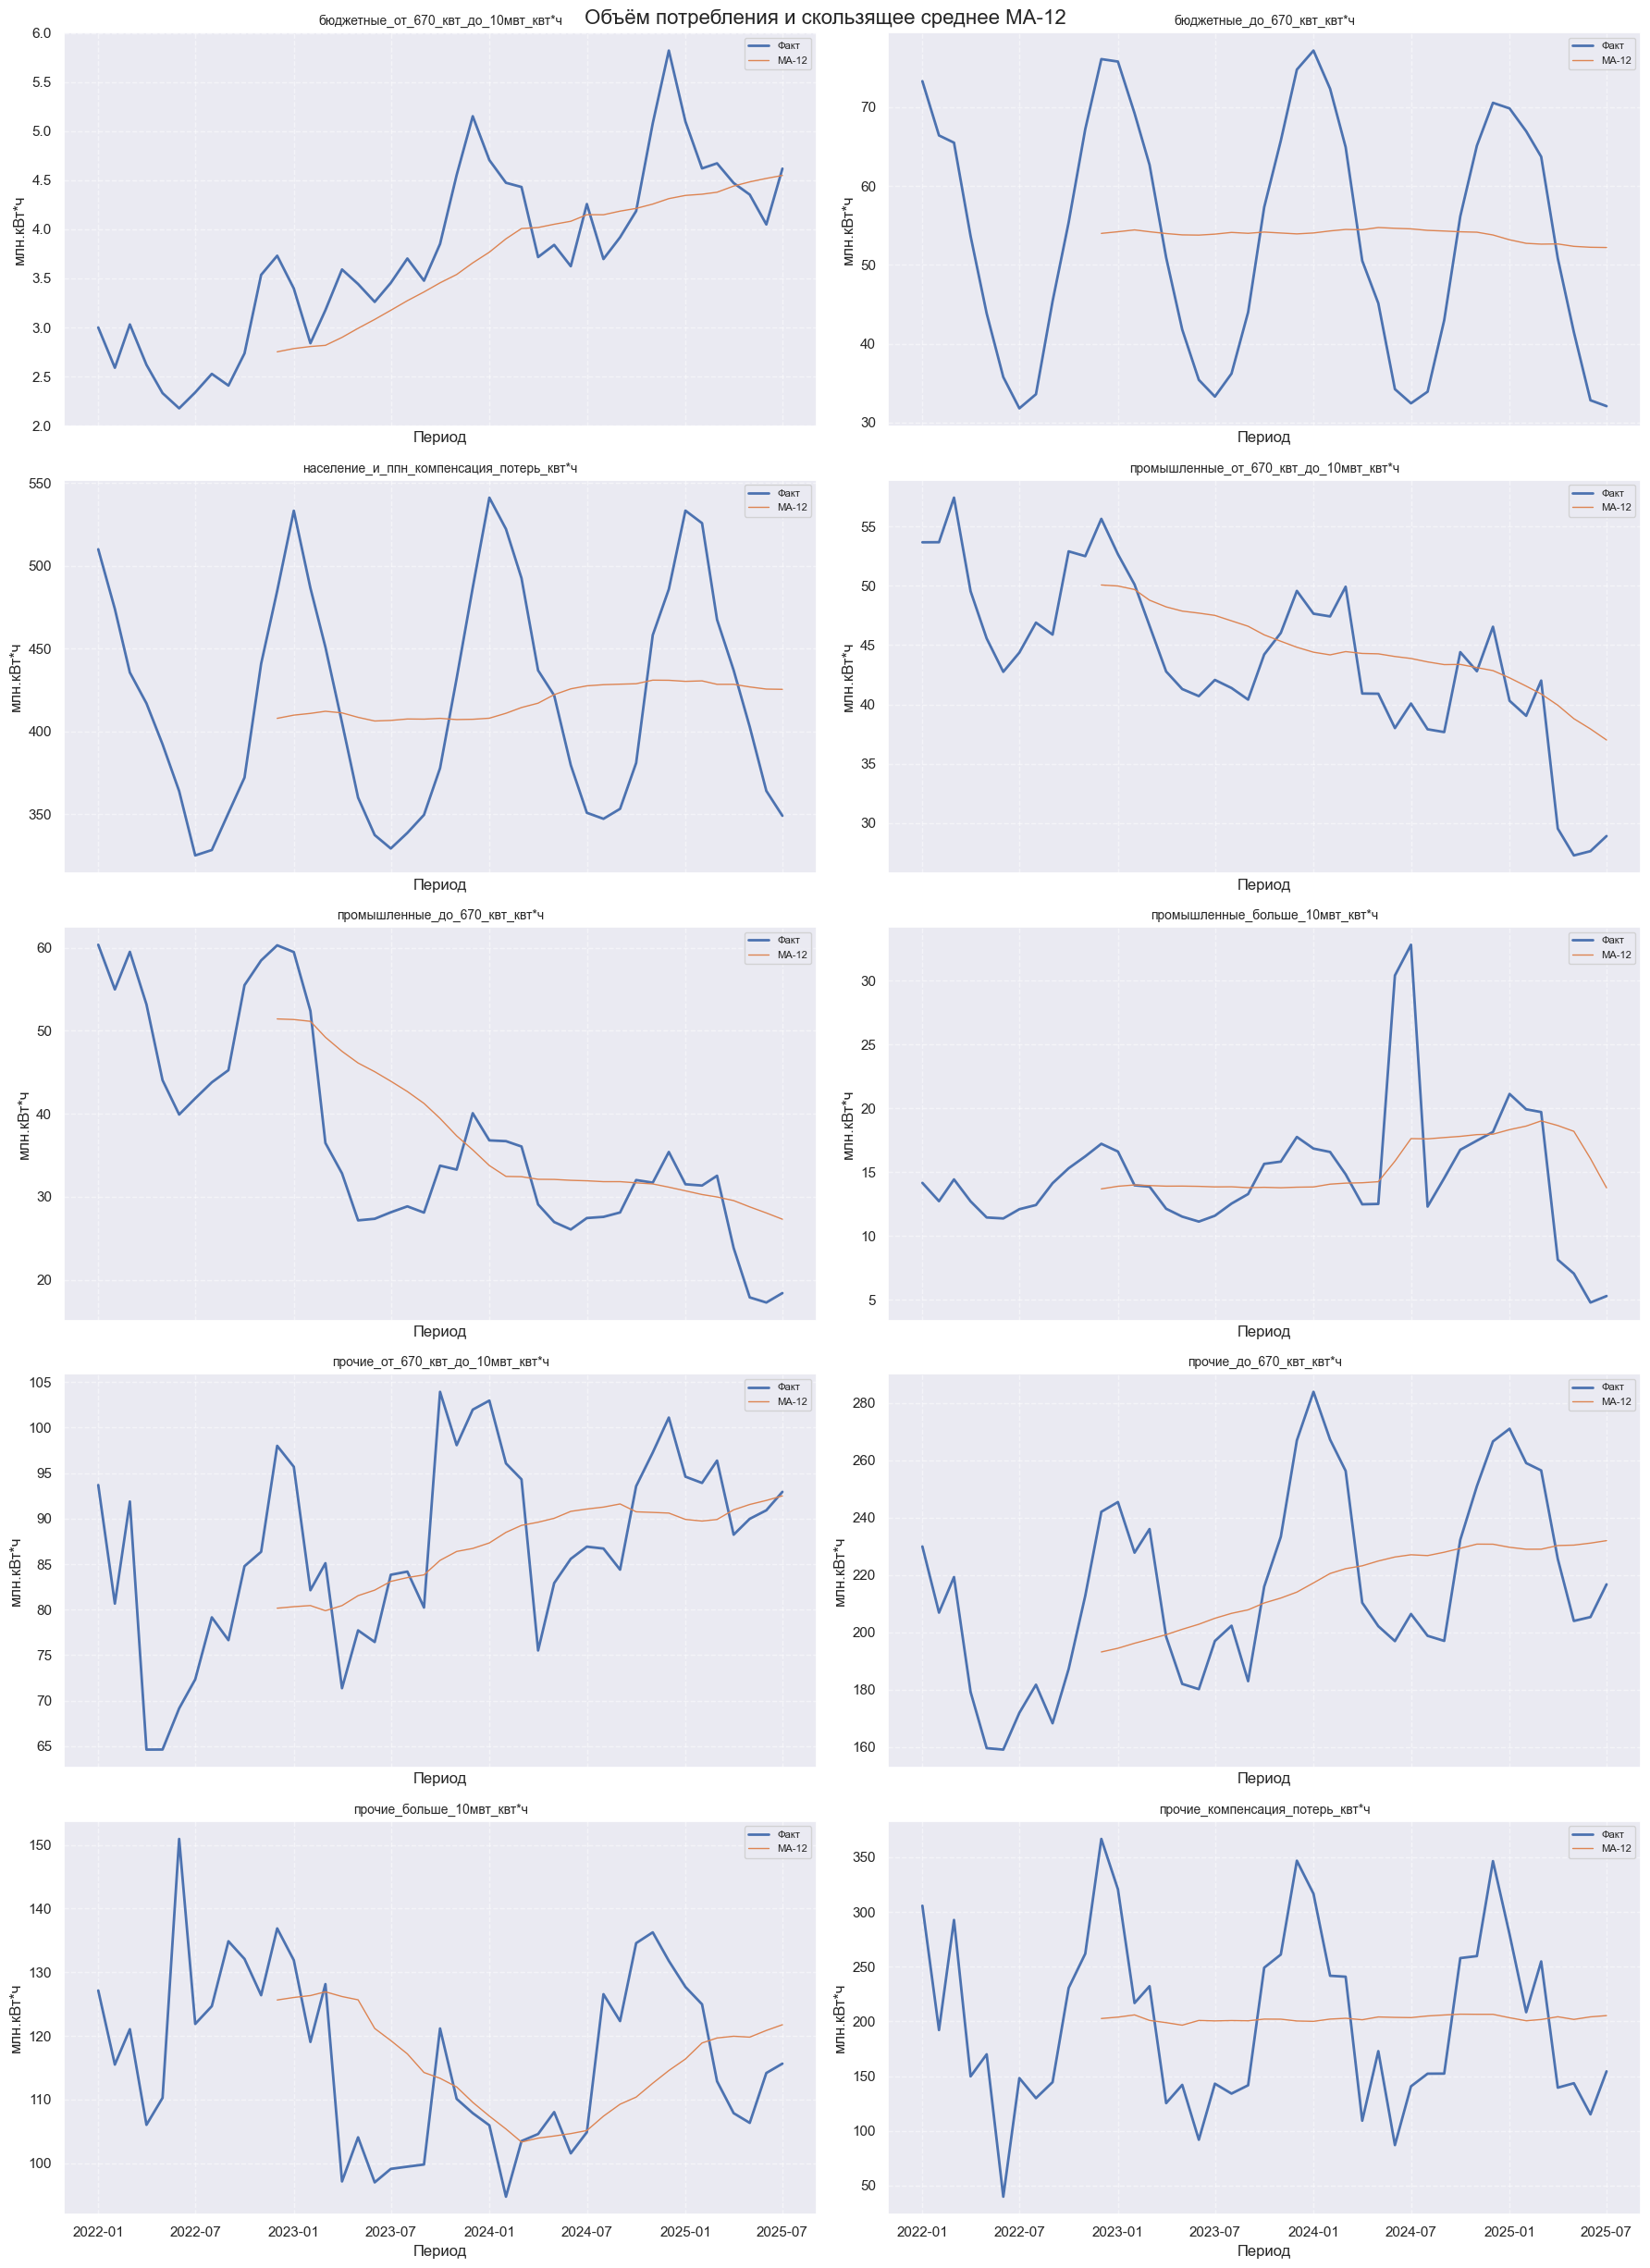

In [20]:
import math
import matplotlib.pyplot as plt

n = len(value_cols)
ncols = 2
nrows = math.ceil(n / ncols)

# Скользящее среднее за 12 месяцев

# 5 строк на 2 столбца = 10 графиков
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 5 * nrows),
    sharex=True
)

axes = axes.flatten()

for ax, value_col in zip(axes, value_cols):
    #расчет скользящего среднего
    ma12 = ts[value_col].rolling(window=12).mean()

    # Фактический объем
    ax.plot(
        ts.index,
        ts[value_col],
        label='Факт',
        linewidth=2
    )

    # Скользящее среднее МА-12
    ax.plot(
        ts.index,
        ma12,
        label='MA-12',
        linewidth=1
    )

    # Заголовок графика
    ax.set_title(value_col, fontsize=10)

    # Оси
    ax.set_xlabel('Период')
    ax.set_ylabel('млн.кВт*ч')
    ax.grid(
        linestyle='--',
        alpha=0.5
    )

    ax.legend(fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(
    'Объём потребления и скользящее среднее MA-12',
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [21]:
# Разложение всех временных рядов по категориям потребителей

decomposition = {}

for col in value_cols:
    # Разложение по одному временному ряду
    y = ts[col].dropna()

    # Аддитивное
    additive = seasonal_decompose(
        y,
        model='additive',
        period=12
    )

    # Мультипликативное
    if (y > 0).all():
        multiplicative = seasonal_decompose(
            y,
            model='multiplicative',
            period=12
        )
    else:
        multiplicative = None

    # STL
    stl = STL(
        y,
        period=12,
        robust=True
    ).fit()

    # Результаты
    decomposition[col] = {
        'y': y,
        'additive': additive,
        'multiplicative': multiplicative,
        'stl': stl
    }

In [22]:
# проверка
decomposition[value_cols[0]]

{'y': период_потребители
 2022-01-01    2.999725
 2022-02-01    2.589740
 2022-03-01    3.031050
 2022-04-01    2.619697
 2022-05-01    2.331795
 2022-06-01    2.176592
 2022-07-01    2.339012
 2022-08-01    2.527635
 2022-09-01    2.408539
 2022-10-01    2.736226
 2022-11-01    3.535783
 2022-12-01    3.730610
 2023-01-01    3.396917
 2023-02-01    2.839589
 2023-03-01    3.176449
 2023-04-01    3.590799
 2023-05-01    3.442424
 2023-06-01    3.260682
 2023-07-01    3.453993
 2023-08-01    3.702344
 2023-09-01    3.476313
 2023-10-01    3.850941
 2023-11-01    4.553192
 2023-12-01    5.151092
 2024-01-01    4.704736
 2024-02-01    4.473394
 2024-03-01    4.430645
 2024-04-01    3.716972
 2024-05-01    3.841027
 2024-06-01    3.623795
 2024-07-01    4.256671
 2024-08-01    3.696968
 2024-09-01    3.918328
 2024-10-01    4.185525
 2024-11-01    5.079170
 2024-12-01    5.819890
 2025-01-01    5.096883
 2025-02-01    4.619787
 2025-03-01    4.671849
 2025-04-01    4.471003
 2025-05-01    

In [23]:
# Сводная таблица декомпозиции
decomposition_table = []

for col, result in decomposition.items():
    additive = result['additive']
    multiplicative = result['multiplicative']
    stl = result['stl']

    df_dec_table = pd.DataFrame({
        'Дата': additive.observed.index,
        'Показатель': col,
        'Факт': additive.observed,

        # Аддитивная
        'Тренд_аддитивная': additive.trend,
        'Сезонность_аддитивная': additive.seasonal,
        'Остатки_аддитивная': additive.resid,

        #STL
        'Тренд_STL': additive.trend,
        'Сезонность_STL': additive.seasonal,
        'Остатки_STL': additive.resid,
    })

    # Мультипликативная
    if multiplicative is not None:
        df_dec_table['Тренд_мультипликативная']: multiplicative.trend
        df_dec_table['Сезонность_мультипликативная']: multiplicative.seasonal
        df_dec_table['Остатки_мультипликативная']: multiplicative.resid
    else:
        df_dec_table['Тренд_мультипликативная']: np.nan
        df_dec_table['Сезонность_мультипликативная']: np.nan
        df_dec_table['Остатки_мультипликативная']: np.nan

    decomposition_table.append(df_dec_table)

# Объединение показателей
decomposition_table = pd.concat(
    decomposition_table,
    ignore_index=True)

decomposition_table.head(1000)

,Дата,Показатель,Факт,Тренд_аддитивная,Сезонность_аддитивная,Остатки_аддитивная,Тренд_STL,Сезонность_STL,Остатки_STL
0,2022-01-01,бюджетные_от_670_квт_до_10мвт_квт*ч,2.999725,NaN,0.472004,NaN,NaN,0.472004,NaN
1,2022-02-01,бюджетные_от_670_квт_до_10мвт_квт*ч,2.589740,NaN,-0.031500,NaN,NaN,-0.031500,NaN
2,2022-03-01,бюджетные_от_670_квт_до_10мвт_квт*ч,3.031050,NaN,0.059741,NaN,NaN,0.059741,NaN
3,2022-04-01,бюджетные_от_670_квт_до_10мвт_квт*ч,2.619697,NaN,-0.151568,NaN,NaN,-0.151568,NaN
4,2022-05-01,бюджетные_от_670_квт_до_10мвт_квт*ч,2.331795,NaN,-0.226076,NaN,NaN,-0.226076,NaN
...,...,...,...,...,...,...,...,...,...
425,2025-03-01,прочие_компенсация_потерь_квт*ч,254.791787,NaN,34.168818,NaN,NaN,34.168818,NaN
426,2025-04-01,прочие_компенсация_потерь_квт*ч,139.476146,NaN,-85.790456,NaN,NaN,-85.790456,NaN
427,2025-05-01,прочие_компенсация_потерь_квт*ч,143.500602,NaN,-46.188754,NaN,NaN,-46.188754,NaN
428,2025-06-01,прочие_компенсация_потерь_квт*ч,115.046844,NaN,-113.705531,NaN,NaN,-113.705531,NaN


In [24]:
# Сезонные индексы по 12 месяцам для мультипликативного разложения

seasonal_table = []

for col, result in decomposition.items():
    multiplicative = result['multiplicative']

    if multiplicative is None:
        continue

    seasonal_index = (
        multiplicative.seasonal
        .groupby(multiplicative.seasonal.index.month)
        .mean()
    )

    seasonal_index.index = [
        'Январь', 'Февраль', 'Март', 'Апрель',
        'Май', 'Июнь', 'Июль', 'Август',
        'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'
    ]

    df_dec_table = seasonal_index.to_frame(name=col)

    seasonal_table.append(df_dec_table)

seasonal_table = pd.concat(
    seasonal_table,
    axis=1,
)

seasonal_table.round(3)

,бюджетные_от_670_квт_до_10мвт_квт*ч,бюджетные_до_670_квт_квт*ч,население_и_ппн_компенсация_потерь_квт*ч,промышленные_от_670_квт_до_10мвт_квт*ч,промышленные_до_670_квт_квт*ч,промышленные_больше_10мвт_квт*ч,прочие_от_670_квт_до_10мвт_квт*ч,прочие_до_670_квт_квт*ч,прочие_больше_10мвт_квт*ч,прочие_компенсация_потерь_квт*ч
Январь,1.120,1.389,1.280,1.083,1.216,1.199,1.110,1.208,1.056,1.510
Февраль,0.982,1.308,1.210,1.067,1.188,0.968,1.024,1.141,0.952,1.135
Март,1.012,1.180,1.130,1.067,1.007,0.915,1.028,1.132,1.034,1.167
Апрель,0.971,0.939,1.008,0.930,0.870,0.786,0.839,0.934,0.905,0.577
Май,0.948,0.804,0.933,0.921,0.785,0.762,0.913,0.870,0.949,0.772
Июнь,0.878,0.647,0.856,0.889,0.795,1.242,0.917,0.849,0.887,0.440
Июль,0.921,0.605,0.807,0.919,0.842,1.166,0.946,0.898,0.932,0.712
Август,0.908,0.644,0.812,0.922,0.882,0.813,0.973,0.906,1.002,0.686
Сентябрь,0.879,0.822,0.841,0.915,0.906,0.903,0.936,0.846,1.018,0.724
Октябрь,0.957,1.050,0.902,1.057,1.096,1.025,1.089,0.974,1.115,1.221


**Интерпретация моделей**

_Аддитивная модель предполагает:_ сезонная прибавка примерно постоянна.

_Мультипликативная:_сезонность зависит от уровня ряда.

**Получаем индексы сезонности по 12 месяцам**

**Аддитивные индексы**: _Интерпретация - в январе потребление в среднем выше тренда на 0.15 кВт·ч._

**Мультипликативные индексы**: _Интерпретация_

* 1.00 → сезонного эффекта нет
* 1.08 → показатель примерно на 8% выше обычного
* 0.94 → показатель примерно на 6% ниже обычного

**Интерпретация сезонных индексов STL-разложения**

Сезонные индексы показывают отклонение от среднего уровня ряда для каждого месяца.

* Положительные значения — потребление выше среднего в этот месяц.
* Отрицательные значения — потребление ниже среднего.

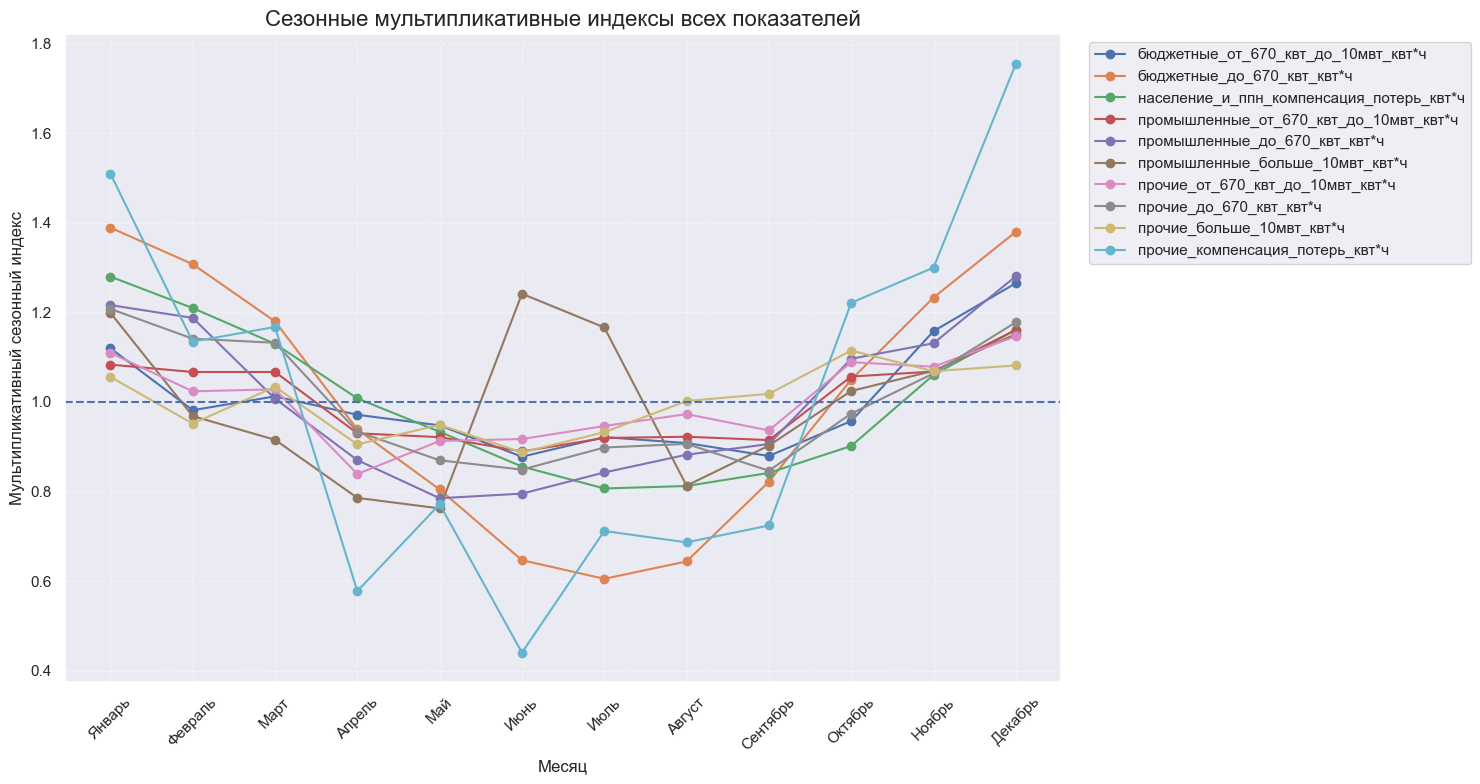

In [25]:
# Графическое представление всех мультипликативных индексов сезонности

plt.figure(figsize=(15, 8))

for col in seasonal_table.columns:

    plt.plot(
        seasonal_table.index,
        seasonal_table[col],
        marker='o',
        linewidth=1.5,
        label=col
    )


# Нормальный уровень
plt.axhline(
    1,
    linestyle='--',
    linewidth=1.5
)


plt.title(
    'Сезонные мультипликативные индексы всех показателей',
    fontsize=16
)

plt.xlabel('Месяц')
plt.ylabel('Мультипликативный сезонный индекс')

plt.xticks(rotation=45)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

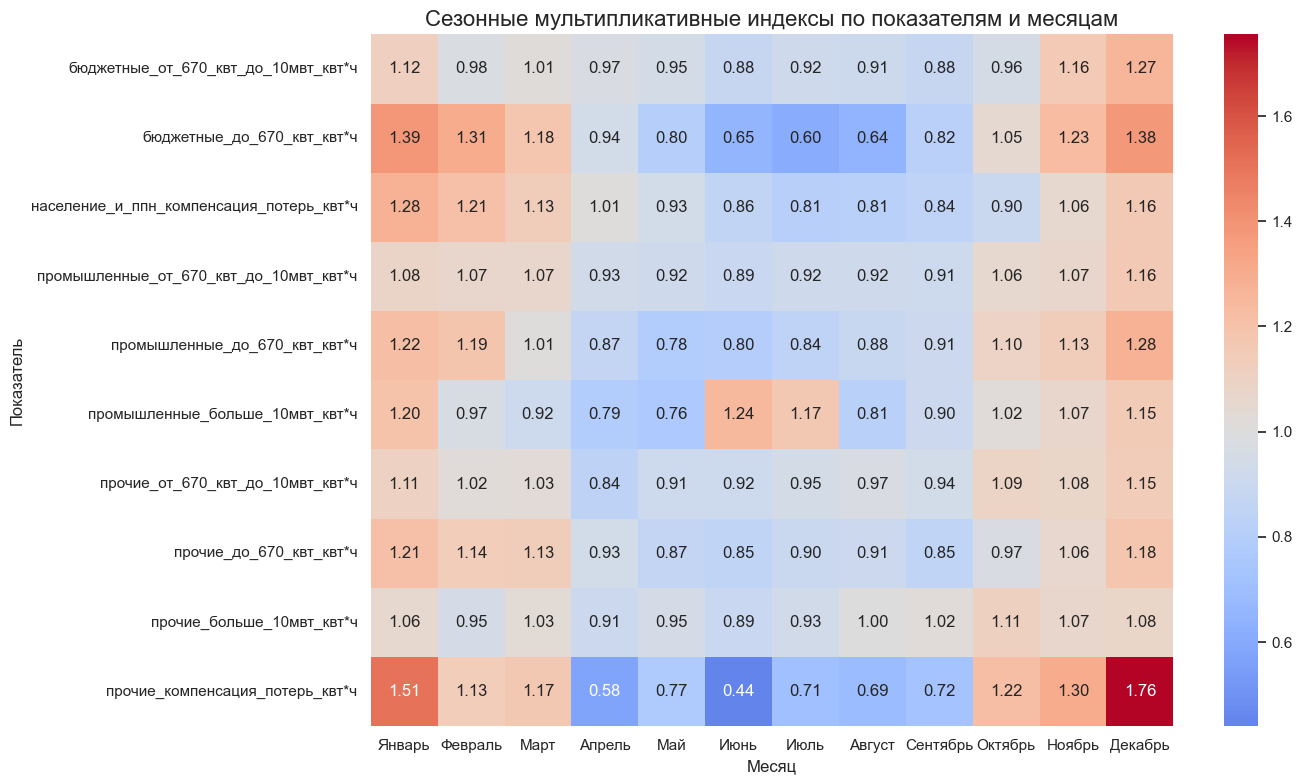

In [26]:
# Тепловая карта мультипликативных индексов
plt.figure(
    figsize=(14, 8)
)

sns.heatmap(
    seasonal_table.T,
    annot=True,
    fmt='.2f',
    center=1,
    cmap='coolwarm'
)

plt.title(
    'Сезонные мультипликативные индексы по показателям и месяцам',
    fontsize=16
)

plt.xlabel('Месяц')
plt.ylabel('Показатель')

plt.tight_layout()
plt.show()

In [27]:
# Сезонные индексы по 12 месяцам для аддитивного разложения

seasonal_table_addit = []

for col, result in decomposition.items():
    additive = result['additive']

    if additive is None:
        continue

    seasonal_index = (
        additive.seasonal
        .groupby(additive.seasonal.index.month)
        .mean()
    )

    seasonal_index.index = [
        'Январь', 'Февраль', 'Март', 'Апрель',
        'Май', 'Июнь', 'Июль', 'Август',
        'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'
    ]

    df_dec_table_addit = seasonal_index.to_frame(name=col)

    seasonal_table_addit.append(df_dec_table_addit)

seasonal_table_addit = pd.concat(
    seasonal_table_addit,
    axis=1,
)

seasonal_table_addit.round(3)

,бюджетные_от_670_квт_до_10мвт_квт*ч,бюджетные_до_670_квт_квт*ч,население_и_ппн_компенсация_потерь_квт*ч,промышленные_от_670_квт_до_10мвт_квт*ч,промышленные_до_670_квт_квт*ч,промышленные_больше_10мвт_квт*ч,прочие_от_670_квт_до_10мвт_квт*ч,прочие_до_670_квт_квт*ч,прочие_больше_10мвт_квт*ч,прочие_компенсация_потерь_квт*ч
Январь,0.472,20.851,116.924,3.697,8.100,2.917,9.487,45.808,6.451,103.362
Февраль,-0.031,16.676,87.407,3.094,7.169,-0.565,2.193,30.886,-5.267,27.521
Март,0.060,9.744,54.258,2.963,-0.411,-1.497,2.481,28.599,3.866,34.169
Апрель,-0.152,-3.308,3.300,-3.113,-4.885,-3.578,-14.132,-14.725,-10.868,-85.790
Май,-0.226,-10.551,-27.482,-3.482,-7.729,-3.928,-7.664,-28.771,-5.938,-46.189
Июнь,-0.501,-19.029,-60.248,-4.837,-7.005,4.785,-7.263,-33.602,-12.818,-113.706
Июль,-0.255,-21.225,-80.323,-3.722,-6.323,3.470,-4.486,-21.734,-7.897,-58.102
Август,-0.354,-19.123,-78.341,-3.442,-4.664,-3.141,-2.364,-20.518,0.240,-63.235
Сентябрь,-0.446,-9.555,-66.413,-3.766,-3.546,-1.753,-5.537,-33.284,2.323,-55.506
Октябрь,-0.171,2.677,-41.311,2.578,3.837,0.158,7.742,-5.384,12.690,44.860


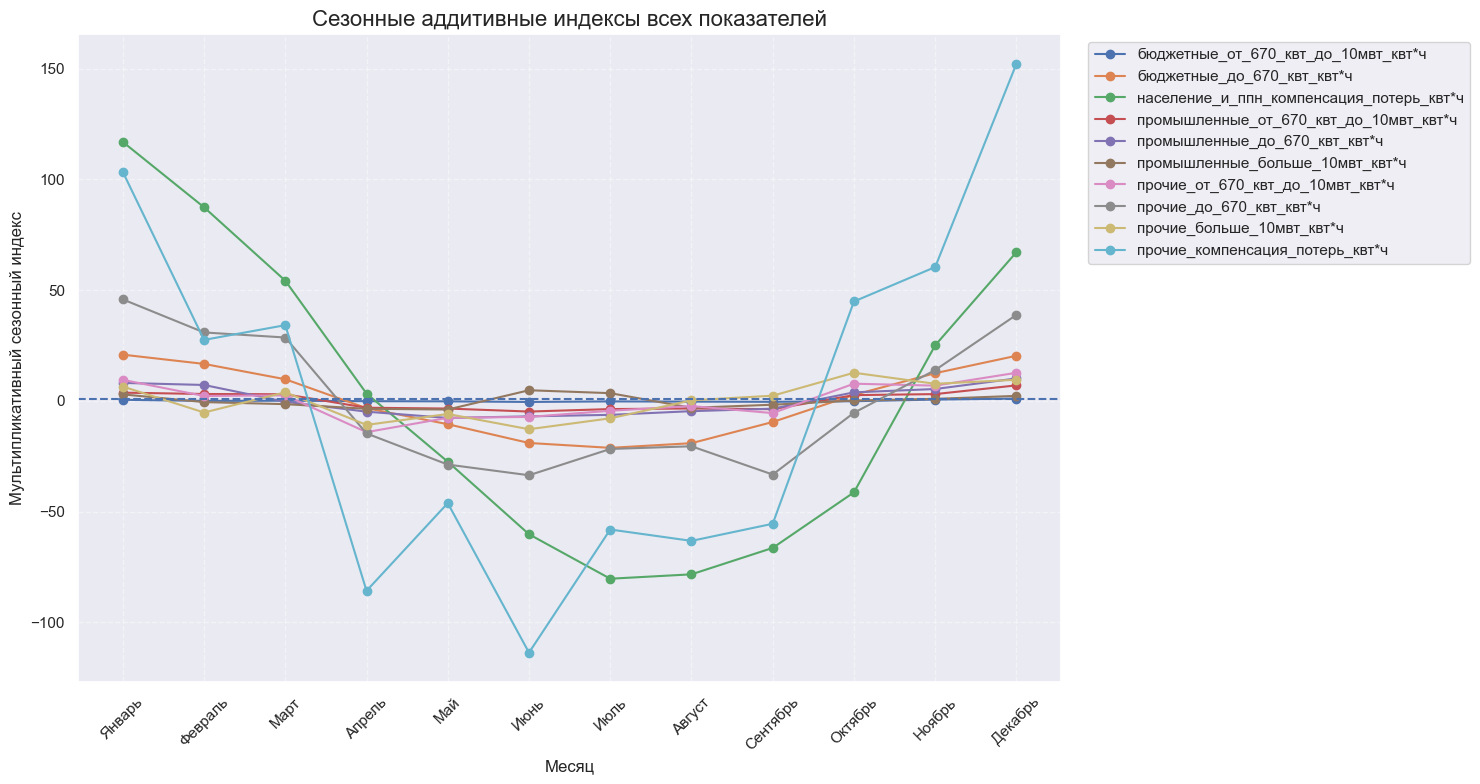

In [28]:
# Графическое представление всех аддитивных индексов сезонности

plt.figure(figsize=(15, 8))

for col in seasonal_table_addit.columns:

    plt.plot(
        seasonal_table_addit.index,
        seasonal_table_addit[col],
        marker='o',
        linewidth=1.5,
        label=col
    )


# Нормальный уровень
plt.axhline(
    1,
    linestyle='--',
    linewidth=1.5
)


plt.title(
    'Сезонные аддитивные индексы всех показателей',
    fontsize=16
)

plt.xlabel('Месяц')
plt.ylabel('Мультипликативный сезонный индекс')

plt.xticks(rotation=45)

plt.grid(
    linestyle='--',
    alpha=0.4
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

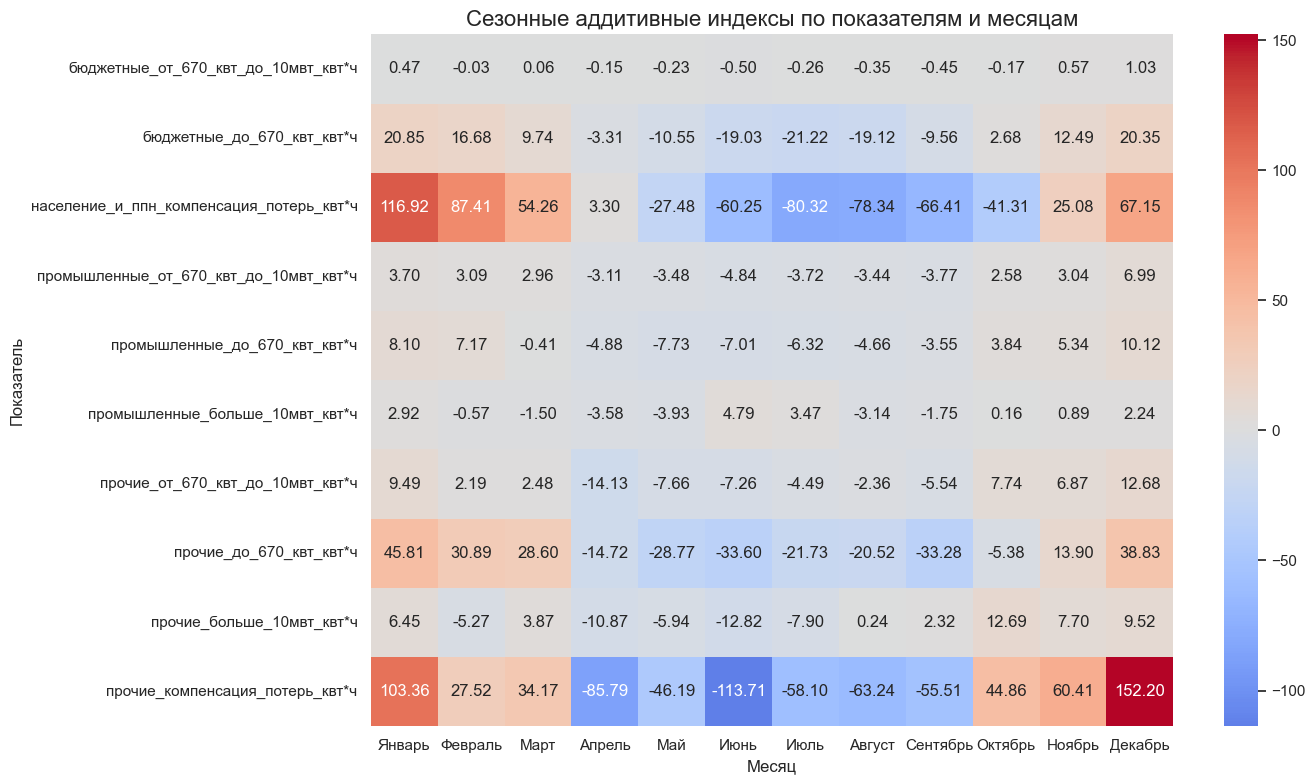

In [29]:
# Тепловая карта аддитивных индексов
plt.figure(
    figsize=(14, 8)
)

sns.heatmap(
    seasonal_table_addit.T,
    annot=True,
    fmt='.2f',
    center=1,
    cmap='coolwarm'
)

plt.title(
    'Сезонные аддитивные индексы по показателям и месяцам',
    fontsize=16
)

plt.xlabel('Месяц')
plt.ylabel('Показатель')

plt.tight_layout()
plt.show()

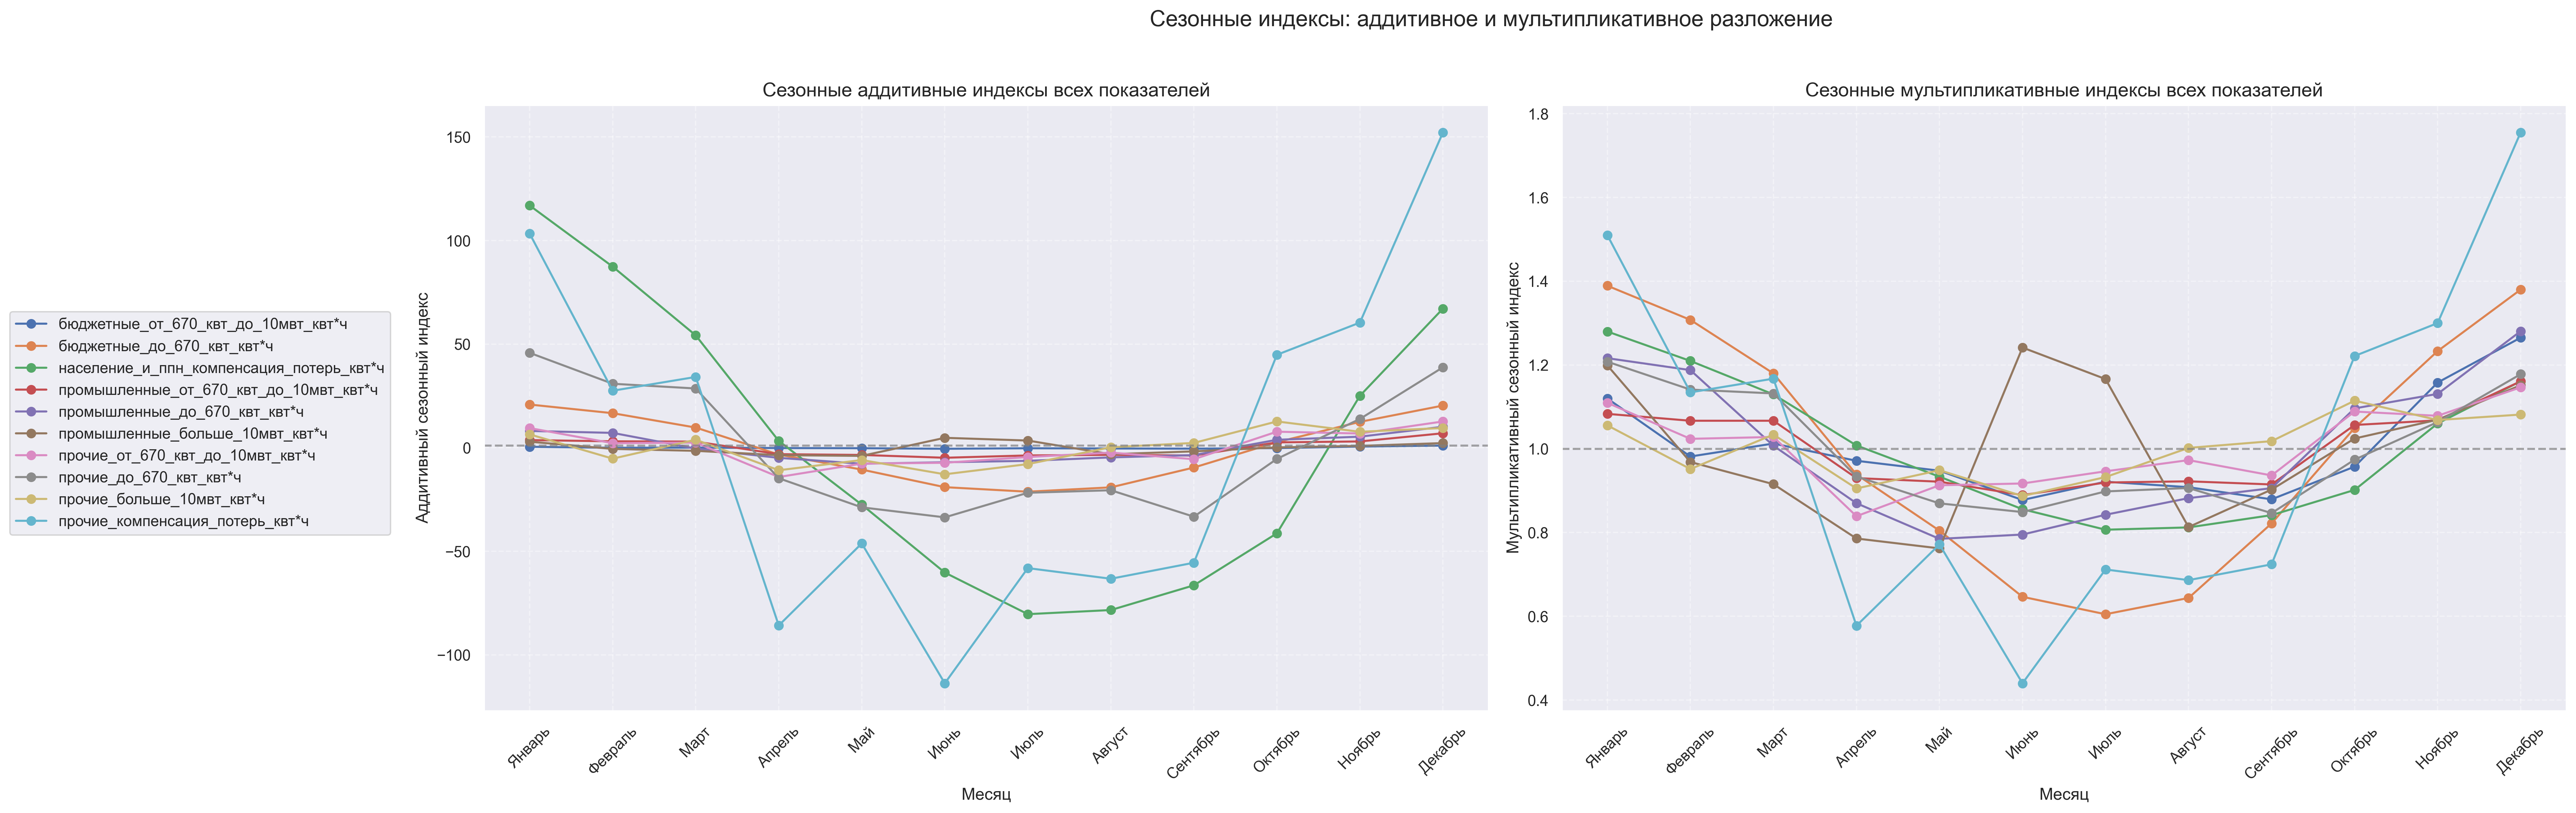

In [30]:
# индексы разложений
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(22, 8),      # общая ширина ~ 11 на каждый график
    dpi=300
)

# График 1: аддитивные сезонные индексы

ax1 = axes[0]

for col in seasonal_table_addit.columns:
    ax1.plot(
        seasonal_table_addit.index,
        seasonal_table_addit[col],
        marker='o',
        linewidth=1.5,
        label=col
    )

# Нормальный уровень
ax1.axhline(1, linestyle='--', linewidth=1.5, color='gray', alpha=0.7)

ax1.set_title('Сезонные аддитивные индексы всех показателей', fontsize=14)
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Аддитивный сезонный индекс')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(linestyle='--', alpha=0.4)
#ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# График 2: мультипликативные сезонные индексы

ax2 = axes[1]

for col in seasonal_table.columns:
    ax2.plot(
        seasonal_table.index,
        seasonal_table[col],
        marker='o',
        linewidth=1.5,
        label=col
    )

# Нормальный уровень
ax2.axhline(1, linestyle='--', linewidth=1.5, color='gray', alpha=0.7)

ax2.set_title('Сезонные мультипликативные индексы всех показателей', fontsize=14)
ax2.set_xlabel('Месяц')
ax2.set_ylabel('Мультипликативный сезонный индекс')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(linestyle='--', alpha=0.4)
#ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')


fig.suptitle('Сезонные индексы: аддитивное и мультипликативное разложение',
             fontsize=16, y=1.02)
fig.legend(*ax1.get_legend_handles_labels(), loc='center right', bbox_to_anchor=(0.0, 0.5))

plt.tight_layout()
plt.show()

In [31]:
# Свод данных для понимания лучшего описания разложения рядов потребления ЭЭ
# Расчет RMSE моделей декомпозиции

summary = []
for col, result in decomposition.items():
    additive = result['additive']
    multiplicative = result['multiplicative']
    stl = result['stl']

    #RMSE аддитивных остатков
    rmse_add = np.sqrt(np.nanmean(additive.resid ** 2))

    #RMSE STL остатков
    rmse_stl = np.sqrt(np.nanmean(stl.resid ** 2))

    #RMSE мультипликативных остатков
    if multiplicative is not None:
        # восстановление исходных данных
        fitted_mul = (multiplicative.trend * multiplicative.seasonal)

        actual_mul = multiplicative.observed

        rmse_mul = np.sqrt(np.nanmean((actual_mul - fitted_mul) ** 2))
    else:
        rmse_mul = np.nan

    summary.append({
        'Показатель': col,
        'RMSE additive': rmse_add,
        'RMSE multiplicative': rmse_mul,
        'RMSE STL': rmse_stl
    })

decomposition_summary = pd.DataFrame(
    summary
)

decomposition_summary.round(3)

,Показатель,RMSE additive,RMSE multiplicative,RMSE STL
0,бюджетные_от_670_квт_до_10мвт_квт*ч,0.193,0.176,0.216
1,бюджетные_до_670_квт_квт*ч,1.222,1.136,1.556
2,население_и_ппн_компенсация_потерь_квт*ч,8.476,8.769,11.249
3,промышленные_от_670_квт_до_10мвт_квт*ч,1.355,1.372,1.993
4,промышленные_до_670_квт_квт*ч,3.249,2.413,4.095
5,промышленные_больше_10мвт_квт*ч,3.488,3.331,4.764
6,прочие_от_670_квт_до_10мвт_квт*ч,2.811,2.905,3.547
7,прочие_до_670_квт_квт*ч,5.080,4.797,6.276
8,прочие_больше_10мвт_квт*ч,5.285,5.333,9.920
9,прочие_компенсация_потерь_квт*ч,10.268,10.459,15.214


**Вывод:**

Аддитивная модель прогнозирования более предпочтительна, т.к. средний штраф меньше. Колебания более постоянны. Компенсация потерь с Населением приемлемы в рамках сезонности.

### Этап 4. Проверка временного ряда и подготовка модели
1. Проверить стационарность.
2. При необходимости выполнить обычное и сезонное дифференцирование.
3. Исследовать ACF и PACF.
4. Сформировать кандидатов на параметры p, q, P, Q.

In [32]:
# Копия датафрейма для дальнейшего разложения рядов
ts = df_askp.copy()

period_col = 'период_потребители'

# Преобразуем период 2022.01 → datetime
ts[period_col] = pd.to_datetime(
    ts[period_col]
)

# Сортировка по времени
ts = ts.sort_values(period_col)

# Индекс = дата
ts = ts.set_index(period_col)

# Берём только необходимый показатель
value_cols = ts.columns.tolist()

# Показатели в числовой формат
ts[value_cols] = ts[value_cols].apply(pd.to_numeric, errors='coerce')

# Взять только числовые показатели
value_cols = ts.select_dtypes(include='number').columns.tolist()

# Проверяем ряд
print('Количество рядов:', len(value_cols))
print(value_cols)

Количество рядов: 10
['бюджетные_от_670_квт_до_10мвт_квт*ч', 'бюджетные_до_670_квт_квт*ч', 'население_и_ппн_компенсация_потерь_квт*ч', 'промышленные_от_670_квт_до_10мвт_квт*ч', 'промышленные_до_670_квт_квт*ч', 'промышленные_больше_10мвт_квт*ч', 'прочие_от_670_квт_до_10мвт_квт*ч', 'прочие_до_670_квт_квт*ч', 'прочие_больше_10мвт_квт*ч', 'прочие_компенсация_потерь_квт*ч']


In [33]:
#ADF-тест исходного ряда для стационарности
# H0: ряд нестационарный
# H1: ряд стационарный

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def run_adf_test(series):
    series = series.dropna()    #убрать пропуски

    #достаточность наблюдений
    if len(series) < 15:
        return {
            'ADF statistic': np.nan,
            'p-value': np.nan,
            'n_obs': len(series),
            'Стационарность': 'Недостаточно данных'
        }

    result = adfuller(series, autolag='AIC')

    p_value = result[1]

    if p_value < 0.05:
        conclusion = 'Стационарный'
    else:
        conclusion = 'Не стационарный'

    return {
        'ADF Statistic': result[0],
        'p-value': p_value,
        'n_obs': result[3],
        'Стационарность': conclusion
    }

In [34]:
# ADF для всех рядов и вариантов дифференцирования
seasonal_period = 12
adf_results = []

for value_col in value_cols:
    # исходный ряд
    y = ts[value_col].dropna()

    # обычное дифференцирование
    y_diff = y.diff()

    # сезонное дифференцирование
    y_seasonal_diff = y.diff(seasonal_period)

    #обычное и сезонное
    y_diff_seasonal = y.diff().diff(seasonal_period)

    # ADF исходного ряда
    result_original = run_adf_test(y)

    adf_results.append({
        'Показатель': value_col,
        'Ряд': 'Исходный',
        'd': 0,
        'D': 0,
        **result_original
    })

    # ADF обычной разности
    result_diff = run_adf_test(y_diff)
    adf_results.append({
        'Показатель': value_col,
        'Ряд': 'Обычная разность',
        'd': 1,
        'D': 0,
        **result_diff
    })

    # ADF сезонной разности
    result_seasonal = run_adf_test(y_seasonal_diff)
    adf_results.append({
        'Показатель': value_col,
        'Ряд': 'Сезонная разность',
        'd': 0,
        'D': 1,
        **result_seasonal
    })

    # ADF обычной и сезонной разности
    result_diff_seasonal = run_adf_test(y_diff_seasonal)
    adf_results.append({
        'Показатель': value_col,
        'Ряд': 'Обычная и Сезонная',
        'd': 1,
        'D': 1,
        **result_diff_seasonal
    })

# свод результатов в таблицу
adf_table = pd.DataFrame(adf_results)

adf_table['p-value'] = adf_table['p-value'].round(4)
adf_table['ADF Statistic'] = adf_table['ADF Statistic'].round(4)

adf_table

,Показатель,Ряд,d,D,ADF Statistic,p-value,n_obs,Стационарность
0,бюджетные_от_670_квт_до_10мвт_квт*ч,Исходный,0,0,-1.0588,0.7312,32,Не стационарный
1,бюджетные_от_670_квт_до_10мвт_квт*ч,Обычная разность,1,0,-4.2869,0.0005,33,Стационарный
2,бюджетные_от_670_квт_до_10мвт_квт*ч,Сезонная разность,0,1,-2.4295,0.1336,30,Не стационарный
3,бюджетные_от_670_квт_до_10мвт_квт*ч,Обычная и Сезонная,1,1,-6.5434,0.0000,29,Стационарный
4,бюджетные_до_670_квт_квт*ч,Исходный,0,0,-5.1276,0.0000,37,Стационарный
5,бюджетные_до_670_квт_квт*ч,Обычная разность,1,0,-5.6592,0.0000,31,Стационарный
6,бюджетные_до_670_квт_квт*ч,Сезонная разность,0,1,-3.3787,0.0117,30,Стационарный
7,бюджетные_до_670_квт_квт*ч,Обычная и Сезонная,1,1,-4.8646,0.0000,27,Стационарный
8,население_и_ппн_компенсация_потерь_квт*ч,Исходный,0,0,-0.8868,0.7923,32,Не стационарный
9,население_и_ппн_компенсация_потерь_квт*ч,Обычная разность,1,0,-5.6097,0.0000,32,Стационарный


In [35]:
# Необходимо выбрать минимальное необходимое дифференцирование

def choose_d_D(adf_df, indicator_):
    # Потребитель по таблице
    temp = adf_df[adf_df['Показатель'] == indicator_]

    #p-value для каждого варианта ряда
    p_original = temp.loc[temp['Ряд'] == 'Исходный', 'p-value'].iloc[0]

    p_diff = temp.loc[temp['Ряд'] == 'Обычная разность', 'p-value'].iloc[0]

    p_seasonal = temp.loc[temp['Ряд'] == 'Сезонная разность', 'p-value'].iloc[0]

    p_diff_seasonal = temp.loc[temp['Ряд'] == 'Обычная и Сезонная', 'p-value'].iloc[0]

    # минимальное необходимое дифференцирование
    if p_original < 0.05:
        d = 0
        D = 0

    elif p_diff < 0.05:
        d = 1
        D = 0

    elif p_seasonal < 0.05:
        d = 0
        D = 1

    elif p_diff_seasonal < 0.05:
        d = 1
        D = 1

    else:
        # ADF не показал стационарность
        d = np.nan
        D = np.nan

    return d, D


In [36]:
# Свод в таблицу итоговых d и D для всех потребителей

orders_table = []

for value_col in value_cols:
    d, D = choose_d_D(
        adf_table,
        value_col
    )
    orders_table.append({
        'Показатель': value_col,
        'd': d,
        'D': D,
        's': seasonal_period,
    })

orders_table = pd.DataFrame(orders_table)

orders_table

,Показатель,d,D,s
0,бюджетные_от_670_квт_до_10мвт_квт*ч,1,0,12
1,бюджетные_до_670_квт_квт*ч,0,0,12
2,население_и_ппн_компенсация_потерь_квт*ч,1,0,12
3,промышленные_от_670_квт_до_10мвт_квт*ч,1,0,12
4,промышленные_до_670_квт_квт*ч,1,0,12
5,промышленные_больше_10мвт_квт*ч,0,0,12
6,прочие_от_670_квт_до_10мвт_квт*ч,1,0,12
7,прочие_до_670_квт_квт*ч,1,0,12
8,прочие_больше_10мвт_квт*ч,1,0,12
9,прочие_компенсация_потерь_квт*ч,0,0,12


In [37]:
# Формирование стационарных рядов для ACF/PACF
stationary_series = {}

for _, row in orders_table.iterrows():
    indicator_ = row['Показатель']
    d = row['d']
    D = row['D']

    y = ts[indicator_].dropna().copy()

    # Если определить порядок не удалось
    if pd.isna(d) or pd.isna(D):
        stationary_series[indicator_] = None
        continue

    # Обычное дифференцирование
    if d == 1:
        y = y.diff()

    # Сезонное дифференцирование
    if D == 1:
        y = y.diff(seasonal_period)

    # Убрать NaN после дифференцирования
    y = y.dropna()

    stationary_series[indicator_] = y

stationary_series

{'бюджетные_от_670_квт_до_10мвт_квт*ч': период_потребители
 2022-02-01   -0.409985
 2022-03-01    0.441310
 2022-04-01   -0.411353
 2022-05-01   -0.287902
 2022-06-01   -0.155203
 2022-07-01    0.162420
 2022-08-01    0.188623
 2022-09-01   -0.119096
 2022-10-01    0.327687
 2022-11-01    0.799557
 2022-12-01    0.194827
 2023-01-01   -0.333693
 2023-02-01   -0.557328
 2023-03-01    0.336860
 2023-04-01    0.414350
 2023-05-01   -0.148375
 2023-06-01   -0.181742
 2023-07-01    0.193311
 2023-08-01    0.248351
 2023-09-01   -0.226031
 2023-10-01    0.374628
 2023-11-01    0.702251
 2023-12-01    0.597900
 2024-01-01   -0.446356
 2024-02-01   -0.231342
 2024-03-01   -0.042749
 2024-04-01   -0.713673
 2024-05-01    0.124055
 2024-06-01   -0.217232
 2024-07-01    0.632876
 2024-08-01   -0.559703
 2024-09-01    0.221360
 2024-10-01    0.267197
 2024-11-01    0.893645
 2024-12-01    0.740720
 2025-01-01   -0.723007
 2025-02-01   -0.477096
 2025-03-01    0.052062
 2025-04-01   -0.200846
 2025

In [38]:
# Определение значимых лагов

def significant_lags(values, nlags, n):
    # 95% доверительная граница для ACF/PACF
    threshold = 1.96 / np.sqrt(n)

    lags = []

    for lag in range(1, min(nlags + 1, len(values))):
        if abs(values[lag]) > threshold:
            lags.append(lag)
    return lags, threshold

In [39]:
# ACF / PACF и предварительный выбор p, q, P, Q

acf_pacf_results = []

for indicator_, y in stationary_series.items():
    # Если стационарный ряд не удалось получить
    if y is None or len(y) < 20:
        acf_pacf_results.append({
            'Показатель': indicator_,
            'p': np.nan,
            'q': np.nan,
            'P': np.nan,
            'Q': np.nan,
            'Значимые ACF лаги': None,
            'Значимые PACF лаги': None
        })

        continue

    # Максимальный лаг.
    # Для 43 месяцев после дифференцирования 24 достаточно
    nlags = min(24, len(y) // 2 - 1)

    # ACF
    acf_values = acf(
        y,
        nlags=nlags,
        fft=False
    )

    # PACF
    pacf_values = pacf(
        y,
        nlags=nlags,
        method='ywm'
    )

    # Значимые лаги
    acf_lags, threshold = significant_lags(
        acf_values,
        nlags,
        len(y)
    )

    pacf_lags, _ = significant_lags(
        pacf_values,
        nlags,
        len(y)
    )

    # Лаги 1-3
    # Для q смотрим ACF
    nonseasonal_acf = [
        lag for lag in acf_lags
        if lag in [1, 2, 3]
    ]

    # Для p смотрим PACF
    nonseasonal_pacf = [
        lag for lag in pacf_lags
        if lag in [1, 2, 3]
    ]

    # Сезонный лаг 12
    Q = 1 if 12 in acf_lags else 0
    P = 1 if 12 in pacf_lags else 0

    # Предварительный p
    if len(nonseasonal_pacf) > 0:
        p = max(nonseasonal_pacf)
    else:
        p = 0

    # Предварительный q
    if len(nonseasonal_acf) > 0:
        q = max(nonseasonal_acf)
    else:
        q = 0

    acf_pacf_results.append({
        'Показатель': indicator_,
        'p': p,
        'q': q,
        'P': P,
        'Q': Q,
        'Значимые ACF лаги': acf_lags,
        'Значимые PACF лаги': pacf_lags
    })

acf_pacf_table = pd.DataFrame(
    acf_pacf_results
)

acf_pacf_table

,Показатель,p,q,P,Q,Значимые ACF лаги,Значимые PACF лаги
0,бюджетные_от_670_квт_до_10мвт_квт*ч,0,0,0,1,"[6, 12]","[6, 9]"
1,бюджетные_до_670_квт_квт*ч,3,2,0,1,"[1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, ...","[1, 2, 3]"
2,население_и_ппн_компенсация_потерь_квт*ч,3,2,0,1,"[1, 2, 4, 5, 6, 7, 8, 11, 12, 13, 14, 17, 18, 19]","[1, 3, 4]"
3,промышленные_от_670_квт_до_10мвт_квт*ч,0,0,0,1,"[6, 12, 18]",[6]
4,промышленные_до_670_квт_квт*ч,0,0,0,0,"[5, 6]",[5]
5,промышленные_больше_10мвт_квт*ч,1,1,0,0,[1],[1]
6,прочие_от_670_квт_до_10мвт_квт*ч,1,1,0,1,"[1, 6, 8, 12, 18]","[1, 6, 8]"
7,прочие_до_670_квт_квт*ч,0,0,1,1,"[6, 12, 18]","[6, 8, 12]"
8,прочие_больше_10мвт_квт*ч,1,1,0,0,[1],[1]
9,прочие_компенсация_потерь_квт*ч,3,2,0,1,"[1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, ...","[1, 3, 4, 6]"


In [40]:
# Таблица ADF + d/D + ACF/PACF + p/q/P/Q
final_stationarity_table = (
    orders_table.merge(
        acf_pacf_table,
        on='Показатель',
        how='left'
    )
)

# p-value по каждому варианту
adf_pivot = (adf_table.pivot(
        index='Показатель',
        columns='Ряд',
        values='p-value'
    ).reset_index()
)

adf_pivot = adf_pivot.rename(
    columns={
        'Исходный': 'ADF p-value исходный',
        'Обычная разность': 'ADF p-value d=1',
        'Сезонная разность': 'ADF p-value D=1',
        'Обычная + сезонная': 'ADF p-value d=1,D=1'
    }
)

final_stationarity_table = (
    adf_pivot.merge(
        orders_table,
        on='Показатель',
        how='left'
    )
    .merge(
        acf_pacf_table[
            [
                'Показатель',
                'p',
                'q',
                'P',
                'Q',
                'Значимые ACF лаги',
                'Значимые PACF лаги'
            ]
        ],
        on='Показатель',
        how='left'
    )
)

final_stationarity_table

,Показатель,ADF p-value исходный,Обычная и Сезонная,ADF p-value d=1,ADF p-value D=1,d,D,s,p,q,P,Q,Значимые ACF лаги,Значимые PACF лаги
0,бюджетные_до_670_квт_квт*ч,0.0000,0.0000,0.0000,0.0117,0,0,12,3,2,0,1,"[1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, ...","[1, 2, 3]"
1,бюджетные_от_670_квт_до_10мвт_квт*ч,0.7312,0.0000,0.0005,0.1336,1,0,12,0,0,0,1,"[6, 12]","[6, 9]"
2,население_и_ппн_компенсация_потерь_квт*ч,0.7923,0.0000,0.0000,0.1379,1,0,12,3,2,0,1,"[1, 2, 4, 5, 6, 7, 8, 11, 12, 13, 14, 17, 18, 19]","[1, 3, 4]"
3,промышленные_больше_10мвт_квт*ч,0.0057,0.0000,0.0000,0.7569,0,0,12,1,1,0,0,[1],[1]
4,промышленные_до_670_квт_квт*ч,0.0774,0.0000,0.0000,0.2884,1,0,12,0,0,0,0,"[5, 6]",[5]
5,промышленные_от_670_квт_до_10мвт_квт*ч,0.9852,0.0000,0.0001,0.2724,1,0,12,0,0,0,1,"[6, 12, 18]",[6]
6,прочие_больше_10мвт_квт*ч,0.1421,0.0000,0.0000,0.2659,1,0,12,1,1,0,0,[1],[1]
7,прочие_до_670_квт_квт*ч,0.4593,0.0001,0.0001,0.1755,1,0,12,0,0,1,1,"[6, 12, 18]","[6, 8, 12]"
8,прочие_компенсация_потерь_квт*ч,0.0000,0.0000,0.0000,0.0001,0,0,12,3,2,0,1,"[1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, ...","[1, 3, 4, 6]"
9,прочие_от_670_квт_до_10мвт_квт*ч,0.7455,0.0000,0.0001,0.0106,1,0,12,1,1,0,1,"[1, 6, 8, 12, 18]","[1, 6, 8]"


#### Визуализация

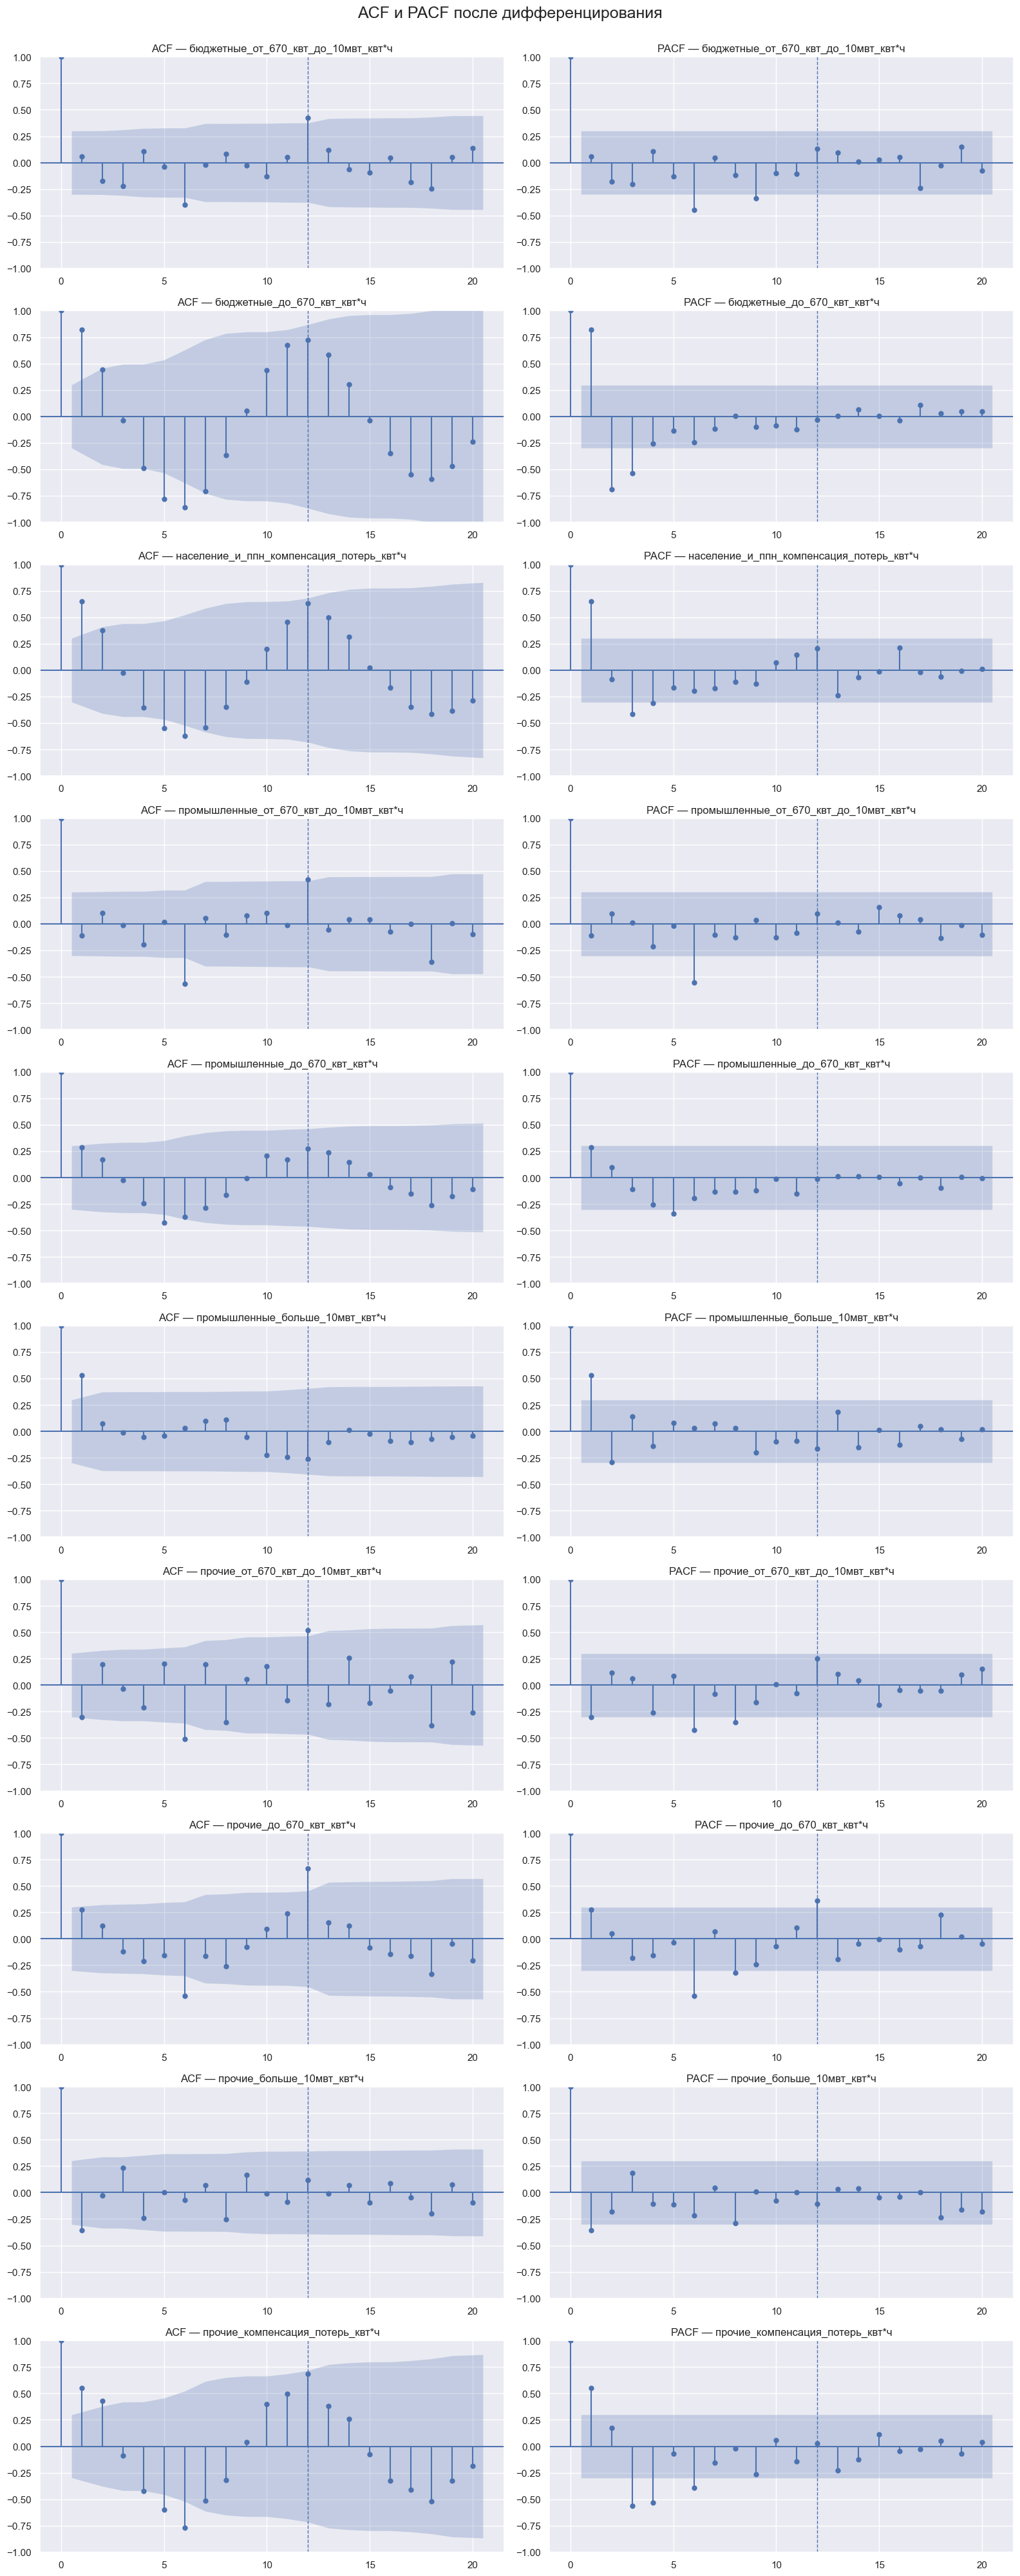

In [41]:
# Общий холст ACF + PACF для всех показателей

n = len(value_cols)

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n)
)


# Если показатель только один,
# axes будет не двумерным массивом
if n == 1:
    axes = np.array([axes])


for i, indicator in enumerate(value_cols):

    y = stationary_series[indicator]

    # Если стационарный ряд не получен
    if y is None:

        axes[i, 0].set_visible(False)
        axes[i, 1].set_visible(False)

        continue


    nlags = min(
        24,
        len(y) // 2 - 1
    )


    # ACF

    plot_acf(
        y,
        lags=nlags,
        ax=axes[i, 0],
        alpha=0.05
    )

    axes[i, 0].set_title(
        f'ACF — {indicator}'
    )

    axes[i, 0].axvline(
        12,
        linestyle='--',
        linewidth=1
    )


    # PACF

    plot_pacf(
        y,
        lags=nlags,
        ax=axes[i, 1],
        alpha=0.05,
        method='ywm'
    )

    axes[i, 1].set_title(
        f'PACF — {indicator}'
    )

    axes[i, 1].axvline(
        12,
        linestyle='--',
        linewidth=1
    )


# Общий заголовок
fig.suptitle(
    'ACF и PACF после дифференцирования',
    fontsize=18,
    y=1.0
)


plt.tight_layout()
plt.show()

**Выводы из графиков**
1. Почти всем рядам нужно дифференцирование — в 7 из 10 строк d=1. Это значит, что у большинства сегментов есть явный тренд (рост или падение потребления со временем), который нужно убрать перед моделированием.
2. Сезонность везде 12 месяцев — параметр s=12 постоянен. Это логично для энергопотребления: январь каждого года похож на январь предыдущего.
3. Сезонное дифференцирование не нужно — везде D=0. Сезонный паттерн стабилен, не требует отдельного сглаживания.
4. Сложные модели для бюджетных и «прочих» сегментов — у них высокие p и q (до 3 и 2), а также много значимых лагов. Это говорит о сложной структуре автокорреляции: на текущее потребление влияет много прошлых значений.
5. Простые модели для крупных промышленных потребителей — строки 3, 4, 6 имеют низкие p и q (часто 0 или 1). Крупные потребители ведут себя более предсказуемо, их динамика проще.
6. Сезонное MA (Q) встречается часто — в 6 из 10 строк Q=1. Это значит, что ошибки прогноза имеют сезонную структуру: если в прошлом январе прогноз ошибся, то в этом январе ошибка будет похожей.

### Итоговая таблица для SARIMA ###

In [42]:
# Финальная таблица параметров SARIMA

sarima_orders = final_stationarity_table[
    [
        'Показатель',
        'd',
        'D',
        'p',
        'q',
        'P',
        'Q'
    ]
].copy()

# Cезонный период
sarima_orders['s'] = 12

# Создаём текстовое представление модели
sarima_orders['SARIMA'] = sarima_orders.apply(
    lambda row:
        f"({int(row['p'])},"
        f"{int(row['d'])},"
        f"{int(row['q'])})"
        f"×("
        f"{int(row['P'])},"
        f"{int(row['D'])},"
        f"{int(row['Q'])},"
        f"12)",
    axis=1
)

sarima_orders

,Показатель,d,D,p,q,P,Q,s,SARIMA
0,бюджетные_до_670_квт_квт*ч,0,0,3,2,0,1,12,"(3,0,2)×(0,0,1,12)"
1,бюджетные_от_670_квт_до_10мвт_квт*ч,1,0,0,0,0,1,12,"(0,1,0)×(0,0,1,12)"
2,население_и_ппн_компенсация_потерь_квт*ч,1,0,3,2,0,1,12,"(3,1,2)×(0,0,1,12)"
3,промышленные_больше_10мвт_квт*ч,0,0,1,1,0,0,12,"(1,0,1)×(0,0,0,12)"
4,промышленные_до_670_квт_квт*ч,1,0,0,0,0,0,12,"(0,1,0)×(0,0,0,12)"
5,промышленные_от_670_квт_до_10мвт_квт*ч,1,0,0,0,0,1,12,"(0,1,0)×(0,0,1,12)"
6,прочие_больше_10мвт_квт*ч,1,0,1,1,0,0,12,"(1,1,1)×(0,0,0,12)"
7,прочие_до_670_квт_квт*ч,1,0,0,0,1,1,12,"(0,1,0)×(1,0,1,12)"
8,прочие_компенсация_потерь_квт*ч,0,0,3,2,0,1,12,"(3,0,2)×(0,0,1,12)"
9,прочие_от_670_квт_до_10мвт_квт*ч,1,0,1,1,0,1,12,"(1,1,1)×(0,0,1,12)"


**Получившиеся итоговые таблицы**

1. adf_table
   ->
   ADF для каждого показателя и каждого варианта
   дифференцирования

2. orders_table
   ->
   d, D для каждого показателя

3. stationary_series
   ->
   стационарные версии всех 10 рядов

4. acf_pacf_table
   ->
   значимые лаги ACF/PACF
   и кандидаты p,q,P,Q

5. final_stationarity_table
   ->
   полный отчёт

6. sarima_orders
   ->
   готовые кандидаты SARIMA
   для следующего этапа моделирования

### Этап 5. Статистическая проверка гипотез
1. Проверить распределения и предпосылки статистических методов.
2. Сравнить группы и средние значения.
3. Оценить корреляционные зависимости.
4. Проверить категориальные взаимосвязи.
5. Интерпретировать результаты через p-value + effect size + бизнес-смысл.

In [43]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.anova import anova_lm

from itertools import combinations
from scipy import stats
from statsmodels.stats.multitest import multipletests

| Задача                      | Тест           | H₀                       | Что смотрим     |
| --------------------------- | -------------- | ------------------------ | --------------- |
| Нормальность кВт·ч          | Shapiro–Wilk   | нормальное распределение | `p-value`       |
| Нормальность руб.           | Shapiro–Wilk   | нормальное распределение | `p-value`       |
| Нормальность                | KS             | нормальное распределение | `p-value`       |
| Различие средних по годам   | ANOVA          | средние одинаковы        | `p-value`       |
| Различие по годам           | Kruskal–Wallis | группы одинаковы         | `p-value`       |
| 2022 vs 2023                | Mann–Whitney   | группы одинаковы         | `p-value`       |
| Объём ↔ стоимость           | Pearson        | `r = 0`                  | `r`, `p-value`  |
| Объём ↔ стоимость           | Spearman       | `ρ = 0`                  | `ρ`, `p-value`  |
| Категории объём ↔ стоимость | χ²             | независимы               | `χ²`, `p-value` |


| Этап           | Что смотрим       | Главный вопрос                                        |
| -------------- | ----------------- | ----------------------------------------------------- |
| Нормальность   | Shapiro / KS      | Можно ли считать распределение близким к нормальному? |
| t-тест         | p-value corrected | Отличаются ли средние двух категорий?                 |
| ANOVA          | p-value           | Есть ли вообще различия между категориями?            |
| Mann–Whitney   | p-value corrected | Есть ли различия распределений двух категорий?        |
| Kruskal–Wallis | p-value           | Есть ли различия между несколькими категориями?       |
| Pearson        | `r`, p-value      | Есть ли линейная связь?                               |
| Spearman       | `rho`, p-value    | Есть ли монотонная связь?                             |
| Chi-square     | p-value corrected | Связаны ли бинаризированные признаки?                 |
| Cramer's V     | `V`               | Насколько сильна категориальная связь?                |


In [44]:
# ТЕСТЫ НА НОРМАЛЬНОСТЬ

normality_results = []

for value_col in value_cols:

    # Текущий ряд
    y = ts[value_col].dropna()

    # Шапиро–Уилк
    # H0: распределение нормальное

    shapiro_stat, shapiro_p = stats.shapiro(y)

    # Колмогоров–Смирнов
    # Стандартизируем ряд

    y_standardized = ((y - y.mean()) / y.std(ddof=1))

    ks_stat, ks_p = stats.kstest(y_standardized, 'norm')

    # Интерпретация Шапиро

    if shapiro_p < 0.05:
        shapiro_conclusion = 'Нормальность не подтверждается'
    else:
        shapiro_conclusion = 'Нет оснований отвергать нормальность'

    # Интерпретация KS

    if ks_p < 0.05:
        ks_conclusion = 'Нормальность не подтверждается'
    else:
        ks_conclusion = 'Нет оснований отвергать нормальность'

    # Сохраняем результат

    normality_results.append({
        'Показатель': value_col,
        'Среднее': y.mean(),
        'Стандартное отклонение': y.std(ddof=1),

        'Shapiro statistic': shapiro_stat,
        'Shapiro p-value': shapiro_p,
        'Shapiro вывод': shapiro_conclusion,

        'KS statistic': ks_stat,
        'KS p-value': ks_p,
        'KS вывод': ks_conclusion

    })

normality_table = pd.DataFrame(
    normality_results
)

# Округление
normality_table = normality_table.round(4)

normality_table

,Показатель,Среднее,Стандартное отклонение,Shapiro statistic,Shapiro p-value,Shapiro вывод,KS statistic,KS p-value,KS вывод
0,бюджетные_от_670_квт_до_10мвт_квт*ч,3.7337,0.8805,0.9782,0.5782,Нет оснований отвергать нормальность,0.0648,0.9884,Нет оснований отвергать нормальность
1,бюджетные_до_670_квт_квт*ч,53.4575,15.3708,0.9079,0.0022,Нормальность не подтверждается,0.1448,0.2985,Нет оснований отвергать нормальность
2,население_и_ппн_компенсация_потерь_квт*ч,419.3458,67.0821,0.9298,0.0114,Нормальность не подтверждается,0.1353,0.3767,Нет оснований отвергать нормальность
3,промышленные_от_670_квт_до_10мвт_квт*ч,43.8981,7.1382,0.9549,0.0903,Нет оснований отвергать нормальность,0.1103,0.6322,Нет оснований отвергать нормальность
4,промышленные_до_670_квт_квт*ч,37.0207,12.2894,0.9140,0.0034,Нормальность не подтверждается,0.1584,0.2078,Нет оснований отвергать нормальность
5,промышленные_больше_10мвт_квт*ч,14.6902,5.1610,0.8716,0.0002,Нормальность не подтверждается,0.1516,0.2499,Нет оснований отвергать нормальность
6,прочие_от_670_квт_до_10мвт_квт*ч,86.9079,10.1555,0.9709,0.3384,Нет оснований отвергать нормальность,0.0960,0.7872,Нет оснований отвергать нормальность
7,прочие_до_670_квт_квт*ч,216.0755,32.6552,0.9691,0.2949,Нет оснований отвергать нормальность,0.0999,0.7471,Нет оснований отвергать нормальность
8,прочие_больше_10мвт_квт*ч,116.4315,13.5951,0.9580,0.1170,Нет оснований отвергать нормальность,0.1271,0.4538,Нет оснований отвергать нормальность
9,прочие_компенсация_потерь_квт*ч,200.2125,79.9034,0.9513,0.0665,Нет оснований отвергать нормальность,0.1821,0.1017,Нет оснований отвергать нормальность


Проверка стационарности всех рядов...

                                     Показатель  ADF p-value      ADF вывод  KPSS p-value     KPSS вывод
            бюджетные_от_670_квт_до_10мвт_квт*ч       0.7312 НЕ стационарен        0.0100 НЕ стационарен
     бюджетные_от_670_квт_до_10мвт_квт*ч (diff)       0.0005    стационарен        0.1000    стационарен
                     бюджетные_до_670_квт_квт*ч       0.0000    стационарен        0.1000    стационарен
              бюджетные_до_670_квт_квт*ч (diff)       0.0000    стационарен        0.1000    стационарен
       население_и_ппн_компенсация_потерь_квт*ч       0.7923 НЕ стационарен        0.1000    стационарен
население_и_ппн_компенсация_потерь_квт*ч (diff)       0.0000    стационарен        0.1000    стационарен
         промышленные_от_670_квт_до_10мвт_квт*ч       0.9852 НЕ стационарен        0.0128 НЕ стационарен
  промышленные_от_670_квт_до_10мвт_квт*ч (diff)       0.0001    стационарен        0.1000    стационарен
                

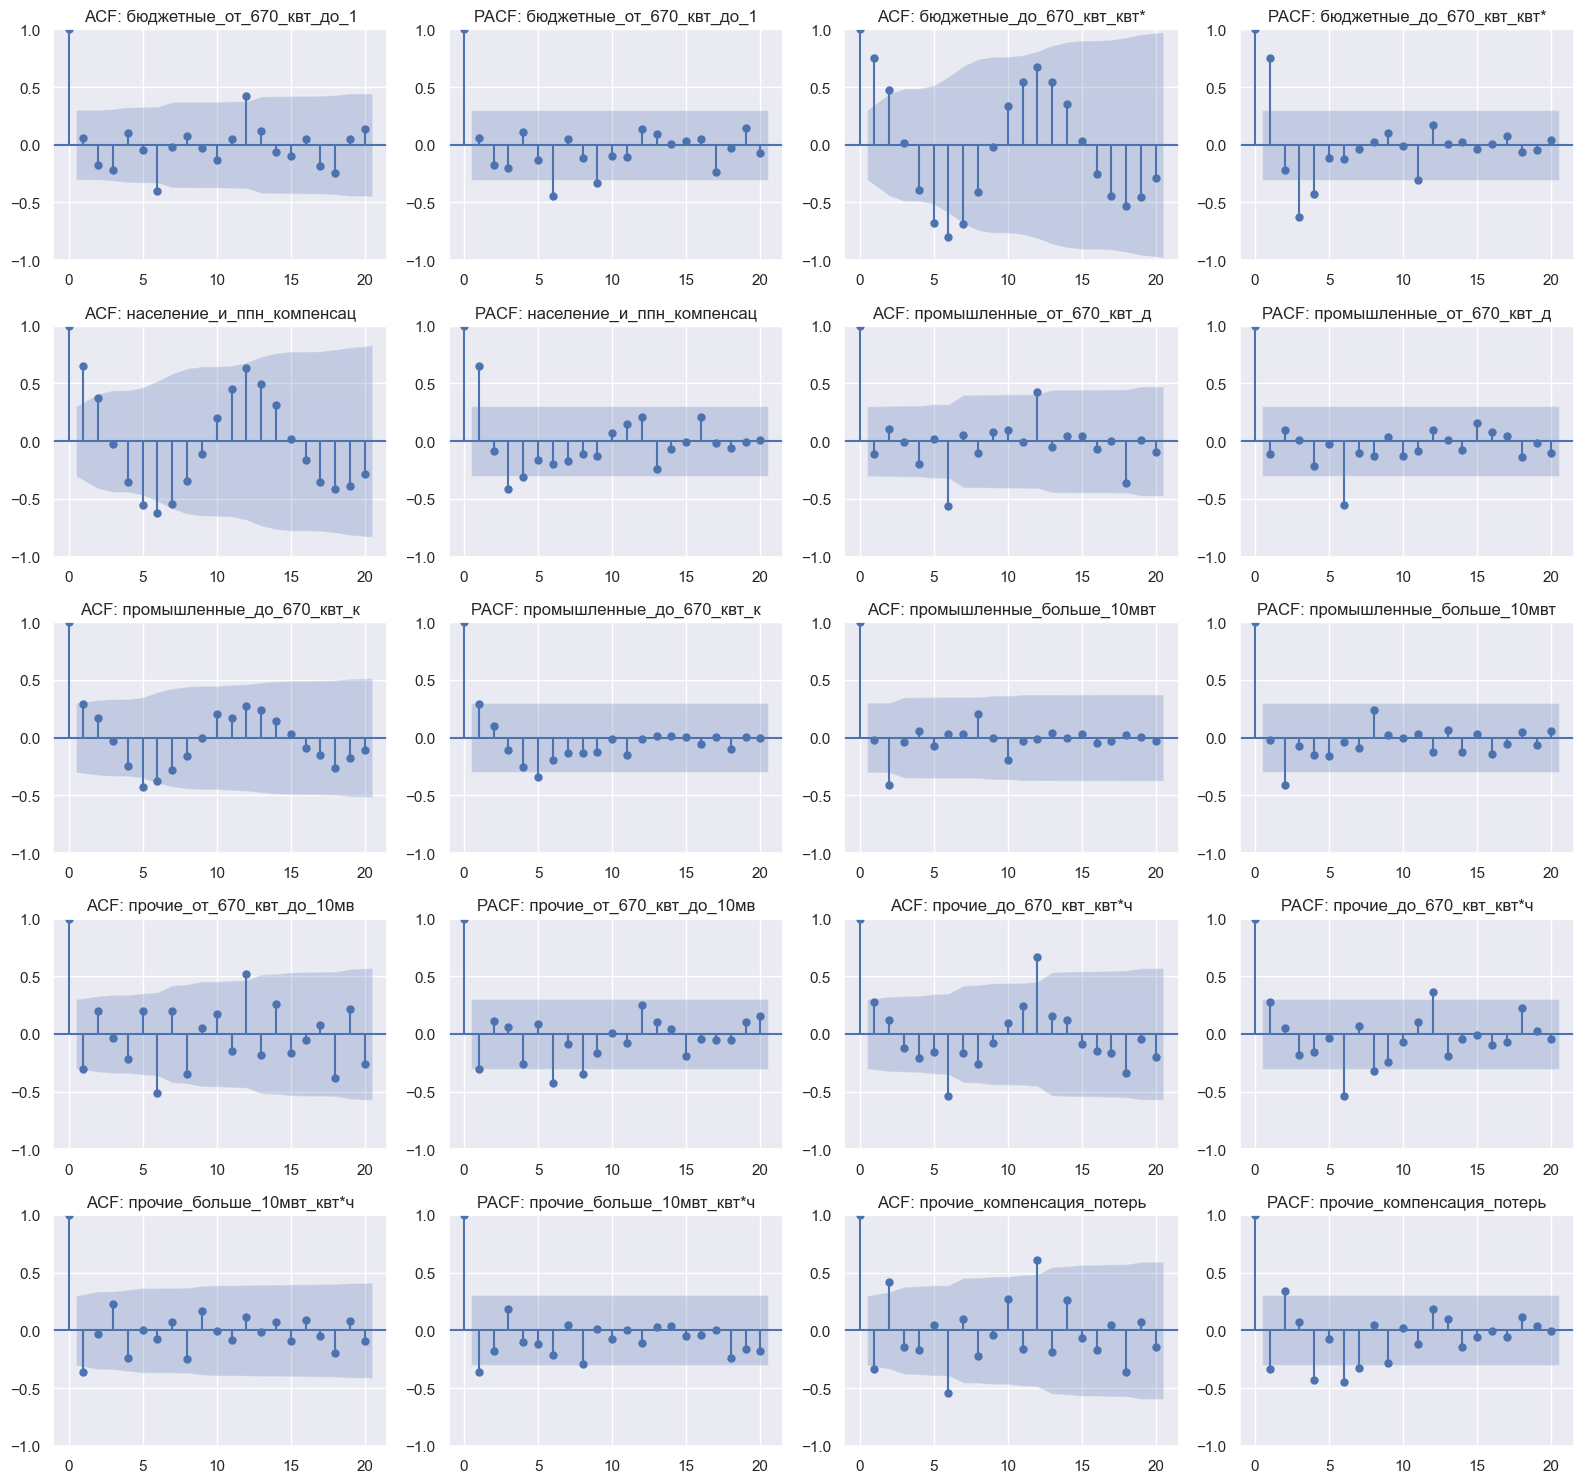

Оценка силы сезонности (STL)...

                              Показатель  Сила сезонности
     бюджетные_от_670_квт_до_10мвт_квт*ч            0.795
              бюджетные_до_670_квт_квт*ч            0.990
население_и_ппн_компенсация_потерь_квт*ч            0.971
  промышленные_от_670_квт_до_10мвт_квт*ч            0.814
           промышленные_до_670_квт_квт*ч            0.694
         промышленные_больше_10мвт_квт*ч            0.143
        прочие_от_670_квт_до_10мвт_квт*ч            0.845
                 прочие_до_670_квт_квт*ч            0.962
               прочие_больше_10мвт_квт*ч            0.377
         прочие_компенсация_потерь_квт*ч            0.963

ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА ЭТАПА 5
                              Показатель  ADF p-value      ADF вывод  KPSS p-value     KPSS вывод  Сила сезонности
     бюджетные_от_670_квт_до_10мвт_квт*ч       0.7312 НЕ стационарен        0.0100 НЕ стационарен            0.795
              бюджетные_до_670_квт_квт*ч       0.0000    стациона

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, jarque_bera
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings('ignore')


results = []          # сюда будем собирать сводную таблицу

# 1. Функция проверки стационарности (ADF + KPSS)

def check_stationarity(series, name):
    series = series.dropna()

    # ADF: H0 = ряд нестационарен
    adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')

    # KPSS: H0 = ряд стационарен (противоположная гипотеза)
    try:
        kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
    except:
        kpss_p = np.nan

    return {
        'Показатель': name,
        'ADF p-value': round(adf_p, 4),
        'ADF вывод': 'стационарен' if adf_p < 0.05 else 'НЕ стационарен',
        'KPSS p-value': round(kpss_p, 4) if not np.isnan(kpss_p) else np.nan,
        'KPSS вывод': 'стационарен' if kpss_p > 0.05 else 'НЕ стационарен'
    }


# Проверка по всем рядам

print("Проверка стационарности всех рядов...\n")

for col in value_cols:
    res = check_stationarity(df_askp[col], col)
    results.append(res)

    # Дополнительно: стационарность после одного дифференцирования
    diff1 = df_askp[col].diff().dropna()
    res_diff = check_stationarity(diff1, col + ' (diff)')
    results.append(res_diff)

stationarity_table = pd.DataFrame(results)
print(stationarity_table.to_string(index=False))
print("\n")

# 3. ACF / PACF для понимания порядков модели

print("Строим ACF / PACF (после дифференцирования)...\n")

n_cols = 2
n_rows = (len(value_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols*2, figsize=(16, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(value_cols):
    series_diff = df_askp[col].diff().dropna()

    plot_acf(series_diff, lags=20, ax=axes[i*2], title=f'ACF: {col[:25]}')
    plot_pacf(series_diff, lags=20, ax=axes[i*2+1], title=f'PACF: {col[:25]}')

# Убираем лишние оси
for j in range(i*2+2, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 4. Быстрая проверка сезонности через STL (для информации)

print("Оценка силы сезонности (STL)...\n")

seasonality_strength = []

for col in value_cols:
    y = df_askp[col].dropna()
    if len(y) < 24:
        strength = np.nan
    else:
        stl = STL(y, period=12, robust=True).fit()
        # Сила сезонности = var(сезон) / (var(сезон) + var(остаток))
        strength = max(0, 1 - np.var(stl.resid) / np.var(stl.seasonal + stl.resid))

    seasonality_strength.append({
        'Показатель': col,
        'Сила сезонности': round(strength, 3) if not np.isnan(strength) else np.nan
    })

season_table = pd.DataFrame(seasonality_strength)
print(season_table.to_string(index=False))


# 5. Итоговая сводная таблица Этапа 5

print("\n" + "="*60)
print("ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА ЭТАПА 5")
print("="*60)

final_summary = stationarity_table[stationarity_table['Показатель'].isin(value_cols)].copy()
final_summary = final_summary.merge(season_table, on='Показатель', how='left')

print(final_summary.to_string(index=False))

### Этап 6. Построение моделей ###
1. Построить несколько моделей прогнозирования.
2. Сравнить базовые и сезонные подходы.
3. Обучить модели на train-выборке.
4. Получить прогнозы на тестовом периоде.

In [46]:
# Построение и сравнение моделей прогнозирования

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')


# Настройки

TEST_SIZE = 12          # последние 12 месяцев — тест
FORECAST_HORIZON = 6    # на сколько месяцев вперёд делаем финальный прогноз

results_list = []       # сюда собираем метрики всех моделей


# Функция для расчёта метрик

def calculate_metrics(y_true, y_pred, model_name, series_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        'Категория': series_name,
        'Модель': model_name,
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'MAPE_%': round(mape, 2)
    }

# Основной цикл по всем категориям

for col in value_cols:
    print(f"\nОбрабатываю: {col}")

    y = df_askp[col].dropna()
    train = y.iloc[:-TEST_SIZE]
    test  = y.iloc[-TEST_SIZE:]

    # ----- 2.1 Simple Exponential Smoothing -----
    try:
        ses = SimpleExpSmoothing(train).fit(optimized=True)
        ses_pred = ses.forecast(TEST_SIZE)
        results_list.append(calculate_metrics(test, ses_pred, 'SES', col))
    except Exception as e:
        print(f"  SES ошибка: {e}")

    # ----- 2.2 Holt (тренд, без сезонности) -----
    try:
        holt = Holt(train).fit(optimized=True)
        holt_pred = holt.forecast(TEST_SIZE)
        results_list.append(calculate_metrics(test, holt_pred, 'Holt', col))
    except Exception as e:
        print(f"  Holt ошибка: {e}")

    # ----- 2.3 Holt-Winters (аддитивный тренд + мультипликативная сезонность) -----
    try:
        hw = ExponentialSmoothing(
            train,
            trend='add',
            seasonal='mul',
            seasonal_periods=12
        ).fit(optimized=True)
        hw_pred = hw.forecast(TEST_SIZE)
        results_list.append(calculate_metrics(test, hw_pred, 'Holt-Winters', col))
    except Exception as e:
        print(f"  Holt-Winters ошибка: {e}")

    # ----- 2.4 SARIMA (простой вариант 1,1,1)(1,1,1)12 -----
    try:
        sarima = SARIMAX(
            train,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        sarima_pred = sarima.forecast(TEST_SIZE)
        results_list.append(calculate_metrics(test, sarima_pred, 'SARIMA', col))
    except Exception as e:
        print(f"  SARIMA ошибка: {e}")


# Сводная таблица результатов

comparison = pd.DataFrame(results_list)

print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА КАЧЕСТВА МОДЕЛЕЙ (на тестовой выборке 12 месяцев)")
print("="*70)
print(comparison.sort_values(['Категория', 'MAPE_%']).to_string(index=False))

# Лучшая модель по каждой категории
best_models = comparison.loc[comparison.groupby('Категория')['MAPE_%'].idxmin()]
print("\n" + "="*70)
print("ЛУЧШАЯ МОДЕЛЬ ПО КАЖДОЙ КАТЕГОРИИ (по MAPE)")
print("="*70)
print(best_models[['Категория', 'Модель', 'MAE', 'RMSE', 'MAPE_%']].to_string(index=False))


Обрабатываю: бюджетные_от_670_квт_до_10мвт_квт*ч

Обрабатываю: бюджетные_до_670_квт_квт*ч

Обрабатываю: население_и_ппн_компенсация_потерь_квт*ч

Обрабатываю: промышленные_от_670_квт_до_10мвт_квт*ч

Обрабатываю: промышленные_до_670_квт_квт*ч

Обрабатываю: промышленные_больше_10мвт_квт*ч

Обрабатываю: прочие_от_670_квт_до_10мвт_квт*ч

Обрабатываю: прочие_до_670_квт_квт*ч

Обрабатываю: прочие_больше_10мвт_квт*ч

Обрабатываю: прочие_компенсация_потерь_квт*ч

СВОДНАЯ ТАБЛИЦА КАЧЕСТВА МОДЕЛЕЙ (на тестовой выборке 12 месяцев)
                               Категория       Модель     MAE    RMSE  MAPE_%
              бюджетные_до_670_квт_квт*ч       SARIMA   2.633   3.252    5.01
              бюджетные_до_670_квт_квт*ч Holt-Winters   2.904   3.419    5.49
              бюджетные_до_670_квт_квт*ч          SES  19.828  24.475   32.48
              бюджетные_до_670_квт_квт*ч         Holt  36.623  39.511   69.11
     бюджетные_от_670_квт_до_10мвт_квт*ч       SARIMA   0.388   0.474    8.78
     

**Функция оценки моделей**

Используем три метрики:

1. MAE - Средняя абсолютная ошибка.

Например: MAE = 0.20 - означает, что прогноз в среднем ошибается примерно на 0.20 млн кВт·ч.

2. RMSE - Сильнее штрафует большие ошибки.
3. MAPE - Показывает среднюю ошибку в процентах.

**Модель 1 — простое экспоненциальное сглаживание**

Это Simple Exponential Smoothing.

Она хорошо подходит, когда ряд в основном описывается уровнем, без явного тренда и сезонности.

**Модель 2 — Хольт**

Хольт учитывает:
* уровень;
* тренд.

Но не моделирует сезонность.

**Модель 3 — Хольт–Винтерс**

Вот эта модель больше подходит для моих данных и временного ряда.

Она учитывает: уровень + тренд + сезонность.

Поскольку ранее выбрал мультипликативную сезонность, использую: seasonal='mul' и аддитивный тренд trend='add'

**ARIMA** - не учитывает сезонность

Ранее по ACF/PACF получено:

p = 1
q = 1

После дифференцирования для стационарности использую:

d = 1

Поэтому стартовая ARIMA:

ARIMA(1,1,1)

**SARIMA**

Результаты предыдущего этапа: p = 1, q = 1, P = 1, Q = 1

сезонность = 12

И после сезонного дифференцирования: D = 1

Итог: SARIMA(1,1,1)(1,1,1)12

По итогу всех оценок, наиболее предпочтительная модель SARIMA, т.к. имеет самый меньший процент по MAPE, наименьший штраф по RMSE и ошибку по MAE

По итогу визуализации, лучше всего описывает данные сезонности и колебаний модель Хольта - Винтерса. Только показатели завышены, относительно факта
SARIMA - при ее цифровой оценке по таблице выше, при прогнозе и визуализации показывает достаточно неточную картину.

### Этап 7. Диагностика моделей
1. Проверить остатки на автокорреляцию.
2. Проверить нормальность и среднее остатков.
3. Проанализировать диагностические графики.
4. Убедиться, что модель не оставляет систематическую структуру в ошибках.

### Этап 8. Валидация и выбор модели
1. Оценить MAE, RMSE, MAPE и другие релевантные метрики.
2. Проверить наличие систематического смещения.
3. Сравнить модели на одном и том же тестовом периоде.
4. Выбрать модель по совокупности качества прогноза + диагностик + бизнес-применимости.

In [55]:
# Обучение победителей + прогноз на 6 мес + 95% ДИ + графики

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Копия исходного датафрейма

df = df_askp.copy()

# Приводим столбец периода к datetime
if not pd.api.types.is_datetime64_any_dtype(df.index):

    if 'период_потребители' in df.columns:
        df['период'] = pd.to_datetime(
            df['период_потребители'].astype(str).str.replace('.', '', regex=False),
            format='%Y-%m-%d'
        )
        df = df.set_index('период')
    else:
        df.index = pd.to_datetime(
            df.index.astype(str).str.replace('.', '', regex=False),
            format='%Y%m'
        )

df = df.sort_index()
print("Индекс после преобразования:", df.index.dtype)
print("Последняя дата в данных:", df.index[-1])


# Словарь моделей - победителей (по таблице MAPE)

best_models_dict = {
    'бюджетные_до_670_квт_квт*ч':               'SARIMA',
    'бюджетные_от_670_квт_до_10мвт_квт*ч':      'SARIMA',
    'население_и_ппн_компенсация_потерь_квт*ч': 'Holt-Winters',
    'промышленные_больше_10мвт_квт*ч':          'SES',
    'промышленные_до_670_квт_квт*ч':            'Holt-Winters',
    'промышленные_от_670_квт_до_10мвт_квт*ч':   'SARIMA',
    'прочие_больше_10мвт_квт*ч':                'SARIMA',
    'прочие_до_670_квт_квт*ч':                  'SARIMA',
    'прочие_компенсация_потерь_квт*ч':          'Holt-Winters',
    'прочие_от_670_квт_до_10мвт_квт*ч':         'SARIMA',
}

FORECAST_HORIZON = 6
forecast_results = {}
ci_results = {}

# Функции обучения и прогноза

def fit_and_forecast(series, model_name, horizon=6):
    y = series.dropna()

    if model_name == 'SARIMA':
        model = SARIMAX(
            y,
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        forecast_obj = model.get_forecast(steps=horizon)
        pred = forecast_obj.predicted_mean
        ci = forecast_obj.conf_int(alpha=0.05)
        ci.columns = ['lower', 'upper']

    elif model_name == 'Holt-Winters':
        model = ExponentialSmoothing(
            y,
            trend='add',
            seasonal='mul',
            seasonal_periods=12
        ).fit(optimized=True)

        pred = model.forecast(horizon)
        resid_std = np.std(model.resid, ddof=1)
        ci = pd.DataFrame({
            'lower': pred - 1.96 * resid_std,
            'upper': pred + 1.96 * resid_std
        }, index=pred.index)

    elif model_name == 'SES':
        model = SimpleExpSmoothing(y).fit(optimized=True)
        pred = model.forecast(horizon)
        resid_std = np.std(model.resid, ddof=1)
        ci = pd.DataFrame({
            'lower': pred - 1.96 * resid_std,
            'upper': pred + 1.96 * resid_std
        }, index=pred.index)

    return pred, ci

# Обучение на всех данных + прогноз

print("\nОбучаю победившие модели на всех данных...\n")

for col, model_name in best_models_dict.items():
    print(f"{col[:50]:<50} → {model_name}")
    pred, ci = fit_and_forecast(df[col], model_name, FORECAST_HORIZON)
    forecast_results[col] = pred
    ci_results[col] = ci


# Создание будущих дат

last_date = pd.Timestamp(df.index[-1])          # принудительное Timestamp
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=FORECAST_HORIZON,
    freq='MS'
)

print("\nБудущие даты прогноза:")
print(future_dates)

# Итоговая таблица прогноза

final_forecast = pd.DataFrame(index=future_dates)

for col in best_models_dict.keys():
    final_forecast[col] = forecast_results[col].values
    final_forecast[f'{col}_lower'] = ci_results[col]['lower'].values
    final_forecast[f'{col}_upper'] = ci_results[col]['upper'].values

print("\n" + "="*70)
print("ИТОГОВЫЙ ПРОГНОЗ НА 6 МЕСЯЦЕВ (точечный + 95% ДИ)")
print("="*70)

final_forecast

Индекс после преобразования: datetime64[us]
Последняя дата в данных: 2025-07-01 00:00:00

Обучаю победившие модели на всех данных...

бюджетные_до_670_квт_квт*ч                         → SARIMA
бюджетные_от_670_квт_до_10мвт_квт*ч                → SARIMA
население_и_ппн_компенсация_потерь_квт*ч           → Holt-Winters
промышленные_больше_10мвт_квт*ч                    → SES
промышленные_до_670_квт_квт*ч                      → Holt-Winters
промышленные_от_670_квт_до_10мвт_квт*ч             → SARIMA
прочие_больше_10мвт_квт*ч                          → SARIMA
прочие_до_670_квт_квт*ч                            → SARIMA
прочие_компенсация_потерь_квт*ч                    → Holt-Winters
прочие_от_670_квт_до_10мвт_квт*ч                   → SARIMA

Будущие даты прогноза:
DatetimeIndex(['2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01', '2026-01-01'],
              dtype='datetime64[us]', freq='MS')

ИТОГОВЫЙ ПРОГНОЗ НА 6 МЕСЯЦЕВ (точечный + 95% ДИ)


,бюджетные_до_670_квт_квт*ч,бюджетные_до_670_квт_квт*ч_lower,бюджетные_до_670_квт_квт*ч_upper,бюджетные_от_670_квт_до_10мвт_квт*ч,бюджетные_от_670_квт_до_10мвт_квт*ч_lower,бюджетные_от_670_квт_до_10мвт_квт*ч_upper,население_и_ппн_компенсация_потерь_квт*ч,население_и_ппн_компенсация_потерь_квт*ч_lower,население_и_ппн_компенсация_потерь_квт*ч_upper,промышленные_больше_10мвт_квт*ч,...,прочие_больше_10мвт_квт*ч_upper,прочие_до_670_квт_квт*ч,прочие_до_670_квт_квт*ч_lower,прочие_до_670_квт_квт*ч_upper,прочие_компенсация_потерь_квт*ч,прочие_компенсация_потерь_квт*ч_lower,прочие_компенсация_потерь_квт*ч_upper,прочие_от_670_квт_до_10мвт_квт*ч,прочие_от_670_квт_до_10мвт_квт*ч_lower,прочие_от_670_квт_до_10мвт_квт*ч_upper
2025-08-01,34.449523,30.786141,38.112906,4.367883,3.859351,4.876415,349.166688,330.214670,368.118706,5.261057,...,142.423355,221.846116,206.956423,236.735809,137.061674,106.447859,167.675489,92.277554,84.230665,100.324443
2025-09-01,43.065012,38.769822,47.360201,4.474575,3.899617,5.049532,362.616958,343.664940,381.568976,5.261057,...,145.641111,206.546282,188.073751,225.018814,144.430977,113.817162,175.044792,89.196489,79.901650,98.491328
2025-10-01,55.692342,51.151701,60.232983,4.791792,4.183310,5.400274,389.383210,370.431191,408.335228,5.261057,...,164.800398,237.504016,216.887295,258.120737,242.930845,212.317030,273.544660,107.020666,97.315749,116.725582
2025-11-01,64.802462,60.134546,69.470377,5.606467,4.972394,6.240539,458.507897,439.555879,477.459915,5.261057,...,161.452405,256.436138,234.187631,278.684645,257.852587,227.238772,288.466402,105.527939,95.662548,115.393331
2025-12-01,73.327327,68.571013,78.083641,6.458225,5.802648,7.113803,501.910610,482.958592,520.862628,5.261057,...,162.289443,286.276538,262.633677,309.919399,349.277661,318.663846,379.891476,108.193865,98.251905,118.135825
2026-01-01,74.806377,69.992781,79.619972,5.744293,5.079838,6.408748,554.552565,535.600547,573.504583,5.261057,...,162.280738,298.116008,273.260369,322.971647,301.278448,270.664633,331.892263,105.328615,95.338901,115.318329


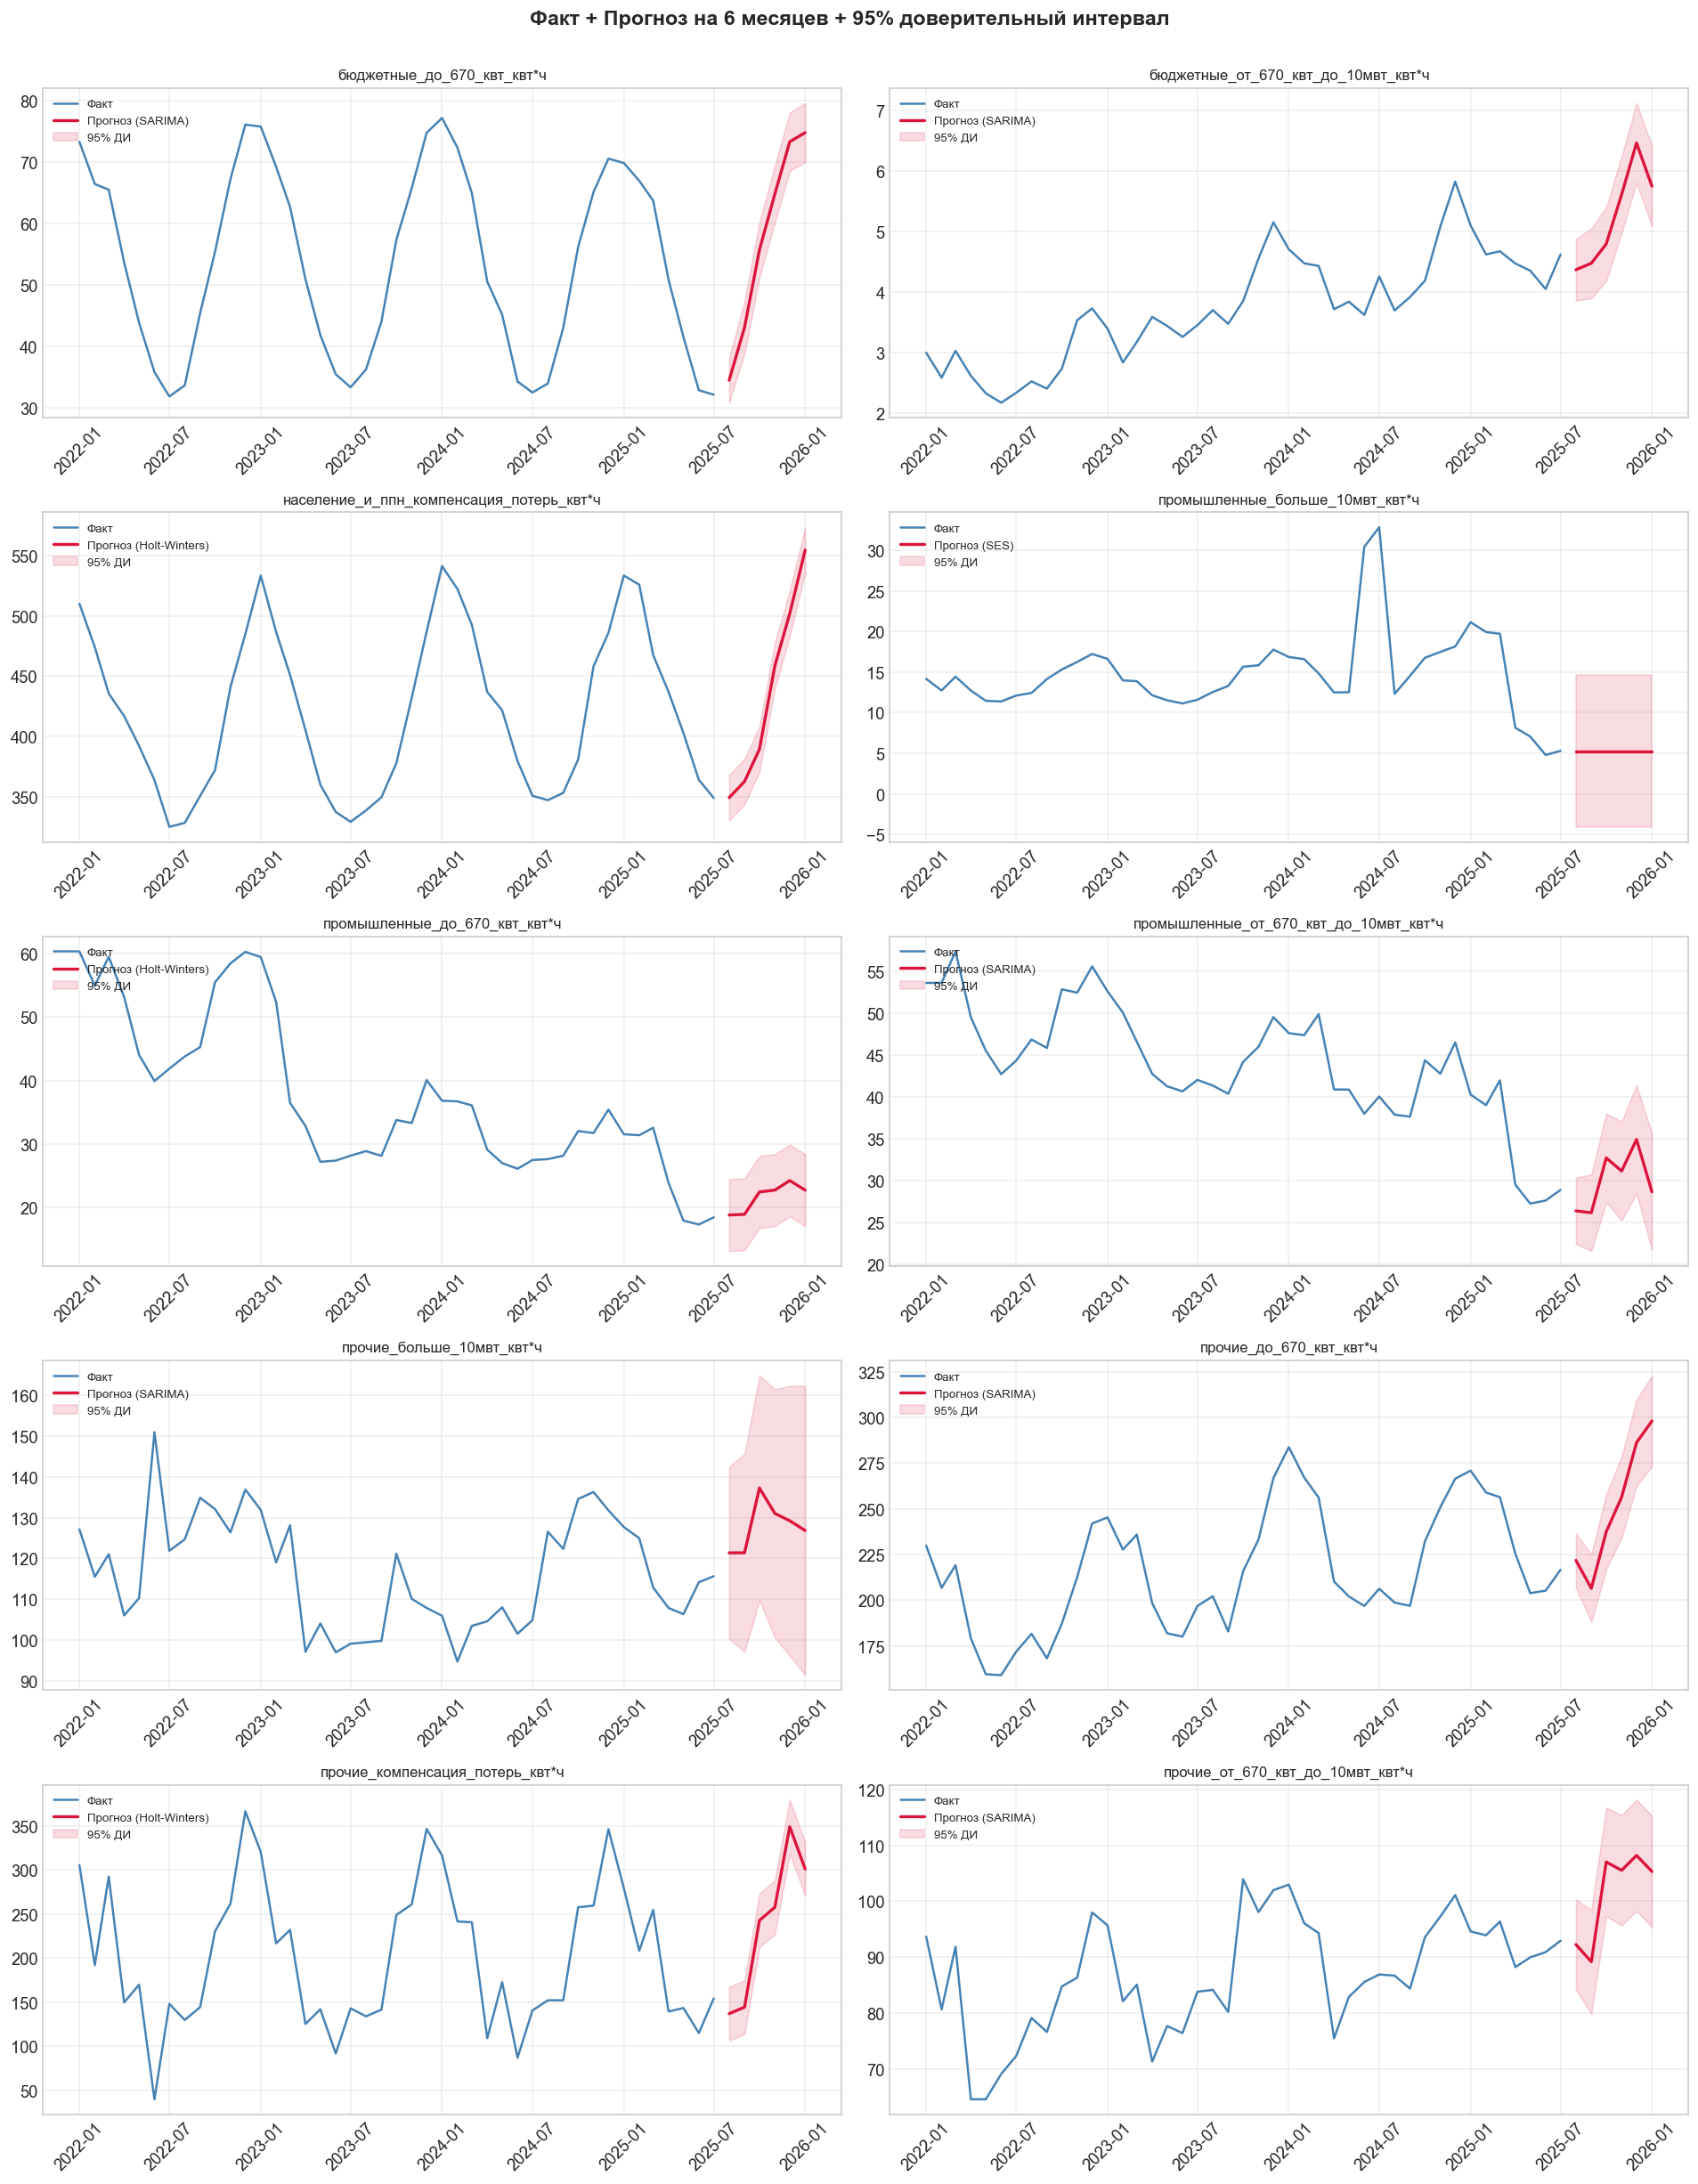

In [56]:
# Графики «факт + прогноз + 95% ДИ»

n_series = len(best_models_dict)
n_cols = 2
n_rows = (n_series + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows), dpi=120)
axes = axes.flatten()

for i, (col, model_name) in enumerate(best_models_dict.items()):
    ax = axes[i]

    # Факт
    ax.plot(df.index, df[col], label='Факт', color='steelblue', linewidth=1.5)

    # Прогноз
    ax.plot(future_dates, forecast_results[col],
            label=f'Прогноз ({model_name})', color='crimson', linewidth=2)

    # 95% ДИ
    ax.fill_between(
        future_dates,
        ci_results[col]['lower'],
        ci_results[col]['upper'],
        color='crimson', alpha=0.15, label='95% ДИ'
    )

    ax.set_title(col[:55], fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Факт + Прогноз на 6 месяцев + 95% доверительный интервал',
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Вывод**:
1. с учетом обучения моделей - победителей, на категории "Промышленные больше 10 МВт" модель выглядит нерелевантной
2. у потребителей "прочие больше 10 Мвт", "прочие от 670 кВт до 10 МВт" наблюдаются слишком большие 95% ДИ.

**Для более точного прогноза будет использоваться еще дополнительная модель Prophet**

### Этап 9. Финальный прогноз и интерпретация
1. Переобучить выбранную модель на полном наборе данных.
2. Построить прогноз на заданный горизонт.
3. Рассчитать доверительные/прогнозные интервалы.
4. Выделить ожидаемые тренды и сезонные пики.
5. Сформулировать итоговый вывод и бизнес-рекомендации.

In [50]:
# Prophet как дополнительная модель
# Точный bootstrap-ДИ для Holt-Winters

from prophet import Prophet
from copy import deepcopy
import openpyxl
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill, NamedStyle
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings('ignore')

# Настройки

BOOTSTRAP_SAMPLES = 500          # количество бутстрап-выборок
FORECAST_HORIZON = 6
prophet_results = {}
prophet_ci = {}
hw_bootstrap_ci = {}


# Prophet для всех категорий

print("Обучаю Prophet по всем категориям...\n")

for col in best_models_dict.keys():
    print(f"Prophet → {col[:50]}")

    # Подготовка данных в формате Prophet
    ts = df[[col]].reset_index()
    ts.columns = ['ds', 'y']
    ts = ts.dropna()

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        interval_width=0.95
    )
    model.fit(ts)

    future = model.make_future_dataframe(periods=FORECAST_HORIZON, freq='MS')
    forecast = model.predict(future)

    # Взять только будущие периоды
    pred = forecast.iloc[-FORECAST_HORIZON:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    pred = pred.set_index('ds')

    prophet_results[col] = pred['yhat']
    prophet_ci[col] = pred[['yhat_lower', 'yhat_upper']].rename(
        columns={'yhat_lower': 'lower', 'yhat_upper': 'upper'}
    )

print("\nProphet обучен.\n")

# Более точный bootstrap-ДИ для Holt-Winters

def bootstrap_hw_ci(series, horizon=6, n_samples=500, alpha=0.05):
    """
    Residual bootstrap для Holt-Winters.
    Корректно работает с DatetimeIndex.
    """
    y = series.dropna()

    # Обучение базовой модели на Series с сохранением индекса
    model = ExponentialSmoothing(
        y,
        trend='add',
        seasonal='mul',
        seasonal_periods=12
    ).fit(optimized=True)

    point_forecast = model.forecast(horizon)          # Series с датами
    residuals = model.resid

    # Бутстрап
    boot_forecasts = np.zeros((n_samples, horizon))

    for i in range(n_samples):
        boot_resid = np.random.choice(residuals, size=len(y), replace=True)
        boot_y = model.fittedvalues + boot_resid

        try:
            boot_model = ExponentialSmoothing(
                boot_y,
                trend='add',
                seasonal='mul',
                seasonal_periods=12
            ).fit(optimized=True)
            boot_forecasts[i, :] = boot_model.forecast(horizon)
        except Exception:
            boot_forecasts[i, :] = point_forecast.values

    lower = np.percentile(boot_forecasts, alpha/2 * 100, axis=0)
    upper = np.percentile(boot_forecasts, (1 - alpha/2) * 100, axis=0)

    ci = pd.DataFrame({
        'lower': lower,
        'upper': upper
    }, index=point_forecast.index)          # теперь индекс есть

    return point_forecast, ci


# Запуск bootstrap

print("Считаю bootstrap-ДИ для Holt-Winters...\n")

hw_cols = [col for col, model in best_models_dict.items() if model == 'Holt-Winters']
hw_bootstrap_ci = {}

for col in hw_cols:
    print(f"Bootstrap HW → {col[:50]}")
    pred, ci = bootstrap_hw_ci(df[col], horizon=FORECAST_HORIZON, n_samples=BOOTSTRAP_SAMPLES)
    hw_bootstrap_ci[col] = ci

print("\nBootstrap завершён.\n")



11:57:46 - cmdstanpy - INFO - Chain [1] start processing


Обучаю Prophet по всем категориям...

Prophet → бюджетные_до_670_квт_квт*ч


11:57:46 - cmdstanpy - INFO - Chain [1] done processing
11:57:46 - cmdstanpy - INFO - Chain [1] start processing
11:57:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet → бюджетные_от_670_квт_до_10мвт_квт*ч


11:57:47 - cmdstanpy - INFO - Chain [1] start processing
11:57:47 - cmdstanpy - INFO - Chain [1] done processing


...

Prophet → прочие_до_670_квт_квт*ч


11:57:48 - cmdstanpy - INFO - Chain [1] done processing
11:57:48 - cmdstanpy - INFO - Chain [1] start processing
11:57:48 - cmdstanpy - INFO - Chain [1] done processing


Prophet → прочие_компенсация_потерь_квт*ч


11:57:48 - cmdstanpy - INFO - Chain [1] start processing
11:57:48 - cmdstanpy - INFO - Chain [1] done processing


Prophet → прочие_от_670_квт_до_10мвт_квт*ч

Prophet обучен.

Считаю bootstrap-ДИ для Holt-Winters...

Bootstrap HW → население_и_ппн_компенсация_потерь_квт*ч
Bootstrap HW → промышленные_до_670_квт_квт*ч
Bootstrap HW → прочие_компенсация_потерь_квт*ч

Bootstrap завершён.



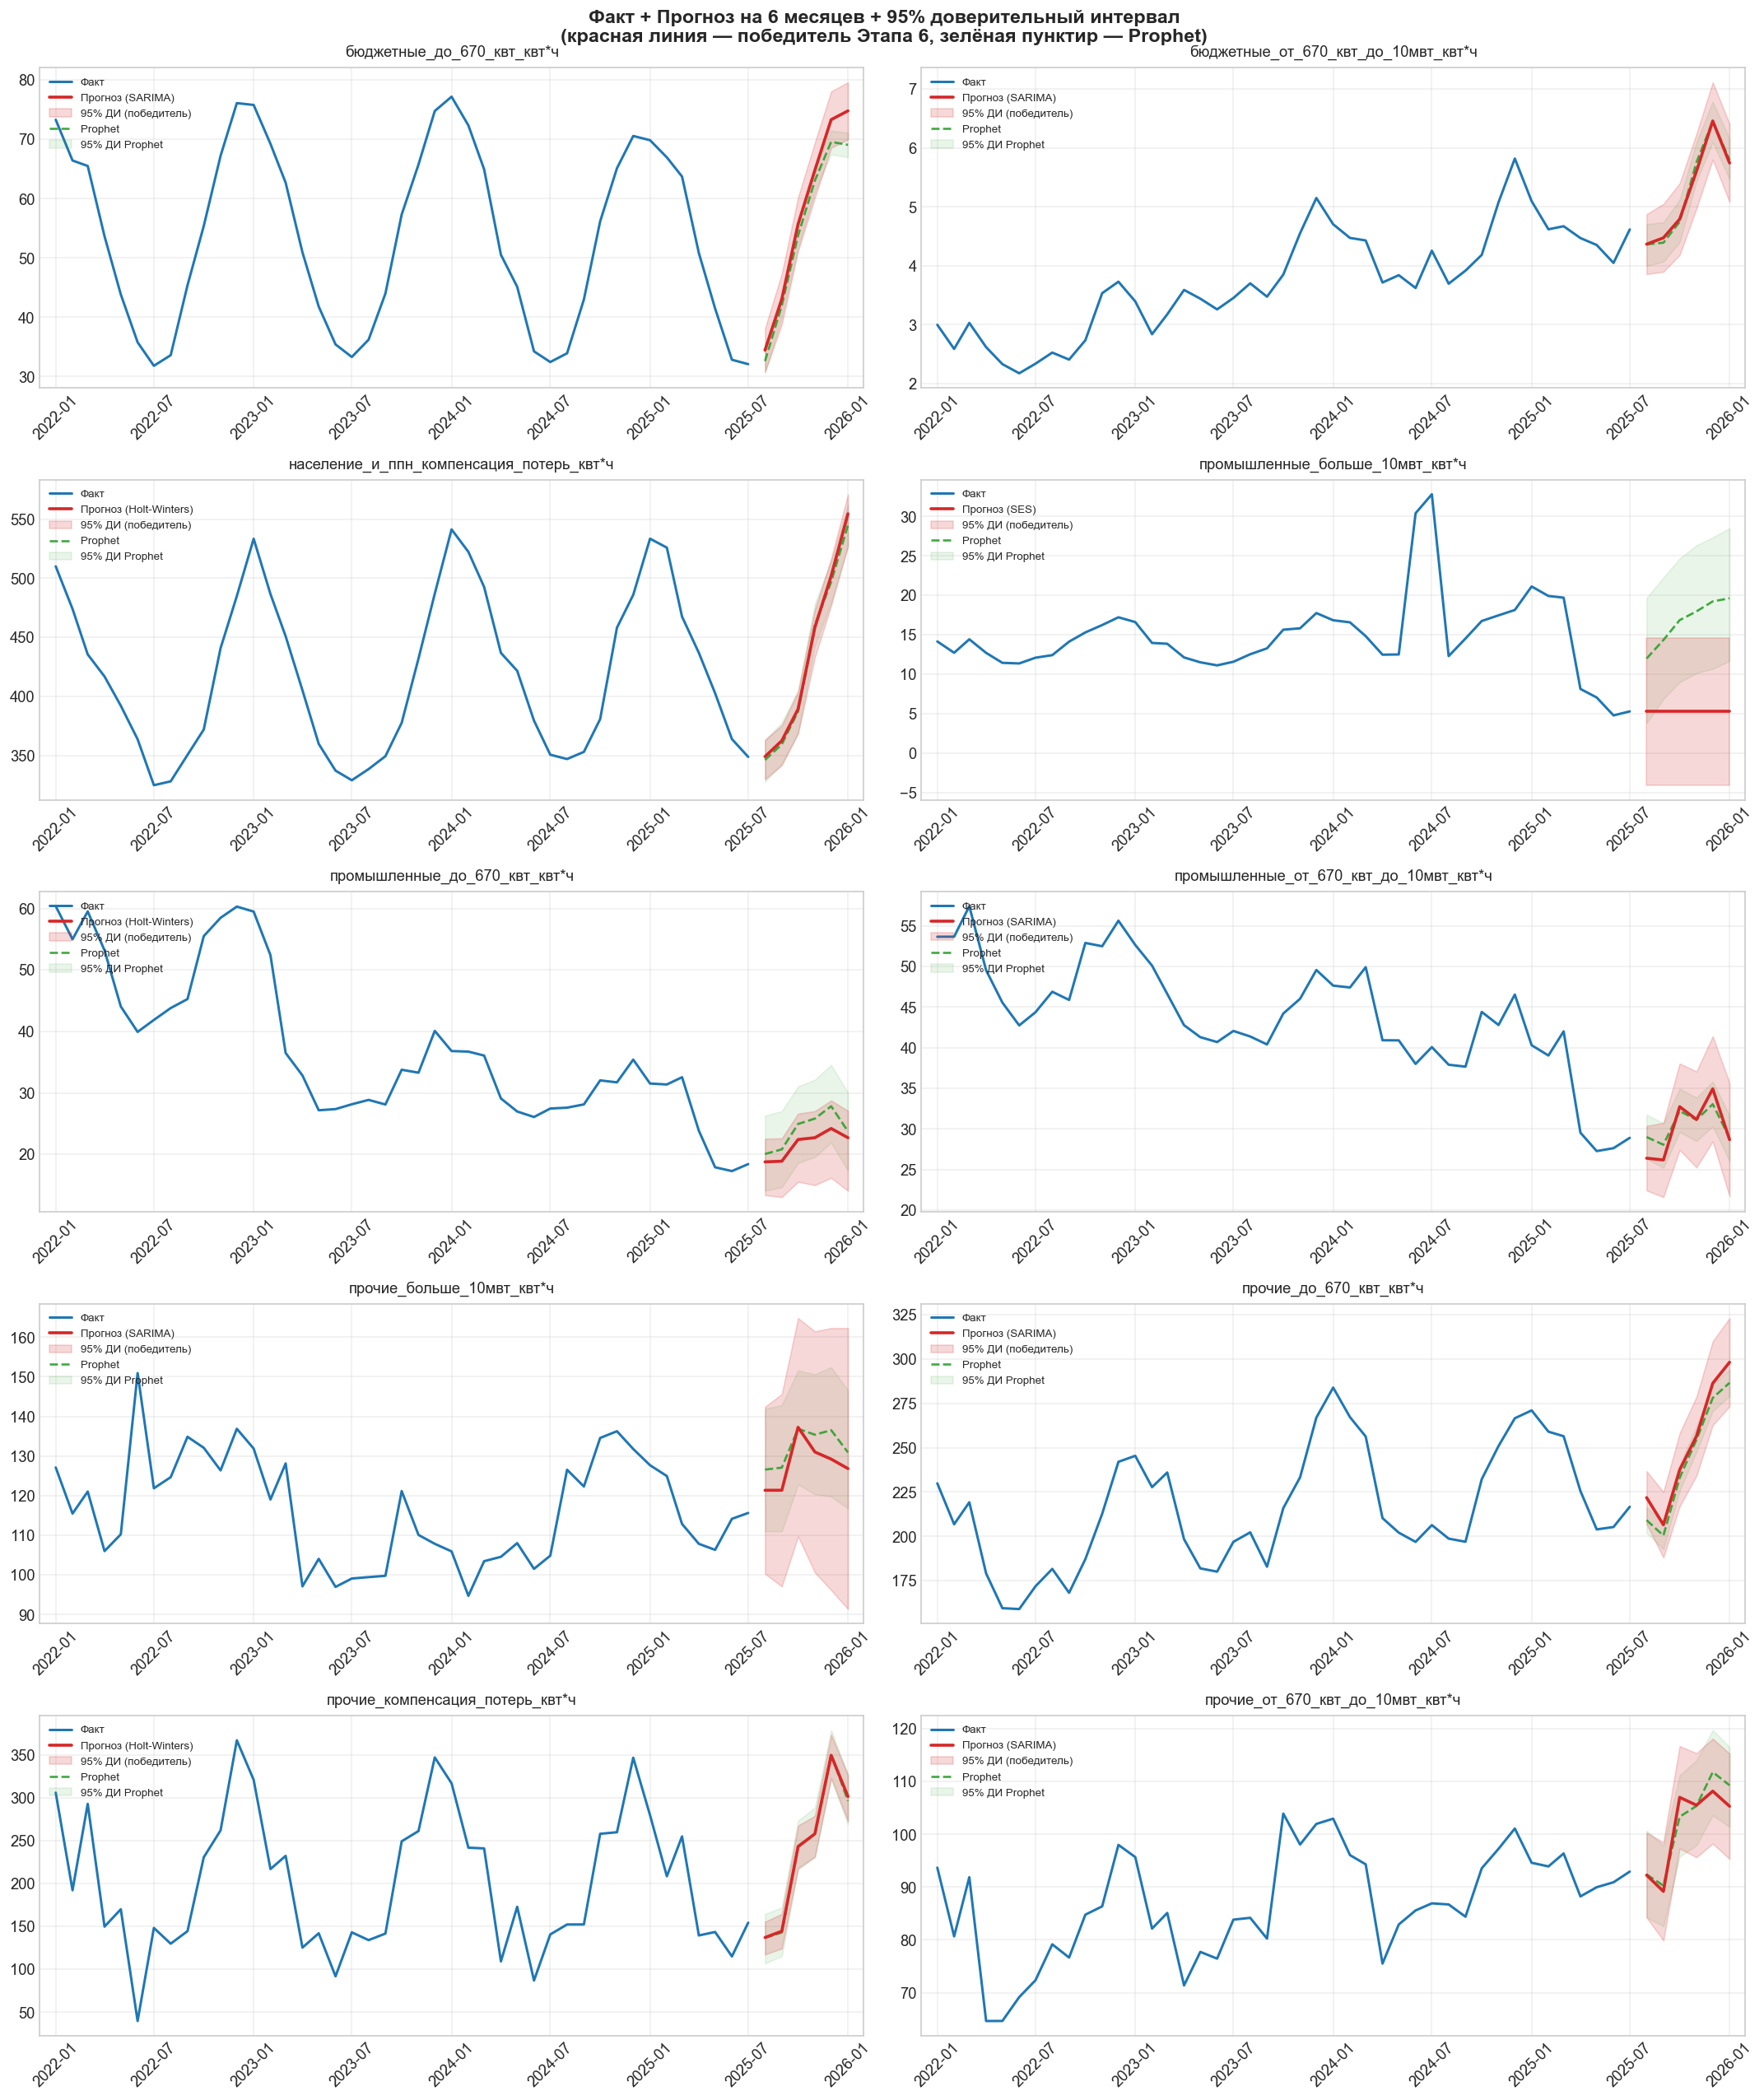

In [51]:
# ВИЗУАЛИЗАЦИЯ: Факт + Прогноз победителя + 95% ДИ (+ Prophet)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Настройки внешнего вида
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

n_series = len(best_models_dict)
n_cols = 2
n_rows = (n_series + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.2 * n_rows), dpi=120)
axes = axes.flatten()

for i, (col, model_name) in enumerate(best_models_dict.items()):
    ax = axes[i]

    # ----- Факт -----
    ax.plot(df.index, df[col],
            label='Факт', color='#1f77b4', linewidth=1.8, zorder=3)

    # ----- Прогноз победителя -----
    ax.plot(future_dates, forecast_results[col],
            label=f'Прогноз ({model_name})', color='#d62728', linewidth=2.2, zorder=4)

    # ----- 95% ДИ победителя -----
    if model_name == 'Holt-Winters' and col in hw_bootstrap_ci:
        lower = hw_bootstrap_ci[col]['lower']
        upper = hw_bootstrap_ci[col]['upper']
    else:
        lower = ci_results[col]['lower']
        upper = ci_results[col]['upper']

    ax.fill_between(future_dates, lower, upper,
                    color='#d62728', alpha=0.18, label='95% ДИ (победитель)', zorder=2)

    # ----- Prophet (для сравнения) -----
    if col in prophet_results:
        ax.plot(future_dates, prophet_results[col],
                label='Prophet', color='#2ca02c', linewidth=1.6, linestyle='--', alpha=0.9, zorder=3)

        ax.fill_between(future_dates,
                        prophet_ci[col]['lower'],
                        prophet_ci[col]['upper'],
                        color='#2ca02c', alpha=0.10, label='95% ДИ Prophet', zorder=1)

    # Оформление
    ax.set_title(col, fontsize=11, fontweight='medium', pad=8)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.3)

    # Красивые даты на оси X
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)

    # Небольшие отступы
    ax.margins(x=0.02)

# Исключить пустые оси
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Факт + Прогноз на 6 месяцев + 95% доверительный интервал\n(красная линия — победитель Этапа 6, зелёная пунктир — Prophet)',
             y=1.01, fontsize=14, fontweight='bold')

plt.show()

#### Вывод:
1. модель Prophet показывает более уверенные результаты и прогнозирует потребление по категории "Промышленные больше 10 МВт"
2. показывает более точный прогноз и меньшие доверительные интревалы у потребителей "прочие больше 10 Мвт", "прочие от 670 кВт до 10 МВт"
2. робастна к выбросам и корректно учитывает сезонность, что может пригодиться при трансляции моделей на другие сбытовые компании ПАО "Интер РАО".

#### Итоговая таблица с прогнозом

In [49]:
# Сборка данных в финальную таблицу для Excel

if 'future_dates' not in globals():
    last_date = pd.Timestamp(df.index[-1])
    future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1),
                                 periods=FORECAST_HORIZON, freq='MS')

excel_data = pd.DataFrame(index=future_dates)
excel_data.index.name = 'Месяц'

for col in best_models_dict.keys():
    model_name = best_models_dict[col]

    # Точечный прогноз победителя
    if model_name == 'Holt-Winters' and col in hw_bootstrap_ci:
        # Точечный прогноз из обычного HW
        excel_data[f'{col} (прогноз)'] = forecast_results[col].values
        excel_data[f'{col} (нижняя 95%)'] = hw_bootstrap_ci[col]['lower'].values
        excel_data[f'{col} (верхняя 95%)'] = hw_bootstrap_ci[col]['upper'].values
    else:
        excel_data[f'{col} (прогноз)'] = forecast_results[col].values
        excel_data[f'{col} (нижняя 95%)'] = ci_results[col]['lower'].values
        excel_data[f'{col} (верхняя 95%)'] = ci_results[col]['upper'].values

    # Prophet для сравнения
    excel_data[f'{col} Prophet (прогноз)'] = prophet_results[col].values
    excel_data[f'{col} Prophet (нижняя 95%)'] = prophet_ci[col]['lower'].values
    excel_data[f'{col} Prophet (верхняя 95%)'] = prophet_ci[col]['upper'].values

# Excel

output_file = 'Прогноз_потребления_6_месяцев_финал.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    excel_data.round(2).to_excel(writer, sheet_name='Прогноз 6 мес', index=True)

    # Форматирование
    wb = writer.book
    ws = writer.sheets['Прогноз 6 мес']

    # Стили
    header_font = Font(bold=True, color='FFFFFF', size=11)
    header_fill = PatternFill(start_color='2F5496', end_color='2F5496', fill_type='solid')
    thin_border = Border(
        left=Side(style='thin'),
        right=Side(style='thin'),
        top=Side(style='thin'),
        bottom=Side(style='thin')
    )
    center_align = Alignment(horizontal='center', vertical='center', wrap_text=True)

    # Заголовок
    for cell in ws[1]:
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center_align
        cell.border = thin_border

    # Данные
    for row in ws.iter_rows(min_row=2, max_row=ws.max_row, max_col=ws.max_column):
        for cell in row:
            cell.border = thin_border
            cell.alignment = Alignment(horizontal='center')

    # Ширина столбцов
    ws.column_dimensions['A'].width = 14
    for col_idx in range(2, ws.max_column + 1):
        ws.column_dimensions[get_column_letter(col_idx)].width = 18

    # Закрепляем первую строку и первый столбец
    ws.freeze_panes = 'B2'

    # Добавляем второй лист — только лучшие модели (без Prophet)
    best_only = pd.DataFrame(index=future_dates)
    best_only.index.name = 'Месяц'

    for col in best_models_dict.keys():
        best_only[f'{col} (прогноз)'] = excel_data[f'{col} (прогноз)']
        best_only[f'{col} (нижняя 95%)'] = excel_data[f'{col} (нижняя 95%)']
        best_only[f'{col} (верхняя 95%)'] = excel_data[f'{col} (верхняя 95%)']

    best_only.round(2).to_excel(writer, sheet_name='Только лучшие модели', index=True)

    ws2 = writer.sheets['Только лучшие модели']
    for cell in ws2[1]:
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center_align
        cell.border = thin_border

    for row in ws2.iter_rows(min_row=2, max_row=ws2.max_row, max_col=ws2.max_column):
        for cell in row:
            cell.border = thin_border
            cell.alignment = Alignment(horizontal='center')

    ws2.column_dimensions['A'].width = 14
    for col_idx in range(2, ws2.max_column + 1):
        ws2.column_dimensions[get_column_letter(col_idx)].width = 18
    ws2.freeze_panes = 'B2'

print(f"\nФайл успешно сохранён: {output_file}")
print("Листы:")
print("  1. «Прогноз 6 мес» — лучшие модели + Prophet")
print("  2. «Только лучшие модели» — только победители Этапа 6")


Файл успешно сохранён: Прогноз_потребления_6_месяцев_финал.xlsx
Листы:
  1. «Прогноз 6 мес» — лучшие модели + Prophet
  2. «Только лучшие модели» — только победители Этапа 6
